# When Modalities Disagree
Detecting strategic information asymmetry in real estate through cross-modal alignment.

## Setup and configuration

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'git+https://github.com/openai/CLIP.git'], capture_output=True)

import os, re, math, time, warnings, traceback
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.cross_decomposition import CCA
from itertools import combinations
import statsmodels.api as sm
import statsmodels.formula.api as smf

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

@dataclass
class Cfg:
    pca_dim: int = 30
    folds: int = 5
    seed: int = 42
    n_boot: int = 2000
    n_perm: int = 10000
    mask_prob: float = 0.15
    sweep_n: int = 10
    epochs: int = 200
    patience: int = 20
    batch: int = 64

cfg = Cfg()
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

FIGS = Path('/content/figures')
FIGS.mkdir(exist_ok=True)

PAL = {
    'strat':   '#BF4A3A', 'strat_l': '#D4795A',
    'obj':     '#2A6071', 'obj_l':   '#5A9BAF',
    'accent':  '#D4975A', 'gold':    '#C9A84C',
    'dark':    '#2D2D2D', 'mid':     '#6B6B6B',
    'light':   '#A3A3A3', 'grid':    '#E5E2DC',
    'green':   '#5A8F6B',
}

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 9, 'axes.titlesize': 10.5, 'axes.labelsize': 9.5,
    'axes.titleweight': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': PAL['mid'], 'axes.linewidth': 0.5,
    'axes.grid': False,
    'xtick.major.width': 0.4, 'ytick.major.width': 0.4,
    'xtick.color': PAL['mid'], 'ytick.color': PAL['mid'],
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.12,
    'legend.frameon': False, 'legend.fontsize': 8,
})

def hgrid(ax, alpha=0.3):
    ax.yaxis.grid(True, color=PAL['grid'], lw=0.4, alpha=alpha)
    ax.set_axisbelow(True)

def savefig(name):
    plt.savefig(FIGS / name, facecolor='white')
    plt.show()
    print(f"  saved: {name}")

def cosine_sim(a, b):
    a_n = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    b_n = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    return np.sum(a_n * b_n, axis=1)

def ols_fit(y, X, names):
    return sm.OLS(y, sm.add_constant(
        pd.DataFrame(X, columns=names).fillna(0))).fit()

def cv_predict(X, y):
    pred = np.zeros(len(y))
    for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(X):
        pred[te] = RidgeCV(alphas=np.logspace(-2, 4, 20)).fit(
            X[tr], y[tr]).predict(X[te])
    return pred

def cv_r2(X, y):
    scores = []
    for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(X):
        m = RidgeCV(alphas=np.logspace(-2, 4, 20)).fit(X[tr], y[tr])
        scores.append(r2_score(y[te], m.predict(X[te])))
    return np.mean(scores), np.std(scores)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"GPU: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'NONE'}")
print(f"seed={cfg.seed}")
assert torch.cuda.is_available(), "GPU required"


GPU: Tesla T4
seed=42


## Data loading and feature engineering

In [2]:
df = pd.read_csv('/content/boston_listings_with_census.csv')
npz = np.load('/content/clip_embeddings.npz')

lot_mask = df['home_type'] == 'LOT'
if lot_mask.sum():
    print(f"dropping {lot_mask.sum()} LOTs (vacant land, nothing to score)")
    keep = ~lot_mask.values
    df = df[keep].reset_index(drop=True)
    emb_text   = npz['emb_text'][keep]
    emb_photos = npz['emb_photos'][keep]
    emb_gsv    = npz['emb_gsv'][keep]
    emb_sat    = npz['emb_sat'][keep]
    has_text   = npz['has_text'][keep]
    has_photos = npz['has_photos'][keep]
    has_gsv    = npz['has_gsv'][keep]
    has_sat    = npz['has_sat'][keep]
else:
    emb_text, emb_photos = npz['emb_text'], npz['emb_photos']
    emb_gsv, emb_sat = npz['emb_gsv'], npz['emb_sat']
    has_text, has_photos = npz['has_text'], npz['has_photos']
    has_gsv, has_sat = npz['has_gsv'], npz['has_sat']

for col in ['price', 'price_listed', 'price_sold',
            'days_on_market', 'area_sqft', 'beds', 'baths']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# census bureau uses -666666666 as missing
df.loc[df['census_median_income'] < 0, 'census_median_income'] = np.nan
df.loc[df['area_sqft'] > 15000, 'area_sqft'] = np.nan
df.loc[df['area_sqft'] < 100, 'area_sqft'] = np.nan
df.loc[df['beds'] > 10, 'beds'] = np.nan
df.loc[df['baths'] > 10, 'baths'] = np.nan

# 7 municipalities: Boston, Cambridge, Newton, Somerville, Arlington, Medford, Brookline
# Boston and Newton need sub-neighborhood lookup because Zillow uses names like
# "Dorchester" or "Newtonville" instead of "Boston" or "Newton"
BOSTON_HOODS = {
    'Boston', 'Dorchester', 'Brighton', 'Jamaica Plain', 'South Boston',
    'East Boston', 'Roslindale', 'West Roxbury', 'Charlestown', 'Hyde Park',
    'Roxbury', 'Mattapan', 'Allston', 'Dorchester Center', 'Back Bay',
    'Beacon Hill', 'South End', 'Fenway', 'Mission Hill', 'North End',
    'West End', 'Chinatown', 'South Boston Waterfront', 'Seaport',
}
NEWTON_HOODS = {
    'Newton', 'Newtonville', 'Newton Center', 'Newton Corner', 'Auburndale',
    'Chestnut Hill', 'West Newton', 'Newton Highlands', 'Newton Upper Falls',
    'Newton Lower Falls', 'Nonantum', 'Waban',
}

def assign_city(city_name):
    s = str(city_name).strip()
    if s in BOSTON_HOODS: return 'Boston'
    if s in NEWTON_HOODS: return 'Newton'
    if 'Cambridge' in s: return 'Cambridge'
    if 'Somerville' in s: return 'Somerville'
    if 'Arlington' in s: return 'Arlington'
    if 'Medford' in s: return 'Medford'
    if 'Brookline' in s: return 'Brookline'
    return 'Other'

df['city_group'] = df['city'].apply(assign_city)

has_listed = df['price_listed'].notna() & (df['price_listed'] > 0)
df['price_gap'] = np.where(
    has_listed,
    (df['price_listed'] - df['price']) / df['price_listed'],
    np.nan)
df['price_gap_outlier'] = df['price_gap'].abs() > 0.5

is_unsold = df['price_sold'].isna() if 'price_sold' in df.columns else pd.Series(False, index=df.index)
is_no_photo = ~has_photos

N = len(df)
log_price = np.log(df['price'].values).astype(np.float32)
# exclude unsold from price gap analyses (their "price" is asking price, not market valuation)
valid_pg = (df['price_gap'].notna().values
            & ~df['price_gap_outlier'].values
            & ~is_unsold.values)
complete = has_text & has_photos & has_gsv & has_sat
complete_idx = np.where(complete)[0]

# tabular
type_dummies = pd.get_dummies(df['home_type'], prefix='type', drop_first=True)
tab_raw = df[['beds', 'baths', 'census_median_income', 'census_pct_educated']].copy()
tab_raw['log_sqft'] = np.log1p(df['area_sqft'])
for col in tab_raw.columns:
    tab_raw[col] = tab_raw[col].fillna(tab_raw[col].median())
tab_raw = pd.concat([tab_raw, type_dummies], axis=1)
TAB = tab_raw.values.astype(np.float32)
tab_names = list(tab_raw.columns)
TAB_s = StandardScaler().fit_transform(TAB)

LUX_WORDS = ['luxury', 'elegant', 'stunning', 'exquisite', 'premium', 'exceptional',
    'designer', 'custom', 'prestigious', 'magnificent', 'spectacular',
    'extraordinary', 'remarkable', 'exclusive', 'rare']

def text_features(desc):
    if not isinstance(desc, str) or len(desc.strip()) < 10:
        return [0, 0, 0, 0]
    lower = desc.lower()
    words = lower.split()
    nw = len(words)
    lux = sum(1 for w in LUX_WORDS if w in lower)
    return [lux, len(desc), nw, lux / max(nw, 1)]

tf_arr = np.array([text_features(d) for d in df['listing_description']])
tf_s = StandardScaler().fit_transform(tf_arr)
tf_names = ['luxury_ct', 'desc_len', 'word_ct', 'superlative_dens']

pca_text   = PCA(cfg.pca_dim).fit_transform(emb_text).astype(np.float32)
pca_photos = PCA(cfg.pca_dim).fit_transform(emb_photos).astype(np.float32)
pca_gsv    = PCA(cfg.pca_dim).fit_transform(emb_gsv).astype(np.float32)
pca_sat    = PCA(cfg.pca_dim).fit_transform(emb_sat).astype(np.float32)

cidx = complete_idx
ylp = log_price[cidx]
X_tab   = TAB_s[cidx].astype(np.float32)
X_text  = pca_text[cidx].astype(np.float32)
X_photo = pca_photos[cidx].astype(np.float32)
X_gsv   = pca_gsv[cidx].astype(np.float32)
X_sat   = pca_sat[cidx].astype(np.float32)
X_strat = np.hstack([X_text, X_photo])
X_obj   = np.hstack([X_gsv, X_sat])
X_all   = np.hstack([X_tab, X_text, X_photo, X_gsv, X_sat])

d_tab, d_mod = X_tab.shape[1], cfg.pca_dim
d_strat, d_obj, d_all = X_strat.shape[1], X_obj.shape[1], X_all.shape[1]
n_obs = len(cidx)

print(f"\nN={N}, complete={complete.sum()}, valid price gaps={valid_pg.sum()}")
print(f"unsold: {is_unsold.sum()}, no photos: {is_no_photo.sum()}")
print(f"cities: {df['city_group'].value_counts().to_dict()}")
print(f"types: {df['home_type'].value_counts().to_dict()}")
print(f"d_tab={d_tab}, d_mod={d_mod}, d_all={d_all}, n_complete={n_obs}")
dates = pd.to_datetime(df['date_sold'], errors='coerce')
print(f"sold dates: {dates.min()} to {dates.max()}")


dropping 19 LOTs (vacant land, nothing to score)

N=6893, complete=6109, valid price gaps=6006
unsold: 198, no photos: 773
cities: {'Boston': 1300, 'Newton': 1005, 'Arlington': 981, 'Medford': 979, 'Cambridge': 977, 'Brookline': 965, 'Somerville': 680, 'Other': 6}
types: {'CONDO': 3324, 'SINGLE_FAMILY': 1999, 'MULTI_FAMILY': 771, 'TOWNHOUSE': 606, 'APARTMENT': 193}
d_tab=9, d_mod=30, d_all=129, n_complete=6109
sold dates: 2023-04-18 00:00:00 to 2026-04-09 00:00:00


## CLIP quality scoring and misalignment

In [3]:
import clip
clip_model, _ = clip.load('ViT-B/32', device=device)
clip_model.eval()
print(f"CLIP on {device}")

QUALITY_PROMPTS = {
    'text':  ("a real estate listing for a modest, basic property",
              "a real estate listing for a luxurious, upscale property"),
    'photo': ("a photo of a modest, basic home interior",
              "a photo of a luxurious, high-end home interior"),
    'gsv':   ("a photo of a run-down, undesirable neighborhood street",
              "a photo of an attractive, well-maintained neighborhood street"),
    'sat':   ("an aerial view of a dense, low-income urban area",
              "an aerial view of an affluent residential area"),
}

ATTR_PROMPTS = {
    'Building condition': {
        'img': ("a photo of a poorly maintained, run-down building",
                "a photo of a well-maintained, pristine building"),
        'txt': ("a property listing for a building in poor condition",
                "a property listing for a building in excellent condition")},
    'Interior quality': {
        'img': ("a photo of a basic, dated home interior with cheap finishes",
                "a photo of a luxurious home interior with high-end finishes"),
        'txt': ("a property listing describing basic, modest interiors",
                "a property listing describing luxury, high-end interiors")},
    'Neighborhood': {
        'img': ("a photo of a run-down, undesirable urban neighborhood",
                "a photo of a beautiful, upscale residential neighborhood"),
        'txt': ("a property listing in a low-income neighborhood",
                "a property listing in an affluent, desirable neighborhood")},
    'Space and light': {
        'img': ("a photo of a small, dark, cramped room",
                "a photo of a spacious, bright, airy room full of natural light"),
        'txt': ("a property listing describing a small, compact space",
                "a property listing describing a spacious, sun-filled home")},
}

def qscore_batch(embeddings, mask, lo, hi):
    tok = clip.tokenize([lo, hi]).to(device)
    with torch.no_grad():
        tf = clip_model.encode_text(tok).float()
        tf = tf / tf.norm(dim=-1, keepdim=True)
    scores = np.zeros(len(embeddings))
    idx = np.where(mask)[0]
    if not len(idx):
        return scores
    e = torch.tensor(embeddings[idx]).float().to(device)
    e = e / e.norm(dim=-1, keepdim=True)
    logits = (100.0 * e @ tf.T).softmax(dim=-1)[:, 1]
    scores[idx] = logits.cpu().numpy()
    return scores

q_text   = qscore_batch(emb_text, has_text, *QUALITY_PROMPTS['text'])
q_photos = qscore_batch(emb_photos, has_photos, *QUALITY_PROMPTS['photo'])
q_gsv    = qscore_batch(emb_gsv, has_gsv, *QUALITY_PROMPTS['gsv'])
q_sat    = qscore_batch(emb_sat, has_sat, *QUALITY_PROMPTS['sat'])

print(f"\nquality (mean): text={q_text[has_text].mean():.3f}  "
      f"photos={q_photos[has_photos].mean():.3f}  "
      f"GSV={q_gsv[has_gsv].mean():.3f}  sat={q_sat[has_sat].mean():.3f}")

# strategic = agent curated, objective = can't manipulate
strat_q = np.where(has_text & has_photos, 0.5 * (q_text + q_photos), np.nan)
obj_q   = np.where(has_gsv & has_sat, 0.5 * (q_gsv + q_sat), np.nan)
# text-only strategic for no-photo listings
strat_q_textonly = np.where(has_text, q_text, np.nan)
strat_q = np.where(has_photos, strat_q, strat_q_textonly)

qm = np.where(np.isfinite(strat_q) & np.isfinite(obj_q), strat_q - obj_q, np.nan)
valid_qm = np.isfinite(qm)
qm_median = np.nanmedian(qm)
high_mis = valid_qm & (qm > qm_median)
low_mis  = valid_qm & (qm <= qm_median)
qm_fill  = qm.copy()
qm_fill[~valid_qm] = np.nanmedian(qm)

print(f"\nmisalignment: mean={qm[valid_qm].mean():.3f}  "
      f"std={qm[valid_qm].std():.3f}  n={valid_qm.sum()}")
print(f"  with photos: {(valid_qm & has_photos).sum()}")
print(f"  text-only: {(valid_qm & ~has_photos).sum()}")

attr_scores = {}
print("\nper-attribute gaps:")
for aname, prompts in ATTR_PROMPTS.items():
    ts = qscore_batch(emb_text, has_text, *prompts['txt'])
    ps = qscore_batch(emb_photos, has_photos, *prompts['img'])
    gs = qscore_batch(emb_gsv, has_gsv, *prompts['img'])
    sa = np.where(has_text & has_photos, 0.5 * (ts + ps), np.nan)
    oa = np.where(has_gsv, gs, np.nan)
    ga = np.where(np.isfinite(sa) & np.isfinite(oa), sa - oa, np.nan)
    attr_scores[aname] = {'S': sa, 'O': oa, 'gap': ga}
    v = np.isfinite(ga)
    print(f"  {aname:<22s} S={sa[v].mean():.3f}  O={oa[v].mean():.3f}  gap={ga[v].mean():+.3f}")

neigh_gap = attr_scores['Neighborhood']['gap']
neigh_gap_fill = neigh_gap.copy()
neigh_gap_fill[~np.isfinite(neigh_gap_fill)] = np.nanmedian(
    neigh_gap[np.isfinite(neigh_gap)])

# learned quality: Ridge from 512d CLIP embedding to log(price/sqft)
print("\nlearned quality scoring:")
df['log_ppsf'] = np.log(df['price'] / df['area_sqft'].clip(lower=100))
valid_ppsf = df['log_ppsf'].notna().values & ~is_unsold.values
loc_feats = TAB_s[:, [2, 3]]  # income + education

learned_q = {}
for mname, emb_m, has_m in [('text', emb_text, has_text),
                              ('photos', emb_photos, has_photos),
                              ('gsv', emb_gsv, has_gsv),
                              ('sat', emb_sat, has_sat)]:
    vm = has_m & valid_ppsf
    idx_m = np.where(vm)[0]
    if len(idx_m) < 50:
        continue
    y_m = df.loc[vm, 'log_ppsf'].values
    y_resid = y_m - Ridge(alpha=1).fit(loc_feats[idx_m], y_m).predict(loc_feats[idx_m])
    ridge = Ridge(alpha=1).fit(emb_m[idx_m], y_resid)
    sc = emb_m @ ridge.coef_
    sc = (sc - sc[has_m].mean()) / (sc[has_m].std() + 1e-8)
    sc = stats.norm.cdf(sc)
    learned_q[mname] = sc
    print(f"  {mname}: probe R2={r2_score(y_resid, ridge.predict(emb_m[idx_m])):.4f}")

if 'text' in learned_q and 'gsv' in learned_q:
    lq_strat = np.where(has_text & has_photos & ('photos' in learned_q),
        0.5 * (learned_q['text'] + learned_q.get('photos', learned_q['text'])), np.nan)
    lq_strat = np.where(np.isnan(lq_strat) & has_text, learned_q['text'], lq_strat)
    lq_obj = np.where(has_gsv & has_sat & ('sat' in learned_q),
        0.5 * (learned_q['gsv'] + learned_q.get('sat', learned_q['gsv'])), np.nan)
    lq_mis = np.where(np.isfinite(lq_strat) & np.isfinite(lq_obj),
        lq_strat - lq_obj, np.nan)
    v_l = np.isfinite(lq_mis) & valid_pg
    v_h = valid_qm & valid_pg
    if v_l.sum() > 30 and v_h.sum() > 30:
        r_l, p_l = stats.pearsonr(lq_mis[v_l], df.loc[v_l, 'price_gap'].values)
        r_h, p_h = stats.pearsonr(qm[v_h], df.loc[v_h, 'price_gap'].values)
        print(f"\n  hand-crafted delta vs price gap: r={r_h:.4f} p={p_h:.4f}")
        print(f"  learned delta vs price gap:      r={r_l:.4f} p={p_l:.4f}")


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 97.9MiB/s]


CLIP on cuda

quality (mean): text=0.462  photos=0.366  GSV=0.321  sat=0.227

misalignment: mean=0.136  std=0.171  n=6881
  with photos: 6109
  text-only: 772

per-attribute gaps:
  Building condition     S=0.856  O=0.292  gap=+0.564
  Interior quality       S=0.573  O=0.398  gap=+0.175
  Neighborhood           S=0.548  O=0.883  gap=-0.335
  Space and light        S=0.858  O=0.668  gap=+0.191

learned quality scoring:
  text: probe R2=0.3259
  photos: probe R2=0.3642
  gsv: probe R2=0.2585
  sat: probe R2=0.2569

  hand-crafted delta vs price gap: r=0.0888 p=0.0000
  learned delta vs price gap:      r=-0.0559 p=0.0000


## Core statistical results
Regressions, robustness checks, subgroup breakdowns, CCA, misalignment as a feature, no-photo analysis, unsold analysis, repeat listings.

In [4]:
print("=" * 60)
print("CORE STATISTICAL RESULTS")
print("=" * 60)

idx_r = np.where(valid_pg & valid_qm)[0]
y_gap = df.iloc[idx_r]['price_gap'].values
y_dom = np.log1p(df.iloc[idx_r]['days_on_market'].values)

print(f"\nsample: n={len(idx_r)}")
r_gap, p_gap = stats.pearsonr(qm[idx_r], y_gap)
r_dom, p_dom = stats.pearsonr(qm[idx_r], y_dom)
print(f"bivariate: gap r={r_gap:.4f} p={p_gap:.4f} | DOM r={r_dom:.4f} p={p_dom:.4f}")

# regression table
print(f"\nregression table (DV: price gap):")
specs = [
    ('tabular',         TAB_s[idx_r], tab_names),
    ('+ text feats',    np.column_stack([TAB_s[idx_r], tf_s[idx_r]]),
                        tab_names + tf_names),
    ('+ misalign',      np.column_stack([TAB_s[idx_r], qm_fill[idx_r].reshape(-1,1)]),
                        tab_names + ['qm']),
    ('+ text+misalign', np.column_stack([TAB_s[idx_r], tf_s[idx_r],
                        qm_fill[idx_r].reshape(-1,1)]),
                        tab_names + tf_names + ['qm']),
    ('+ text+neigh',    np.column_stack([TAB_s[idx_r], tf_s[idx_r],
                        neigh_gap_fill[idx_r].reshape(-1,1)]),
                        tab_names + tf_names + ['ng']),
]
for label, X, names in specs:
    fit = ols_fit(y_gap, X, names)
    ex = ""
    for k in ['qm', 'ng']:
        if k in fit.params.index:
            ex += f"  {k}: b={fit.params[k]:.4f} p={fit.pvalues[k]:.4f}"
    print(f"  {label:<20s} R2={fit.rsquared:.4f}{ex}")

# logistic
above = (df.iloc[idx_r]['price_gap'].values < 0).astype(int)
X_lg = np.column_stack([TAB_s[idx_r], qm[idx_r].reshape(-1,1)])
logit = sm.Logit(above, sm.add_constant(
    pd.DataFrame(X_lg, columns=tab_names + ['qm']).fillna(0))).fit(disp=0)
print(f"\nlogistic: coef={logit.params['qm']:.3f} p={logit.pvalues['qm']:.4f} "
      f"OR={np.exp(logit.params['qm']):.4f}")

# bootstrap
np.random.seed(cfg.seed)
X_boot = np.column_stack([TAB_s[idx_r], tf_s[idx_r], qm_fill[idx_r].reshape(-1,1)])
bnames = tab_names + tf_names + ['qm']
boot_coefs = []
for _ in range(cfg.n_boot):
    s = np.random.choice(len(y_gap), len(y_gap), replace=True)
    try:
        boot_coefs.append(ols_fit(y_gap[s], X_boot[s], bnames).params.get('qm', np.nan))
    except Exception:
        pass
boot_coefs = np.array([x for x in boot_coefs if np.isfinite(x)])
print(f"\nbootstrap (n={len(boot_coefs)}): mean={boot_coefs.mean():.4f} "
      f"CI=[{np.percentile(boot_coefs,2.5):.4f}, {np.percentile(boot_coefs,97.5):.4f}] "
      f"{100*(boot_coefs>0).mean():.1f}% positive")

# permutation
np.random.seed(cfg.seed)
obs_t = ols_fit(y_gap, X_boot, bnames).tvalues['qm']
exceed = 0
for _ in range(cfg.n_perm):
    X_sh = np.column_stack([TAB_s[idx_r], tf_s[idx_r],
        np.random.permutation(qm_fill[idx_r]).reshape(-1,1)])
    try:
        if abs(ols_fit(y_gap, X_sh, bnames).tvalues.get('qm', 0)) >= abs(obs_t):
            exceed += 1
    except Exception:
        pass
print(f"permutation: p={exceed/cfg.n_perm:.4f}")

# DOM mediation
ld = np.log1p(df.iloc[idx_r]['days_on_market'].values)
dom_fit = ols_fit(y_gap, np.column_stack([TAB_s[idx_r], ld.reshape(-1,1),
    qm_fill[idx_r].reshape(-1,1)]), tab_names + ['log_dom', 'qm'])
print(f"\nDOM mediation: qm p={dom_fit.pvalues['qm']:.4f}, DOM p={dom_fit.pvalues['log_dom']:.4f}")

# within-broker FE
bd = pd.get_dummies(df['broker'], prefix='b', drop_first=True)
bcols = [c for c in bd.columns if bd[c].sum() >= 3][:25]
broker_fit = ols_fit(y_gap, np.column_stack([TAB_s[idx_r],
    bd[bcols].iloc[idx_r].values.astype(float),
    qm_fill[idx_r].reshape(-1,1)]), tab_names + bcols + ['qm'])
print(f"within-broker: qm p={broker_fit.pvalues['qm']:.4f}")

# zipcode FE
if 'zipcode' in df.columns:
    zd = pd.get_dummies(df['zipcode'], prefix='z', drop_first=True)
    zcols = [c for c in zd.columns if zd[c].sum() >= 5][:30]
    zfe_fit = ols_fit(y_gap, np.column_stack([TAB_s[idx_r],
        zd[zcols].iloc[idx_r].values.astype(float),
        qm_fill[idx_r].reshape(-1,1)]), tab_names + zcols + ['qm'])
    print(f"zipcode FE: qm p={zfe_fit.pvalues.get('qm', 1):.4f}")

# per-attribute
print(f"\nper-attribute gap vs price gap:")
for aname, sc in attr_scores.items():
    v = np.isfinite(sc['gap']) & valid_pg
    if v.sum() > 30:
        r, p = stats.pearsonr(sc['gap'][v], df.loc[v, 'price_gap'].values)
        print(f"  {aname:<22s} r={r:.4f} p={p:.4f}")

# property type
print(f"\nproperty type breakdown:")
for pt in ['CONDO', 'SINGLE_FAMILY', 'MULTI_FAMILY', 'TOWNHOUSE', 'APARTMENT']:
    mask = valid_pg & valid_qm & (df['home_type'] == pt).values
    ti = np.where(mask)[0]
    if len(ti) < 15:
        continue
    r, p = stats.pearsonr(qm[ti], df.loc[mask, 'price_gap'].values)
    ab = (df.loc[mask, 'price_gap'].values < 0).astype(int)
    med = np.median(qm[ti])
    lo_bw = ab[qm[ti] <= med].mean() if (qm[ti] <= med).sum() > 3 else np.nan
    hi_bw = ab[qm[ti] > med].mean() if (qm[ti] > med).sum() > 3 else np.nan
    print(f"  {pt:<16s} n={len(ti):>4d}  r={r:.4f} p={p:.4f}  BW: lo={lo_bw:.3f} hi={hi_bw:.3f}")

# CLIP validation
print(f"\nCLIP quality vs log(price/sqft):")
for label, sc, mk in [('strategic', strat_q, np.isfinite(strat_q)),
                        ('objective', obj_q, np.isfinite(obj_q))]:
    v = mk & df['log_ppsf'].notna().values & ~is_unsold.values
    if v.sum() > 30:
        r, p = stats.pearsonr(sc[v], df.loc[v, 'log_ppsf'].values)
        print(f"  {label}: r={r:.4f} p={p:.4f}")

# price tier
mp = df.loc[~is_unsold, 'price'].median()
print(f"\nmisalignment by price tier (median=${mp:,.0f}):")
for lb, tm in [('below median', df['price'].values <= mp),
                ('above median', df['price'].values > mp)]:
    cm = valid_pg & tm & valid_qm
    ti = np.where(cm)[0]
    if len(ti) > 30:
        r, p = stats.pearsonr(qm[ti], df.loc[cm, 'price_gap'].values)
        print(f"  {lb} (n={len(ti)}): r={r:.4f} p={p:.4f}")

# quantile regression
print(f"\nquantile regression:")
qr_df = pd.DataFrame({'pg': y_gap, 'qm': qm_fill[idx_r]})
for j, nm in enumerate(tab_names):
    qr_df[nm] = TAB_s[idx_r, j]
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    try:
        qr = smf.quantreg('pg ~ qm + ' + ' + '.join(tab_names), qr_df).fit(q=q, max_iter=1000)
        print(f"  q={q:.2f}: qm={qr.params['qm']:.4f} p={qr.pvalues['qm']:.4f}")
    except Exception:
        pass

# pairwise gaps
print(f"\npairwise gaps vs price gap:")
for pn, sq, oq, pm in [
    ('text vs GSV',    q_text,   q_gsv, has_text & has_gsv),
    ('text vs sat',    q_text,   q_sat, has_text & has_sat),
    ('photos vs GSV',  q_photos, q_gsv, has_photos & has_gsv),
    ('photos vs sat',  q_photos, q_sat, has_photos & has_sat)]:
    gap = sq - oq
    v = pm & valid_pg
    if v.sum() > 30:
        r, p = stats.pearsonr(gap[v], df.loc[v, 'price_gap'].values)
        print(f"  {pn:<18s} r={r:.4f} p={p:.4f}")

# alternative definitions
print(f"\nalternative misalignment definitions:")
alt_defs = {
    'difference': qm,
    'ratio': np.where(np.isfinite(strat_q) & np.isfinite(obj_q) & (obj_q > 0.01),
        strat_q / obj_q, np.nan),
    'max pairwise': np.array([
        max(q_text[i]-q_gsv[i], q_text[i]-q_sat[i],
            q_photos[i]-q_gsv[i], q_photos[i]-q_sat[i])
        if has_text[i] and has_photos[i] and has_gsv[i] and has_sat[i]
        else np.nan for i in range(N)]),
    'photos only': np.where(has_photos & has_gsv, q_photos - q_gsv, np.nan),
    'text only': np.where(has_text & has_gsv, q_text - q_gsv, np.nan),
}
for nm, vals in alt_defs.items():
    v = np.isfinite(vals) & valid_pg
    if v.sum() > 30:
        r, p = stats.pearsonr(vals[v], df.loc[v, 'price_gap'].values)
        print(f"  {nm:<18s} r={r:.4f} p={p:.4f}")

# weighting sensitivity
print(f"\nweighting sensitivity (text weight):")
for wt in [0.0, 0.25, 0.5, 0.75, 1.0]:
    sq2 = np.where(has_text & has_photos, wt*q_text + (1-wt)*q_photos, np.nan)
    oq2 = np.where(has_gsv & has_sat, 0.5*(q_gsv + q_sat), np.nan)
    mis2 = np.where(np.isfinite(sq2) & np.isfinite(oq2), sq2 - oq2, np.nan)
    v = np.isfinite(mis2) & valid_pg
    if v.sum() > 30:
        r, p = stats.pearsonr(mis2[v], df.loc[v, 'price_gap'].values)
        print(f"  w={wt:.2f}: r={r:.4f} p={p:.4f}")

# misalignment as a feature for price prediction
print(f"\nmisalignment as Ridge feature (log sale price):")
r2_base, _ = cv_r2(X_all, ylp)
X_aug = np.column_stack([X_all, qm_fill[cidx].reshape(-1,1)])
r2_aug, _ = cv_r2(X_aug, ylp)
X_tabdelta = np.column_stack([X_tab, qm_fill[cidx].reshape(-1,1)])
r2_tabdelta, _ = cv_r2(X_tabdelta, ylp)
print(f"  early fusion:          R2={r2_base:.4f}")
print(f"  early fusion + delta:  R2={r2_aug:.4f}  (improvement: {r2_aug-r2_base:+.4f})")
print(f"  tabular + delta only:  R2={r2_tabdelta:.4f}")

# polynomial Ridge: add interaction terms
print(f"\npolynomial Ridge (explicit interaction terms):")
top_s = X_strat[:, :5]  # top 5 strategic PCs
top_o = X_obj[:, :5]    # top 5 objective PCs
interactions = np.column_stack([top_s[:, i:i+1] * top_o[:, j:j+1]
    for i in range(5) for j in range(5)])  # 25 cross terms
X_poly = np.column_stack([X_all, interactions])
r2_poly, _ = cv_r2(X_poly, ylp)
print(f"  early fusion + 25 interaction terms: R2={r2_poly:.4f}")
print(f"  improvement over plain early fusion: {r2_poly-r2_base:+.4f}")

# no-photo analysis
print(f"\nno-photo listing analysis:")
no_photo_mask = ~has_photos & has_text & has_gsv
photo_mask = has_photos & has_text & has_gsv
for label, mask in [('no photos', no_photo_mask), ('has photos', photo_mask)]:
    sub = mask & valid_pg
    if sub.sum() < 10:
        continue
    pg = df.loc[sub, 'price_gap']
    dom = df.loc[sub, 'days_on_market']
    bw = (pg < 0).mean()
    print(f"  {label} (n={sub.sum()}): mean gap={pg.mean():.4f}, "
          f"median DOM={dom.median():.0f}, BW rate={100*bw:.1f}%")
# text-only misalignment for no-photo
textonly_mis = np.where(no_photo_mask, q_text - 0.5*(q_gsv + q_sat), np.nan)
v_np = np.isfinite(textonly_mis) & valid_pg
if v_np.sum() > 15:
    r_np, p_np = stats.pearsonr(textonly_mis[v_np], df.loc[v_np, 'price_gap'].values)
    print(f"  text-only misalignment vs price gap: r={r_np:.4f} p={p_np:.4f}")

# unsold analysis
print(f"\nunsold listing analysis:")
dates_listed = pd.to_datetime(df['date_listed'], errors='coerce')
# only consider listings old enough to have had time to sell (>= 90 days)
cutoff = dates_listed.max() - pd.Timedelta(days=90)
old_enough = dates_listed < cutoff
if old_enough.sum() > 100 and is_unsold.sum() > 20:
    sold_flag = (~is_unsold & old_enough & valid_qm).astype(int)
    unsold_flag = (is_unsold & old_enough & valid_qm)
    eligible = old_enough & valid_qm
    eligible_idx = np.where(eligible)[0]
    if eligible.sum() > 50:
        X_unsold = np.column_stack([TAB_s[eligible_idx], qm_fill[eligible_idx].reshape(-1,1)])
        y_sold = (~is_unsold.values)[eligible_idx].astype(int)
        try:
            unsold_logit = sm.Logit(y_sold, sm.add_constant(
                pd.DataFrame(X_unsold, columns=tab_names+['qm']).fillna(0))).fit(disp=0)
            print(f"  P(sold) ~ misalignment: coef={unsold_logit.params['qm']:.3f} "
                  f"p={unsold_logit.pvalues['qm']:.4f} "
                  f"OR={np.exp(unsold_logit.params['qm']):.3f}")
            print(f"  n eligible={eligible.sum()}, n sold={y_sold.sum()}, n unsold={len(y_sold)-y_sold.sum()}")
        except Exception as e:
            print(f"  logistic failed: {e}")

# repeat listings
print(f"\nrepeat listing check:")
if 'street' in df.columns:
    addr_counts = df['street'].value_counts()
    repeats = addr_counts[addr_counts > 1]
    real_repeats = repeats[repeats.index != '(undisclosed Address)']
    print(f"  addresses appearing 2+ times: {len(real_repeats)}")
    if len(real_repeats) > 0:
        for addr in real_repeats.head(5).index:
            rows = df[df['street'] == addr]
            if len(rows) >= 2 and valid_qm[rows.index].all():
                deltas = qm[rows.index]
                gaps = rows['price_gap'].values
                brokers = rows['broker'].values
                print(f"    {addr}: deltas={deltas.round(3)}, gaps={gaps.round(3)}")
                if len(set(brokers)) > 1:
                    print(f"      different brokers: {brokers}")

# CCA
print(f"\nCCA decomposition (strategic vs objective embeddings):")
try:
    cca_mask = complete & ~is_unsold.values
    cca_idx = np.where(cca_mask)[0]
    n_cca = min(len(cca_idx), 2000)  # cap for speed
    cca_sub = np.random.choice(cca_idx, n_cca, replace=False)
    cca_strat = np.hstack([pca_text[cca_sub], pca_photos[cca_sub]])
    cca_obj = np.hstack([pca_gsv[cca_sub], pca_sat[cca_sub]])
    n_comp = min(20, cfg.pca_dim)
    cca = CCA(n_components=n_comp)
    cca.fit(cca_strat, cca_obj)
    Xs, Xo = cca.transform(cca_strat, cca_obj)
    can_corrs = [np.corrcoef(Xs[:, i], Xo[:, i])[0, 1] for i in range(n_comp)]
    print(f"  top canonical correlations: {[f'{c:.3f}' for c in can_corrs[:10]]}")
    # private component magnitude (low-correlation dimensions)
    private_thresh = 5  # use last 15 dimensions as "private"
    strat_private = Xs[:, private_thresh:]
    priv_norm = np.linalg.norm(strat_private, axis=1)
    # does private norm predict misalignment?
    if valid_qm[cca_sub].all():
        r_priv, p_priv = stats.pearsonr(priv_norm, qm[cca_sub])
        print(f"  strategic private norm vs misalignment: r={r_priv:.4f} p={p_priv:.4f}")
except Exception as e:
    print(f"  CCA failed: {e}")

# bidding war quartiles
reg_v = valid_pg & valid_qm
reg_i = np.where(reg_v)[0]
qm_r = qm[reg_i]
above_list = (df.iloc[reg_i]['price_gap'].values < 0).astype(int)
qe = np.percentile(qm_r, [25, 50, 75])
qb = np.digitize(qm_r, qe)
q_rates = [above_list[qb==q].mean() for q in range(4)]
q_ns = [int((qb==q).sum()) for q in range(4)]
ratio14 = q_rates[0] / max(q_rates[3], 0.001)
print(f"\nbidding war quartiles:")
for q in range(4):
    print(f"  Q{q+1}: n={q_ns[q]}, P(above list)={q_rates[q]:.3f}")
print(f"  Q1/Q4 ratio: {ratio14:.1f}x")

# cross-validated misalignment
print(f"\ncross-validated misalignment:")
cv_mask = complete & valid_pg
cv_idx = np.where(cv_mask)[0]
cv_mis = np.zeros(len(cv_idx))
for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(cv_idx):
    X_tr = np.column_stack([q_text[cv_idx[tr]], q_photos[cv_idx[tr]],
                             q_gsv[cv_idx[tr]], q_sat[cv_idx[tr]]])
    X_te = np.column_stack([q_text[cv_idx[te]], q_photos[cv_idx[te]],
                             q_gsv[cv_idx[te]], q_sat[cv_idx[te]]])
    lr = LinearRegression().fit(X_tr, df.iloc[cv_idx[tr]]['price_gap'].values)
    cv_mis[te] = lr.predict(X_te)
r_cv, p_cv = stats.pearsonr(cv_mis, df.iloc[cv_idx]['price_gap'].values)
r_hc, _ = stats.pearsonr(qm[cv_idx], df.iloc[cv_idx]['price_gap'].values)
print(f"  CV misalignment:  r={r_cv:.4f} p={p_cv:.4f}")
print(f"  hand-crafted:     r={r_hc:.4f}")

# neighborhood word allocation
neigh_words = ['neighborhood', 'area', 'community', 'block', 'street', 'walk',
    'transit', 'park', 'school', 'restaurant', 'shop', 'cafe', 'vibrant', 'quiet']
def wfrac(d, wl):
    if not isinstance(d, str) or len(d) < 10: return 0
    w = d.lower().split()
    return sum(1 for x in w if any(k in x for k in wl)) / max(len(w), 1)
df['nw_frac'] = df['listing_description'].apply(lambda d: wfrac(d, neigh_words))
hi_f = df.loc[high_mis, 'nw_frac']
lo_f = df.loc[low_mis, 'nw_frac']
_, nw_p = stats.ttest_ind(hi_f.dropna(), lo_f.dropna())
print(f"\nneighborhood word allocation: high={hi_f.mean():.4f} low={lo_f.mean():.4f} p={nw_p:.4f}")

# broker ANOVA
bg = [g.assign(d=qm[g.index])['d'].values
      for _, g in df[valid_qm].groupby('broker') if len(g) >= 3]
if len(bg) >= 3:
    f_s, f_p = stats.f_oneway(*bg)
    print(f"broker ANOVA: F={f_s:.3f} p={f_p:.4f}")

# text characteristics
print(f"\ntext characteristics:")
dl = df['listing_description'].apply(lambda d: len(d) if isinstance(d, str) else 0)
ec = df['listing_description'].apply(lambda d: d.count('!') if isinstance(d, str) else 0)
for fn, vals in [('length', dl), ('exclamations', ec)]:
    h = vals[high_mis]; l = vals[low_mis]
    h = h[h > 0]; l = l[l > 0]
    if len(h) > 10 and len(l) > 10:
        t, p = stats.ttest_ind(h, l)
        print(f"  {fn}: high={h.mean():.0f} low={l.mean():.0f} p={p:.4f}")


CORE STATISTICAL RESULTS

sample: n=5999
bivariate: gap r=0.0888 p=0.0000 | DOM r=0.0036 p=0.7827

regression table (DV: price gap):
  tabular              R2=0.0522
  + text feats         R2=0.0682
  + misalign           R2=0.0528  qm: b=0.0161 p=0.0457
  + text+misalign      R2=0.0687  qm: b=0.0143 p=0.0916
  + text+neigh         R2=0.0683  ng: b=0.0051 p=0.5384

logistic: coef=-0.703 p=0.0003 OR=0.4952

bootstrap (n=2000): mean=0.0141 CI=[-0.0034, 0.0319] 93.8% positive
permutation: p=0.0902

DOM mediation: qm p=0.0051, DOM p=0.0000
within-broker: qm p=0.0632
zipcode FE: qm p=0.3070

per-attribute gap vs price gap:
  Building condition     r=0.0071 p=0.5957
  Interior quality       r=0.0377 p=0.0046
  Neighborhood           r=0.0569 p=0.0000
  Space and light        r=-0.0162 p=0.2243

property type breakdown:
  CONDO            n=2797  r=0.0631 p=0.0008  BW: lo=0.382 hi=0.298
  SINGLE_FAMILY    n=1876  r=0.1312 p=0.0000  BW: lo=0.531 hi=0.433
  MULTI_FAMILY     n= 672  r=-0.0736 p=

## Fusion, probes, information decomposition
Late vs early fusion, late+delta gap test, Shapley values, PID decomposition by misalignment level, conditional modality value, hedonic residual.

In [5]:
print("=" * 60)
print("FUSION, PROBES, INFORMATION DECOMPOSITION")
print("=" * 60)

feat = {'Tab': TAB_s[cidx], 'Text': pca_text[cidx], 'Photos': pca_photos[cidx],
        'GSV': pca_gsv[cidx], 'Sat': pca_sat[cidx]}

tab_r2, tab_std = cv_r2(feat['Tab'], ylp)
print(f"\ntabular: R2={tab_r2:.4f}")

print(f"\nunimodal:")
for nm, X in feat.items():
    r2, s = cv_r2(X, ylp)
    print(f"  {nm}: R2={r2:.4f} +/- {s:.4f}")

kf = KFold(cfg.folds, shuffle=True, random_state=cfg.seed)
late_sc, early_sc, early_nt_sc = [], [], []
for tr, te in kf.split(cidx):
    # late: average independent predictions
    late_pred = sum(
        RidgeCV(alphas=np.logspace(-2,4,20)).fit(X[tr], ylp[tr]).predict(X[te])
        for X in feat.values()) / len(feat)
    late_sc.append(r2_score(ylp[te], late_pred))

    # early: concat everything
    Xa = np.column_stack([X[tr] for X in feat.values()])
    Xat = np.column_stack([X[te] for X in feat.values()])
    early_sc.append(r2_score(ylp[te],
        RidgeCV(alphas=np.logspace(-2,4,20)).fit(Xa, ylp[tr]).predict(Xat)))

    # early without text
    fnt = {k: v for k, v in feat.items() if k != 'Text'}
    Xn = np.column_stack([X[tr] for X in fnt.values()])
    Xnt = np.column_stack([X[te] for X in fnt.values()])
    early_nt_sc.append(r2_score(ylp[te],
        RidgeCV(alphas=np.logspace(-2,4,20)).fit(Xn, ylp[tr]).predict(Xnt)))

print(f"\nfusion:")
print(f"  late:              {np.mean(late_sc):.4f}")
print(f"  early:             {np.mean(early_sc):.4f}")
print(f"  early (no text):   {np.mean(early_nt_sc):.4f}")
print(f"  early > late by:   {np.mean(early_sc)-np.mean(late_sc):+.4f}")

# does delta close the late-early gap?
delta_col = qm_fill[cidx].reshape(-1,1)
late_plus_delta = []
for tr, te in kf.split(cidx):
    late_pred = sum(
        RidgeCV(alphas=np.logspace(-2,4,20)).fit(X[tr], ylp[tr]).predict(X[te])
        for X in feat.values()) / len(feat)
    X_lpd = np.column_stack([late_pred.reshape(-1,1), delta_col[te]])
    X_lpd_tr = np.column_stack([
        sum(RidgeCV(alphas=np.logspace(-2,4,20)).fit(X[tr], ylp[tr]).predict(X[tr])
            for X in feat.values()).reshape(-1,1) / len(feat),
        delta_col[tr]])
    late_plus_delta.append(r2_score(ylp[te],
        RidgeCV(alphas=np.logspace(-2,4,20)).fit(X_lpd_tr, ylp[tr]).predict(X_lpd)))
print(f"  late + delta:      {np.mean(late_plus_delta):.4f}  "
      f"(closes {np.mean(late_plus_delta)-np.mean(late_sc):.4f} of the gap)")

print(f"\nincremental value over tabular:")
for nm, X in feat.items():
    if nm == 'Tab': continue
    r2, _ = cv_r2(np.column_stack([feat['Tab'], X]), ylp)
    print(f"  + {nm}: R2={r2:.4f} (delta={r2-tab_r2:+.4f})")

# train/test split
X_full = np.column_stack([X for X in feat.values()])
tr_i, te_i = train_test_split(np.arange(len(cidx)), test_size=0.2, random_state=cfg.seed)
r2_tab_tt = r2_score(ylp[te_i],
    RidgeCV(alphas=np.logspace(-2,4,20)).fit(TAB_s[cidx][tr_i], ylp[tr_i]).predict(TAB_s[cidx][te_i]))
r2_ef_tt = r2_score(ylp[te_i],
    RidgeCV(alphas=np.logspace(-2,4,20)).fit(X_full[tr_i], ylp[tr_i]).predict(X_full[te_i]))
print(f"\ntrain/test (80/20): tab={r2_tab_tt:.4f}  early fusion={r2_ef_tt:.4f}")

# MLP
print(f"\nsklearn MLP:")
mlp_sc = []
for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(X_full):
    ml = MLPRegressor(hidden_layer_sizes=(64,), alpha=0.1, max_iter=2000,
        early_stopping=True, validation_fraction=0.15,
        random_state=cfg.seed, learning_rate='adaptive')
    ml.fit(X_full[tr], ylp[tr])
    mlp_sc.append(r2_score(ylp[te], ml.predict(X_full[te])))
print(f"  MLP(64): R2={np.mean(mlp_sc):.4f} +/- {np.std(mlp_sc):.4f}")

# missing modality ablation
print(f"\nmissing modality ablation:")
for label, X in [
    ('all',        X_full),
    ('no text',    np.column_stack([TAB_s[cidx], pca_photos[cidx], pca_gsv[cidx], pca_sat[cidx]])),
    ('no strat',   np.column_stack([TAB_s[cidx], pca_gsv[cidx], pca_sat[cidx]])),
    ('no obj vis', np.column_stack([TAB_s[cidx], pca_text[cidx], pca_photos[cidx]])),
    ('tab only',   TAB_s[cidx])]:
    r2, _ = cv_r2(X, ylp)
    print(f"  {label:<12s} R2={r2:.4f}")

# linear probes
print(f"\nlinear probes (log price/sqft, residualized):")
valid_lp = complete & df['area_sqft'].notna().values & (df['area_sqft'] > 100).values & ~is_unsold.values
for mn, ef, hm, zs in [('text', emb_text, has_text, q_text),
                         ('photos', emb_photos, has_photos, q_photos),
                         ('GSV', emb_gsv, has_gsv, q_gsv),
                         ('satellite', emb_sat, has_sat, q_sat)]:
    vm = valid_lp & hm
    idx_m = np.where(vm)[0]
    if len(idx_m) < 100: continue
    X_m = ef[idx_m]
    y_m = np.log(df.loc[vm, 'price'].values / df.loc[vm, 'area_sqft'].values)
    X_loc = TAB_s[idx_m][:, [2, 3]]
    y_m = y_m - Ridge(alpha=1).fit(X_loc, y_m).predict(X_loc)
    pr2, ps = cv_r2(X_m, y_m)
    pp = cv_predict(X_m, y_m)
    r_pz, _ = stats.pearsonr(pp, zs[idx_m])
    print(f"  {mn}: R2={pr2:.4f}  probe_vs_zerosho r={r_pz:.4f}")

# interaction types
print(f"\ninteraction types:")
ps_it = 0.5 * (cv_predict(pca_text, log_price) + cv_predict(pca_photos, log_price))
po_it = 0.5 * (cv_predict(pca_gsv, log_price) + cv_predict(pca_sat, log_price))
pt_it = cv_predict(TAB_s, log_price)
pa_it = cv_predict(np.column_stack([TAB_s, pca_text, pca_photos, pca_gsv, pca_sat]), log_price)
thr = np.median(np.abs(pt_it - log_price))
sg = np.abs(ps_it - log_price) < thr
og = np.abs(po_it - log_price) < thr
cg = np.abs(pa_it - log_price) < thr
itype = np.array([''] * N, dtype=object)
for i in range(N):
    if sg[i] and og[i]: itype[i] = 'Redundancy'
    elif sg[i] and not og[i]: itype[i] = 'Unique-S'
    elif not sg[i] and og[i]: itype[i] = 'Unique-O'
    elif cg[i]: itype[i] = 'Synergy'
    else: itype[i] = 'Neither'
for it in ['Synergy', 'Redundancy', 'Unique-S', 'Unique-O', 'Neither']:
    m = (itype == it) & valid_pg & valid_qm
    if m.sum() >= 15:
        r, p = stats.pearsonr(qm[m], df.loc[m, 'price_gap'].values)
        print(f"  {it:<12s} n={m.sum():>4d}  r={r:.4f}  p={p:.4f}")

# Shapley values
print(f"\nShapley values:")
mod_sh = [pca_text[cidx], pca_photos[cidx], pca_gsv[cidx], pca_sat[cidx]]
mod_nm = ['Text', 'Photos', 'GSV', 'Satellite']
sub_r2 = {}
for sz in range(5):
    for combo in combinations(range(4), sz):
        X = TAB_s[cidx] if not combo else np.column_stack(
            [TAB_s[cidx]] + [mod_sh[j] for j in combo])
        sub_r2[combo], _ = cv_r2(X, ylp)
shapley_vals = np.zeros(4)
for i in range(4):
    for sz in range(4):
        for combo in combinations([j for j in range(4) if j != i], sz):
            cw = tuple(sorted(combo + (i,)))
            w = math.factorial(sz) * math.factorial(3 - sz) / math.factorial(4)
            shapley_vals[i] += w * (sub_r2[cw] - sub_r2[combo])
total_sv = sum(shapley_vals)
print(f"  baseline (tab): {sub_r2[()]:.4f}  full: {sub_r2[(0,1,2,3)]:.4f}")
for i, nm in enumerate(mod_nm):
    pct = 100 * shapley_vals[i] / total_sv if total_sv > 0 else 0
    print(f"  {nm:<12s} phi={shapley_vals[i]:.4f} ({pct:.1f}%)")

# PID by misalignment quartile
print(f"\nPID by misalignment quartile:")
pid_mask = complete & valid_pg
pid_idx = np.where(pid_mask)[0]
qm_pid = qm[pid_idx]
quartile_edges = np.percentile(qm_pid[np.isfinite(qm_pid)], [25, 50, 75])
qbins = np.digitize(qm_pid, quartile_edges)

for qi in range(4):
    sub = pid_idx[qbins == qi]
    if len(sub) < 30: continue
    Xt = TAB_s[sub]
    Xs = np.column_stack([pca_text[sub], pca_photos[sub]])
    Xo = np.column_stack([pca_gsv[sub], pca_sat[sub]])
    target = df.iloc[sub]['price_gap'].values
    r2_t, _ = cv_r2(Xt, target)
    r2_ts, _ = cv_r2(np.column_stack([Xt, Xs]), target)
    r2_to, _ = cv_r2(np.column_stack([Xt, Xo]), target)
    r2_tso, _ = cv_r2(np.column_stack([Xt, Xs, Xo]), target)
    i_s = r2_ts - r2_t; i_o = r2_to - r2_t; i_so = r2_tso - r2_t
    R = max(0, i_s + i_o - i_so)
    Us = max(0, i_so - i_o); Uo = max(0, i_so - i_s)
    S = i_so - Us - Uo - R
    print(f"  Q{qi+1} (n={len(sub)}): R={R:.4f} Us={Us:.4f} Uo={Uo:.4f} S={S:+.4f}")

# conditional modality value
print(f"\nconditional modality value:")
cmv_mask = complete & valid_qm
cmv_idx = np.where(cmv_mask)[0]
cmv_y = log_price[cmv_idx]
cmv_qm = qm[cmv_idx]
cmv_med = np.median(cmv_qm)
cmv_results = {}
for label, split in [('low', cmv_qm <= cmv_med), ('high', cmv_qm > cmv_med)]:
    sub = np.where(split)[0]
    tab_sub = TAB_s[cmv_idx][sub]
    y_sub = cmv_y[sub]
    br, _ = cv_r2(tab_sub, y_sub)
    row = {}
    for mn, mf in [('Text', pca_text), ('Photos', pca_photos),
                    ('GSV', pca_gsv), ('Sat', pca_sat)]:
        r2a, _ = cv_r2(np.column_stack([tab_sub, mf[cmv_idx][sub]]), y_sub)
        row[mn] = r2a - br
    cmv_results[label] = row
    vals = '  '.join(f"{k}={v:+.4f}" for k, v in row.items())
    print(f"  {label} misalignment (n={len(sub)}, tab R2={br:.4f}): {vals}")

# hedonic residual
print(f"\nhedonic residual:")
hr_mask = complete & valid_pg & valid_qm
hr_idx = np.where(hr_mask)[0]
resid = np.zeros(len(hr_idx))
for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(hr_idx):
    Xtr = np.column_stack([TAB_s[hr_idx[tr]], pca_text[hr_idx[tr]], pca_photos[hr_idx[tr]],
                            pca_gsv[hr_idx[tr]], pca_sat[hr_idx[tr]]])
    Xte = np.column_stack([TAB_s[hr_idx[te]], pca_text[hr_idx[te]], pca_photos[hr_idx[te]],
                            pca_gsv[hr_idx[te]], pca_sat[hr_idx[te]]])
    resid[te] = log_price[hr_idx[te]] - RidgeCV(alphas=np.logspace(-2,4,20)).fit(
        Xtr, log_price[hr_idx[tr]]).predict(Xte)
r_hr, p_hr = stats.pearsonr(qm[hr_idx], resid)
print(f"  misalignment vs full-model residual: r={r_hr:.4f} p={p_hr:.4f}")
resid_t = np.zeros(len(hr_idx))
for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(hr_idx):
    resid_t[te] = log_price[hr_idx[te]] - RidgeCV(alphas=np.logspace(-2,4,20)).fit(
        TAB_s[hr_idx[tr]], log_price[hr_idx[tr]]).predict(TAB_s[hr_idx[te]])
r_tr, p_tr = stats.pearsonr(qm[hr_idx], resid_t)
print(f"  misalignment vs tab-only residual:   r={r_tr:.4f} p={p_tr:.4f}")


FUSION, PROBES, INFORMATION DECOMPOSITION

tabular: R2=0.6241

unimodal:
  Tab: R2=0.6241 +/- 0.0368
  Text: R2=0.4241 +/- 0.0203
  Photos: R2=0.3627 +/- 0.0220
  GSV: R2=0.1919 +/- 0.0128
  Sat: R2=0.1581 +/- 0.0089

fusion:
  late:              0.5033
  early:             0.7516
  early (no text):   0.7429
  early > late by:   +0.2483
  late + delta:      0.6188  (closes 0.1155 of the gap)

incremental value over tabular:
  + Text: R2=0.6942 (delta=+0.0701)
  + Photos: R2=0.7093 (delta=+0.0853)
  + GSV: R2=0.6914 (delta=+0.0673)
  + Sat: R2=0.6897 (delta=+0.0656)

train/test (80/20): tab=0.5649  early fusion=0.6947

sklearn MLP:
  MLP(64): R2=0.7696 +/- 0.0332

missing modality ablation:
  all          R2=0.7516
  no text      R2=0.7429
  no strat     R2=0.7062
  no obj vis   R2=0.7304
  tab only     R2=0.6241

linear probes (log price/sqft, residualized):
  text: R2=0.3136  probe_vs_zerosho r=0.3901
  photos: R2=0.3285  probe_vs_zerosho r=0.3553
  GSV: R2=0.2844  probe_vs_zerosho r=

## Subgroups, temporal, geographic
Three-way splits (type x city x price), multi-family deep dive, temporal train/test, adversarial drift, city-level analysis for all 7 municipalities, per-zipcode signal.

In [6]:
print("=" * 60)
print("SUBGROUPS, TEMPORAL, GEOGRAPHIC")
print("=" * 60)

# within-building condos
if 'street' in df.columns:
    df['building'] = df['street'].apply(
        lambda s: re.sub(r'\s*(unit|apt|#|suite|ste)\s*\S*$', '', str(s),
            flags=re.IGNORECASE).strip() if isinstance(s, str) else '')
    condo_m = (df['home_type'] == 'CONDO') & valid_qm
    bc = df[condo_m].groupby('building').size()
    multi = bc[bc >= 3].index
    print(f"\nwithin-building condos:")
    print(f"  buildings with 3+ units: {len(multi)}")
    n_in = df[condo_m & df['building'].isin(multi)].shape[0]
    print(f"  condos in multi-unit: {n_in}")
    if n_in > 10:
        wv = df[condo_m & df['building'].isin(multi)].groupby('building').apply(
            lambda g: qm[g.index].var())
        tv = qm[condo_m].var()
        print(f"  within-building var: {wv.mean():.4f}")
        print(f"  total var: {tv:.4f}")
        print(f"  ratio: {wv.mean()/tv:.3f}")

# SFH decomposition
print(f"\nSFH pairwise decomposition:")
sfh_mask = (df['home_type'] == 'SINGLE_FAMILY') & valid_pg & valid_qm
sfh_idx = np.where(sfh_mask)[0]
if len(sfh_idx) > 30:
    print(f"  n={len(sfh_idx)}")
    for pn, sq, oq, pm in [
        ('text vs GSV',   q_text, q_gsv, has_text & has_gsv),
        ('text vs sat',   q_text, q_sat, has_text & has_sat),
        ('photos vs GSV', q_photos, q_gsv, has_photos & has_gsv),
        ('photos vs sat', q_photos, q_sat, has_photos & has_sat)]:
        v = pm & sfh_mask
        if v.sum() > 15:
            r, p = stats.pearsonr((sq-oq)[v], df.loc[v, 'price_gap'].values)
            print(f"  {pn:<18s} r={r:.4f} p={p:.4f}")

# reverse test
print(f"\nreverse test (underselling vs overselling):")
neg = valid_pg & valid_qm & (qm < 0)
pos = valid_pg & valid_qm & (qm > 0)
if neg.sum() > 10:
    bw_neg = (df.loc[neg, 'price_gap'] < 0).mean()
    bw_pos = (df.loc[pos, 'price_gap'] < 0).mean()
    print(f"  underselling: n={neg.sum()}, BW={100*bw_neg:.1f}%, gap={df.loc[neg,'price_gap'].mean():.4f}")
    print(f"  overselling:  n={pos.sum()}, BW={100*bw_pos:.1f}%, gap={df.loc[pos,'price_gap'].mean():.4f}")

# sentence topics
print(f"\nsentence-level topics:")
topic_kw = {
    'kitchen': ['kitchen', 'chef', 'granite', 'quartz', 'stainless', 'counter', 'cabinet'],
    'bathroom': ['bath', 'bathroom', 'shower', 'tub', 'vanity'],
    'living': ['living', 'dining', 'family', 'room', 'space', 'open'],
    'neighborhood': ['neighborhood', 'area', 'community', 'walk', 'transit',
        'school', 'restaurant', 'shop', 'park', 'vibrant', 'quiet'],
    'views/outdoor': ['view', 'views', 'deck', 'patio', 'balcony', 'yard', 'garden', 'outdoor'],
    'luxury': ['luxury', 'elegant', 'stunning', 'exquisite', 'premium',
        'exceptional', 'designer', 'custom', 'prestigious'],
    'condition': ['renovated', 'updated', 'new', 'modern', 'remodel'],
}
def sent_topics(d):
    if not isinstance(d, str) or len(d) < 20: return {}
    sents = re.split(r'[.!?]+', d)
    cts = {t: 0 for t in topic_kw}; total = 0
    for s in sents:
        sl = s.lower().strip()
        if len(sl) < 5: continue
        total += 1
        for t, kws in topic_kw.items():
            if any(k in sl for k in kws): cts[t] += 1
    return {t: c / max(total, 1) for t, c in cts.items()}

topic_data = df['listing_description'].apply(sent_topics)
for topic in topic_kw:
    hf = topic_data[high_mis].apply(lambda d: d.get(topic, 0)).mean()
    lf = topic_data[low_mis].apply(lambda d: d.get(topic, 0)).mean()
    _, p = stats.ttest_ind(
        topic_data[high_mis].apply(lambda d: d.get(topic, 0)).dropna(),
        topic_data[low_mis].apply(lambda d: d.get(topic, 0)).dropna())
    ratio = hf / max(lf, 0.001)
    print(f"  {topic:<15s} high={hf:.3f} low={lf:.3f} ratio={ratio:.2f} p={p:.4f}")

# three-way subgroups
print(f"\nthree-way subgroup analysis (type x city x price tier):")
print(f"{'type':<16s} {'city':<12s} {'tier':<8s} {'n':>4s} {'r':>8s} {'p':>8s}")
print("-" * 56)
sig_count, total_count = 0, 0
for pt in ['CONDO', 'SINGLE_FAMILY', 'MULTI_FAMILY', 'TOWNHOUSE']:
    for cg in df['city_group'].unique():
        if cg == 'Other': continue
        for tier_label, tier_mask in [('low', df['price'].values <= mp),
                                       ('high', df['price'].values > mp)]:
            mask = ((df['home_type'] == pt).values & (df['city_group'] == cg).values
                    & tier_mask & valid_pg & valid_qm)
            idx = np.where(mask)[0]
            if len(idx) < 15: continue
            r, p = stats.pearsonr(qm[idx], df.iloc[idx]['price_gap'].values)
            total_count += 1
            if p < 0.05: sig_count += 1
            star = '*' if p < 0.05 else ''
            print(f"  {pt:<14s} {cg:<12s} {tier_label:<8s} {len(idx):>4d} {r:>8.4f} {p:>8.4f}{star}")
print(f"\n  {sig_count}/{total_count} subgroups significant at p<0.05")

# multi-family deep dive
print(f"\nmulti-family deep dive:")
mf = (df['home_type'] == 'MULTI_FAMILY') & valid_pg & valid_qm
mf_idx = np.where(mf)[0]
if len(mf_idx) >= 20:
    r_mf, p_mf = stats.pearsonr(qm[mf_idx], df.iloc[mf_idx]['price_gap'].values)
    print(f"  n={len(mf_idx)}, r={r_mf:.4f}, p={p_mf:.4f}")
    print(f"  mean delta: {qm[mf_idx].mean():.4f}, std: {qm[mf_idx].std():.4f}")
    print(f"  median price: ${df.iloc[mf_idx]['price'].median():,.0f}")
    print(f"  cities: {df.iloc[mf_idx]['city_group'].value_counts().head(5).to_dict()}")

# bidding wars by type
print(f"\nbidding wars by type:")
for pt in ['CONDO', 'SINGLE_FAMILY', 'MULTI_FAMILY']:
    cm = valid_pg & valid_qm & (df['home_type'] == pt).values
    idx_pt = np.where(cm)[0]
    if len(idx_pt) < 30: continue
    qm_pt = qm[idx_pt]
    ab_pt = (df.iloc[idx_pt]['price_gap'].values < 0).astype(int)
    edges = np.percentile(qm_pt, [25, 50, 75])
    bins = np.digitize(qm_pt, edges)
    print(f"\n  {pt}:")
    for q in range(4):
        mq = bins == q
        if mq.sum() > 3:
            print(f"    Q{q+1}: n={mq.sum()}, P(above)={ab_pt[mq].mean():.3f}")

# broker table
print(f"\nbroker table:")
if 'broker' in df.columns:
    bs = (df[valid_qm & valid_pg].assign(d=qm[valid_qm & valid_pg])
        .groupby('broker').agg(
            n=('d', 'size'), mean_d=('d', 'mean'),
            mean_price=('price', 'mean'),
            bw_rate=('price_gap', lambda x: (x < 0).mean()))
        .query('n >= 5').sort_values('mean_d', ascending=False))
    print(f"  top 5:")
    for _, r in bs.head(5).iterrows():
        print(f"    {r.name[:40]:<40s} n={int(r['n']):>3d} d={r['mean_d']:.3f} "
              f"BW={100*r['bw_rate']:.0f}% ${r['mean_price']:,.0f}")
    print(f"  bottom 5:")
    for _, r in bs.tail(5).iterrows():
        print(f"    {r.name[:40]:<40s} n={int(r['n']):>3d} d={r['mean_d']:.3f} "
              f"BW={100*r['bw_rate']:.0f}% ${r['mean_price']:,.0f}")
    if len(bs) > 10:
        r_bw, p_bw = stats.pearsonr(bs['mean_d'], bs['bw_rate'])
        print(f"  broker-level: delta vs BW rate r={r_bw:.4f} p={p_bw:.4f}")

# case studies
print(f"\ncase studies:")
cs_v = valid_qm & valid_pg
qm_cs = qm.copy(); qm_cs[~cs_v] = -np.inf
print("  top 5 misalignment:")
for rank, i in enumerate(np.argsort(-qm_cs)[:5]):
    d = df.iloc[i]
    print(f"    #{rank+1} {str(d.get('street',''))[:35]:<35s} ${d['price']:>11,.0f} "
          f"gap={d['price_gap']:.3f} d={qm[i]:.3f}")
qm_cs2 = qm.copy(); qm_cs2[~cs_v] = np.inf
print("  bottom 5 (underselling):")
for rank, i in enumerate(np.argsort(qm_cs2)[:5]):
    d = df.iloc[i]
    print(f"    #{rank+1} {str(d.get('street',''))[:35]:<35s} ${d['price']:>11,.0f} "
          f"gap={d['price_gap']:.3f} d={qm[i]:.3f}")

# outlier profiles
print(f"\noutlier profiles:")
for label, mask in [
    ('top 5%',    valid_qm & (qm > np.nanpercentile(qm, 95))),
    ('bottom 5%', valid_qm & (qm < np.nanpercentile(qm, 5)))]:
    print(f"  {label} (n={mask.sum()}):")
    print(f"    median price: ${df.loc[mask, 'price'].median():,.0f}")
    print(f"    median DOM: {df.loc[mask, 'days_on_market'].median():.0f}")
    print(f"    types: {df.loc[mask, 'home_type'].value_counts(normalize=True).head(3).to_dict()}")

# temporal
print(f"\ntemporal analysis:")
for dc in ['date_sold', 'date_listed']:
    if dc not in df.columns: continue
    dates = pd.to_datetime(df[dc], errors='coerce')
    if dates.notna().sum() < 100: continue
    df['sale_year'] = dates.dt.year
    df['sale_month'] = dates.dt.month
    df['sale_quarter'] = dates.dt.to_period('Q')

    print(f"\n  by quarter (from {dc}):")
    for q, qdf in df[valid_pg & valid_qm].groupby('sale_quarter'):
        if len(qdf) >= 20:
            r, p = stats.pearsonr(qm[qdf.index], qdf['price_gap'].values)
            print(f"    {str(q):>8s} n={len(qdf):>5d} r={r:>8.4f} p={p:>8.4f}")

    print(f"\n  by season:")
    for sn, months in [('winter', [12,1,2]), ('spring', [3,4,5]),
                        ('summer', [6,7,8]), ('fall', [9,10,11])]:
        vm = valid_pg & valid_qm & df['sale_month'].isin(months).values
        if vm.sum() > 30:
            r, p = stats.pearsonr(qm[vm], df.loc[vm, 'price_gap'].values)
            print(f"    {sn}: n={vm.sum()}, r={r:.4f}, p={p:.4f}")
    break  # only use first valid date column

# temporal train/test: train on earlier data, test on later
dates_sold = pd.to_datetime(df['date_sold'], errors='coerce')
if dates_sold.notna().sum() > 200:
    cutpoint = dates_sold.quantile(0.75)
    train_t = (dates_sold < cutpoint) & valid_pg & valid_qm
    test_t = (dates_sold >= cutpoint) & valid_pg & valid_qm
    if train_t.sum() > 50 and test_t.sum() > 50:
        tr_i = np.where(train_t)[0]
        te_i = np.where(test_t)[0]
        r_tr, _ = stats.pearsonr(qm[tr_i], df.iloc[tr_i]['price_gap'].values)
        r_te, _ = stats.pearsonr(qm[te_i], df.iloc[te_i]['price_gap'].values)
        print(f"\n  temporal train/test (cutpoint={cutpoint.date()}):")
        print(f"    train: n={len(tr_i)}, r={r_tr:.4f}")
        print(f"    test:  n={len(te_i)}, r={r_te:.4f}")

# city-level
print(f"\ncity-level analysis:")
print(f"{'city':>12s} {'n':>5s} {'r':>8s} {'p':>8s} {'mean_d':>8s} {'BW%':>6s} {'median$':>12s}")
print("-" * 65)
for cg in sorted(df['city_group'].unique()):
    if cg == 'Other': continue
    cm = (df['city_group'] == cg).values & valid_pg & valid_qm
    ci = np.where(cm)[0]
    if len(ci) < 20: continue
    r, p = stats.pearsonr(qm[ci], df.iloc[ci]['price_gap'].values)
    bw = 100 * (df.iloc[ci]['price_gap'].values < 0).mean()
    med = df.iloc[ci]['price'].median()
    print(f"  {cg:>10s} {len(ci):>5d} {r:>8.4f} {p:>8.4f} {qm[ci].mean():>8.3f} {bw:>5.1f}% ${med:>10,.0f}")

# per-zipcode
print(f"\nper-zipcode signal (n>=15):")
if 'zipcode' in df.columns:
    zidx = np.where(valid_pg & valid_qm)[0]
    zip_sizes = df.iloc[zidx].groupby('zipcode').size()
    large_zips = zip_sizes[zip_sizes >= 15].index
    print(f"{'zip':>6s} {'n':>4s} {'r':>8s} {'p':>8s} {'mean_d':>8s} {'city':<15s}")
    for z in sorted(large_zips):
        zmask = (df['zipcode'] == z).values & valid_pg & valid_qm
        zi = np.where(zmask)[0]
        if len(zi) < 15: continue
        r, p = stats.pearsonr(qm[zi], df.iloc[zi]['price_gap'].values)
        city = df.iloc[zi]['city_group'].mode().iloc[0]
        print(f"  {z:>5} {len(zi):>4d} {r:>8.3f} {p:>8.4f} {qm[zi].mean():>8.3f} {city:<15s}")

    # ICC
    zs = (df[valid_qm].assign(d=qm[valid_qm])
        .groupby('zipcode').agg(mean_d=('d', 'mean'), n=('d', 'size'))
        .query('n >= 5'))
    if len(zs) > 5:
        bv = zs['mean_d'].var()
        wv = (df[valid_qm].assign(d=qm[valid_qm])
            .groupby('zipcode').filter(lambda g: len(g) >= 5)
            .groupby('zipcode')['d'].var().mean())
        print(f"\n  ICC: {bv/(bv+wv):.3f}")

# property type x city
print(f"\nproperty type x city:")
for pt in ['CONDO', 'SINGLE_FAMILY', 'MULTI_FAMILY', 'TOWNHOUSE']:
    print(f"\n  {pt}:")
    for cg in sorted(df['city_group'].unique()):
        if cg == 'Other': continue
        mask = ((df['home_type'] == pt).values & (df['city_group'] == cg).values
                & valid_pg & valid_qm)
        idx = np.where(mask)[0]
        if len(idx) >= 15:
            r, p = stats.pearsonr(qm[idx], df.iloc[idx]['price_gap'].values)
            print(f"    {cg:>12s}: n={len(idx):>4d}  r={r:>7.4f}  p={p:.4f}")
        elif len(idx) >= 5:
            print(f"    {cg:>12s}: n={len(idx):>4d}  (too few)")

# adversarial drift: rolling window correlation
print(f"\nadversarial drift (rolling 3-month windows):")
if 'sale_month' in df.columns:
    dates_for_drift = pd.to_datetime(df['date_sold'], errors='coerce')
    df['sale_ym'] = dates_for_drift.dt.to_period('M')
    all_months = sorted(df['sale_ym'].dropna().unique())
    drift_data = []
    for mi in range(len(all_months) - 2):
        window = all_months[mi:mi+3]
        wm = valid_pg & valid_qm & df['sale_ym'].isin(window).values
        wi = np.where(wm)[0]
        if len(wi) >= 20:
            r_w, p_w = stats.pearsonr(qm[wi], df.iloc[wi]['price_gap'].values)
            center = str(window[1])
            drift_data.append({'month': center, 'r': r_w, 'n': len(wi), 'p': p_w})
            print(f"  {center}: n={len(wi)}, r={r_w:.4f}, p={p_w:.4f}")
    if drift_data:
        drift_df = pd.DataFrame(drift_data)


SUBGROUPS, TEMPORAL, GEOGRAPHIC

within-building condos:
  buildings with 3+ units: 177
  condos in multi-unit: 1053
  within-building var: 0.0126
  total var: 0.0323
  ratio: 0.389

SFH pairwise decomposition:
  n=1876
  text vs GSV        r=0.1727 p=0.0000
  text vs sat        r=0.0586 p=0.0111
  photos vs GSV      r=0.1692 p=0.0000
  photos vs sat      r=0.0180 p=0.4585

reverse test (underselling vs overselling):
  underselling: n=992, BW=42.4%, gap=0.0041
  overselling:  n=5007, BW=38.5%, gap=0.0052

sentence-level topics:
  kitchen         high=0.125 low=0.101 ratio=1.24 p=0.0000
  bathroom        high=0.180 low=0.160 ratio=1.12 p=0.0000
  living          high=0.467 low=0.401 ratio=1.16 p=0.0000
  neighborhood    high=0.305 low=0.244 ratio=1.25 p=0.0000
  views/outdoor   high=0.152 low=0.108 ratio=1.41 p=0.0000
  luxury          high=0.137 low=0.044 ratio=3.14 p=0.0000
  condition       high=0.160 low=0.141 ratio=1.14 p=0.0000

three-way subgroup analysis (type x city x price tie

## Figures
All statistical figures: quality distributions, per-attribute decomposition, bidding wars, conditional modality value, scatter plots, fusion comparison, spatial maps, topic analysis, correlation heatmap, dataset overview, city comparison, PID by quartile, CCA spectrum, no-photo comparison, subgroup heatmap, temporal drift, alignment distributions, modality value by context, interaction types.

GENERATING FIGURES


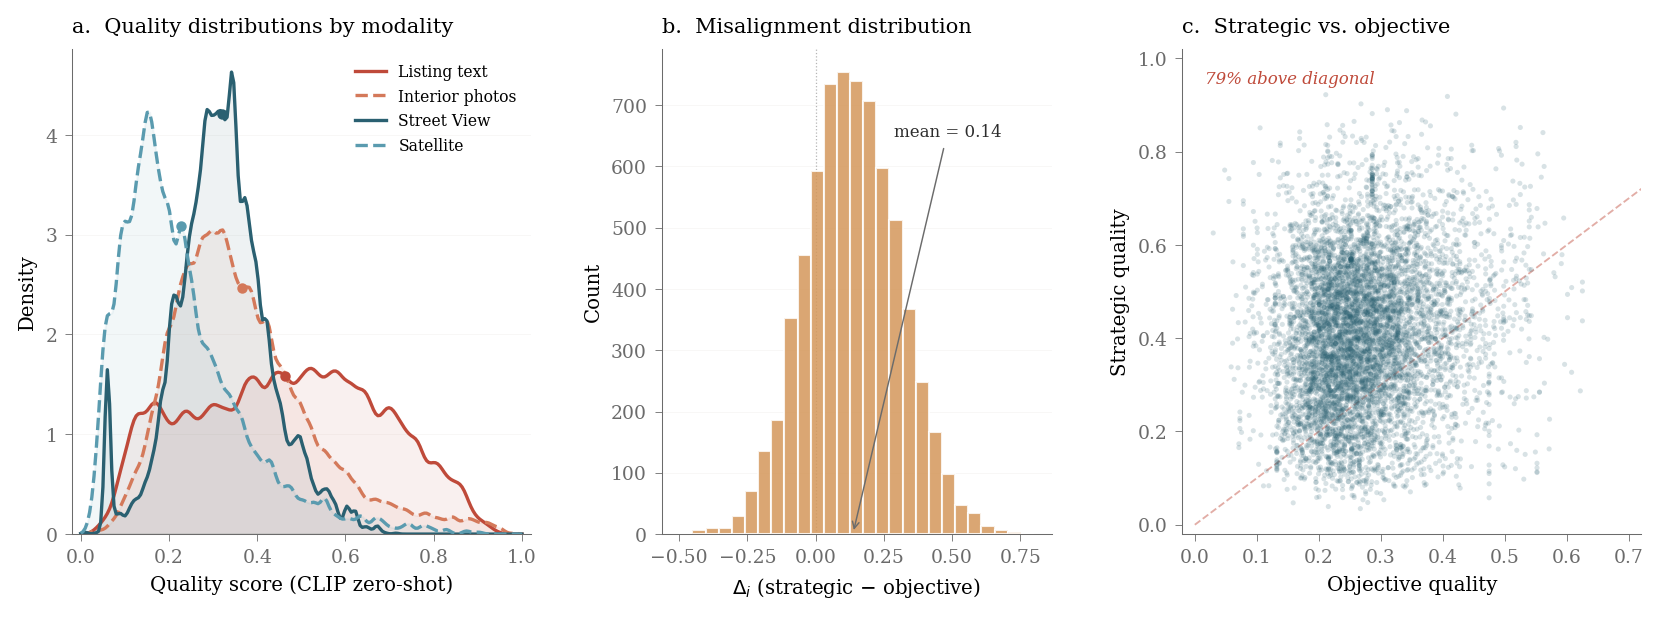

  saved: quality_misalignment.png


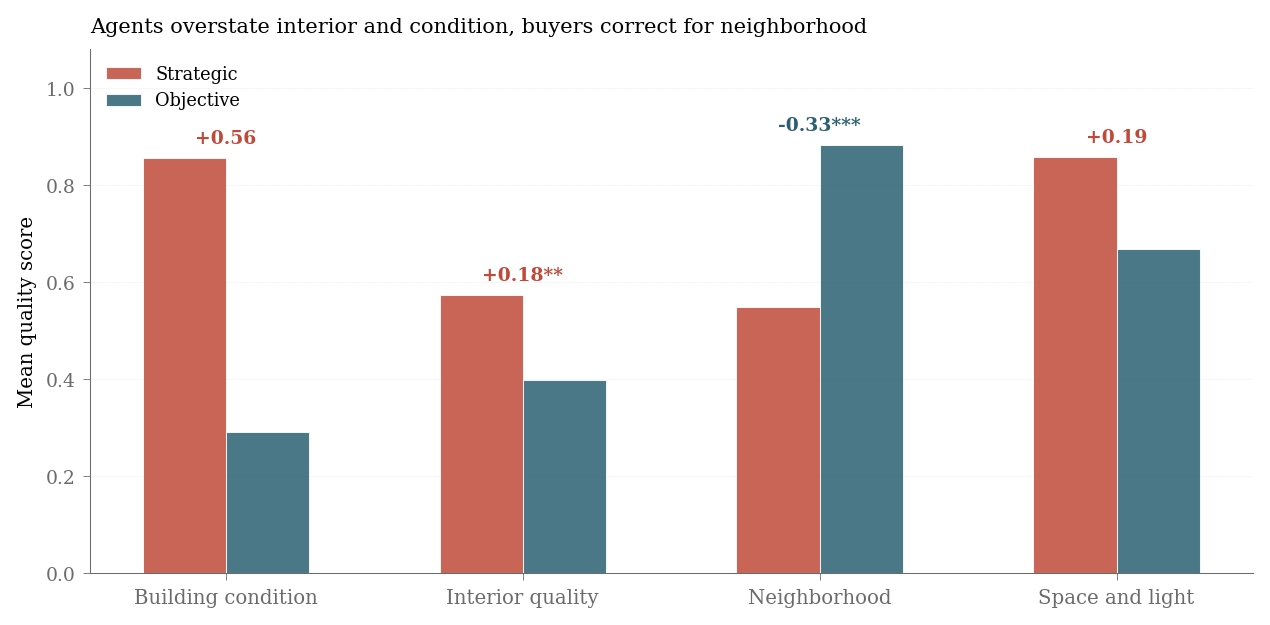

  saved: per_attribute.png


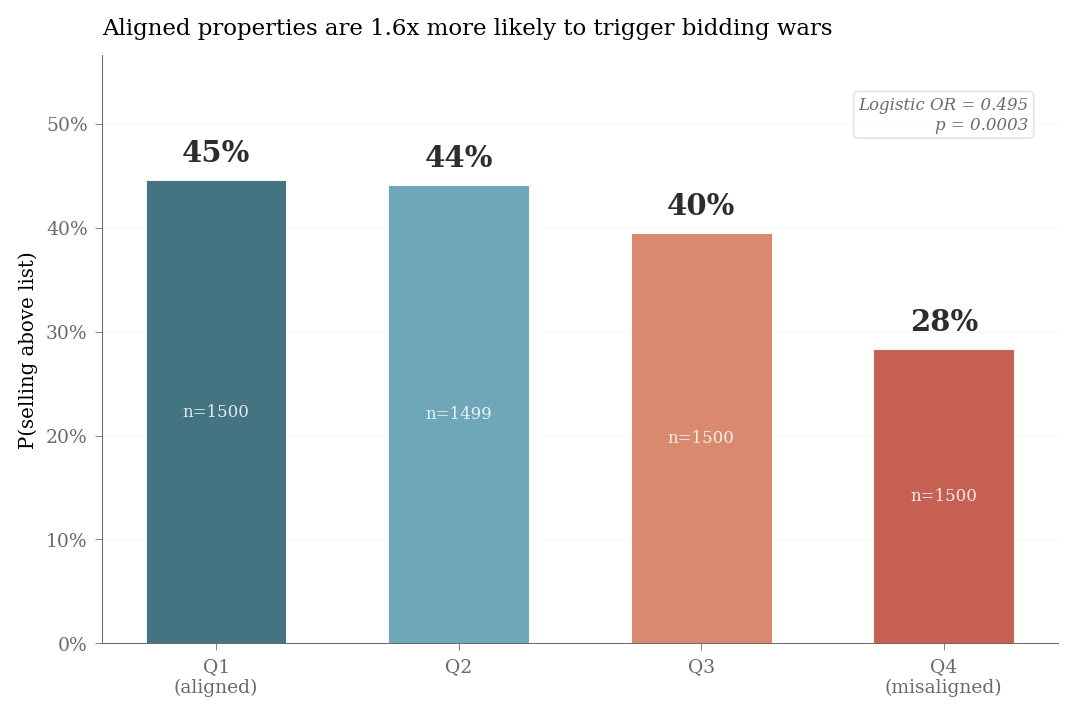

  saved: bidding_wars.png


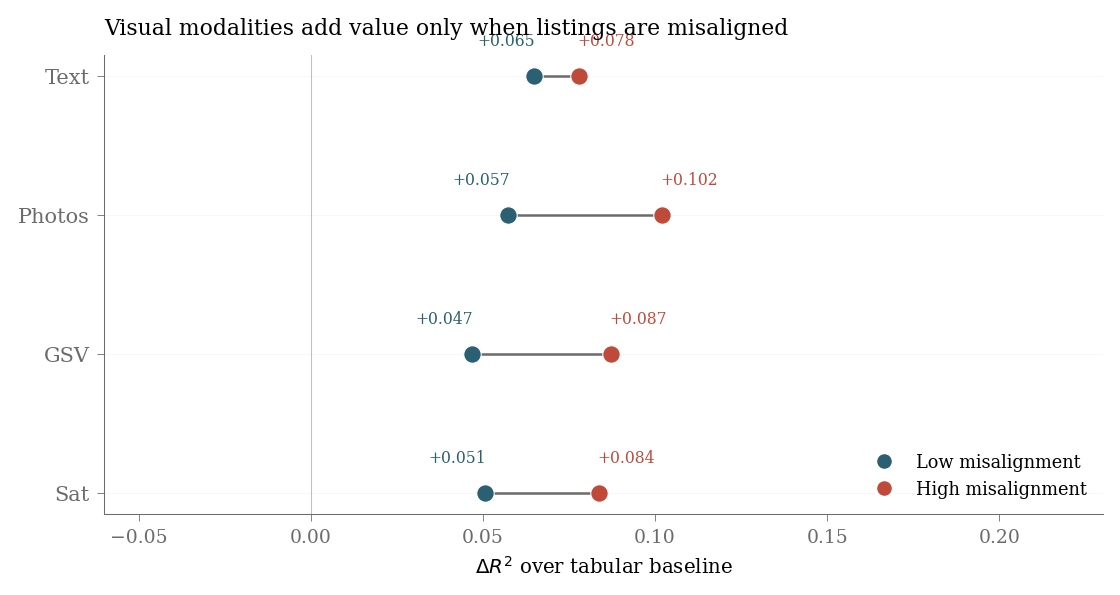

  saved: conditional_modality_value.png


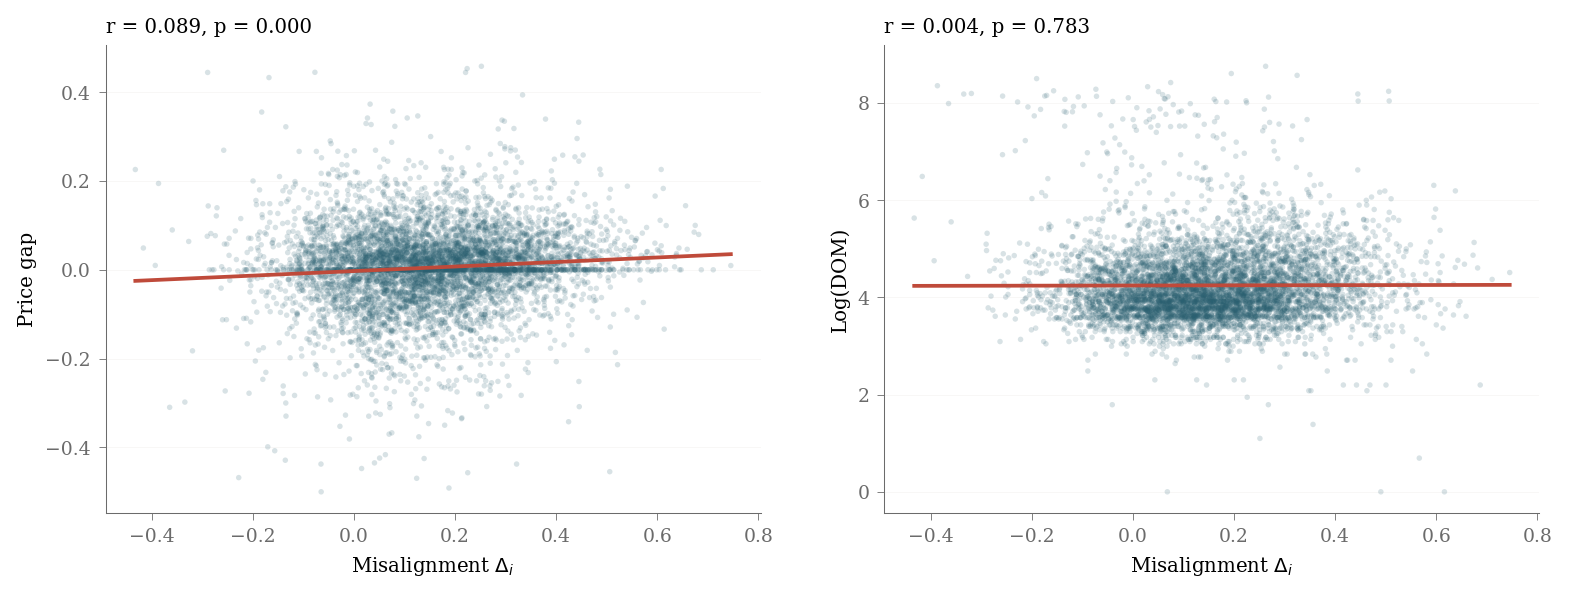

  saved: scatter_misalignment.png


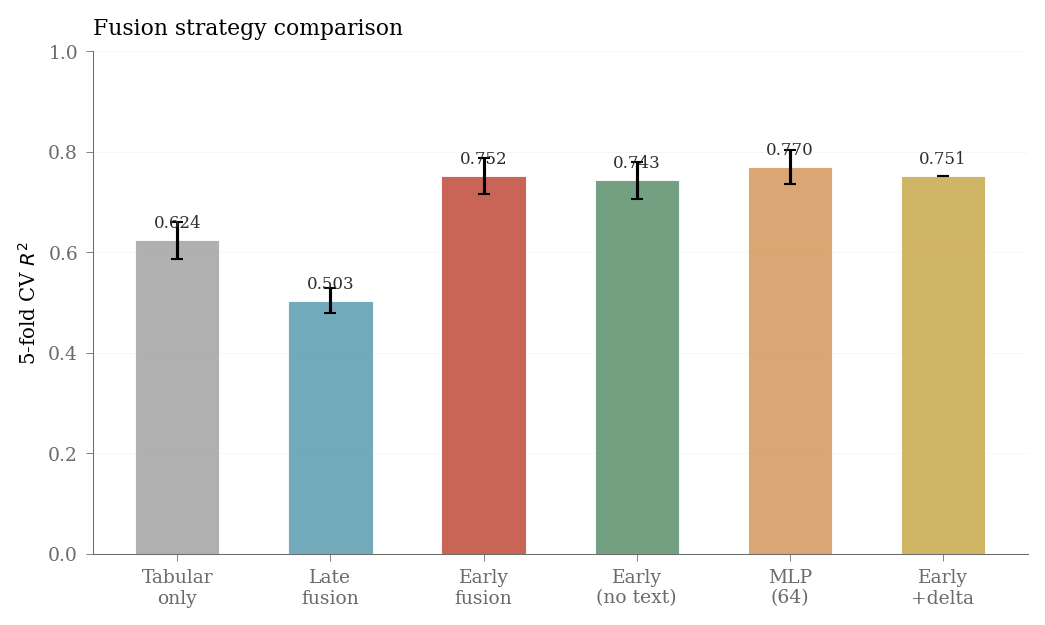

  saved: fusion_comparison.png


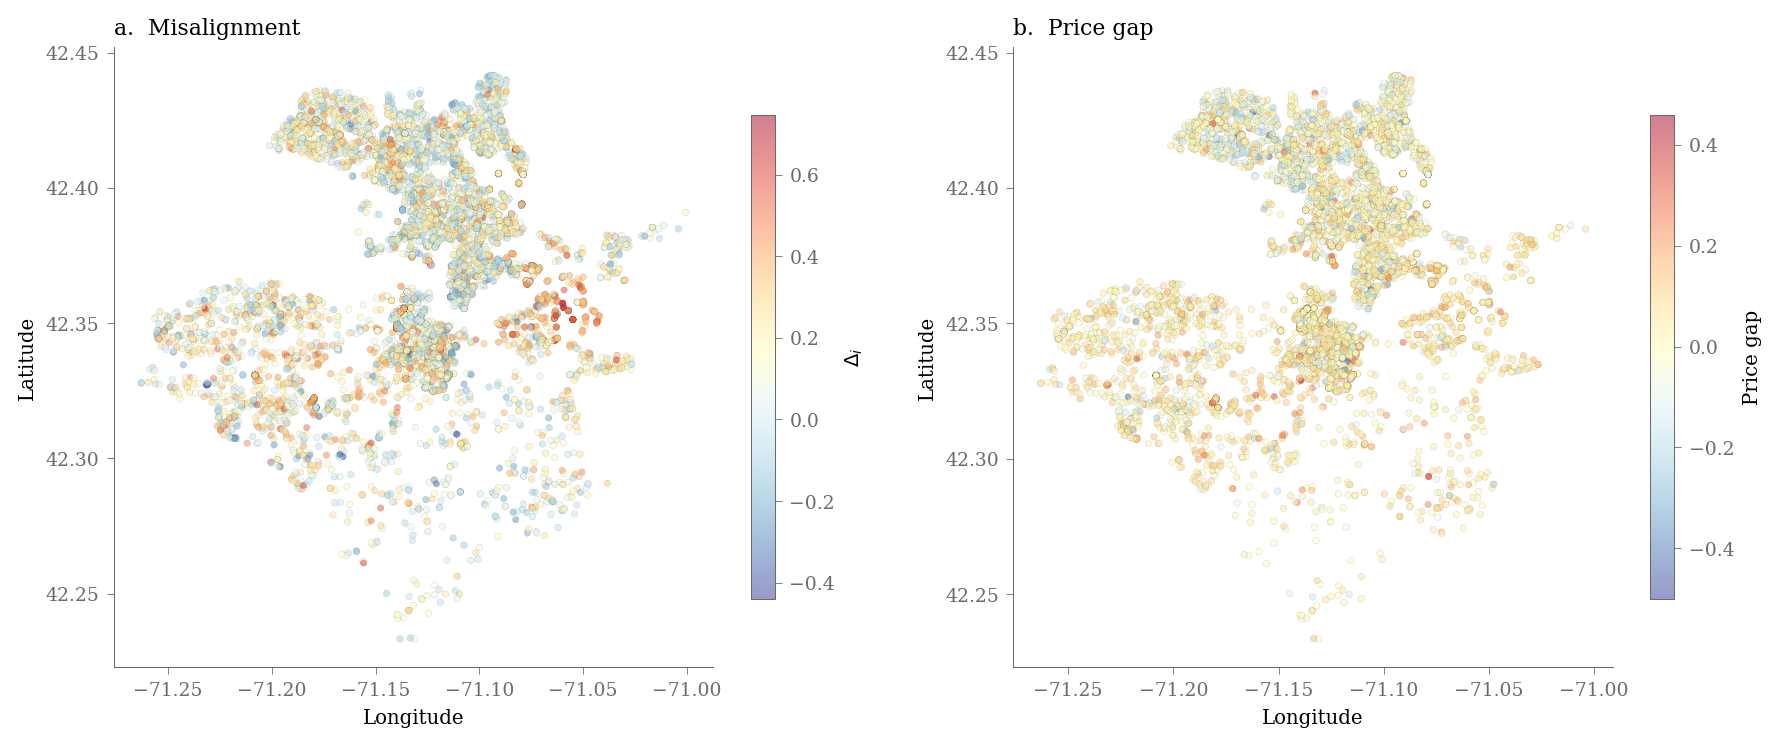

  saved: spatial_maps.png


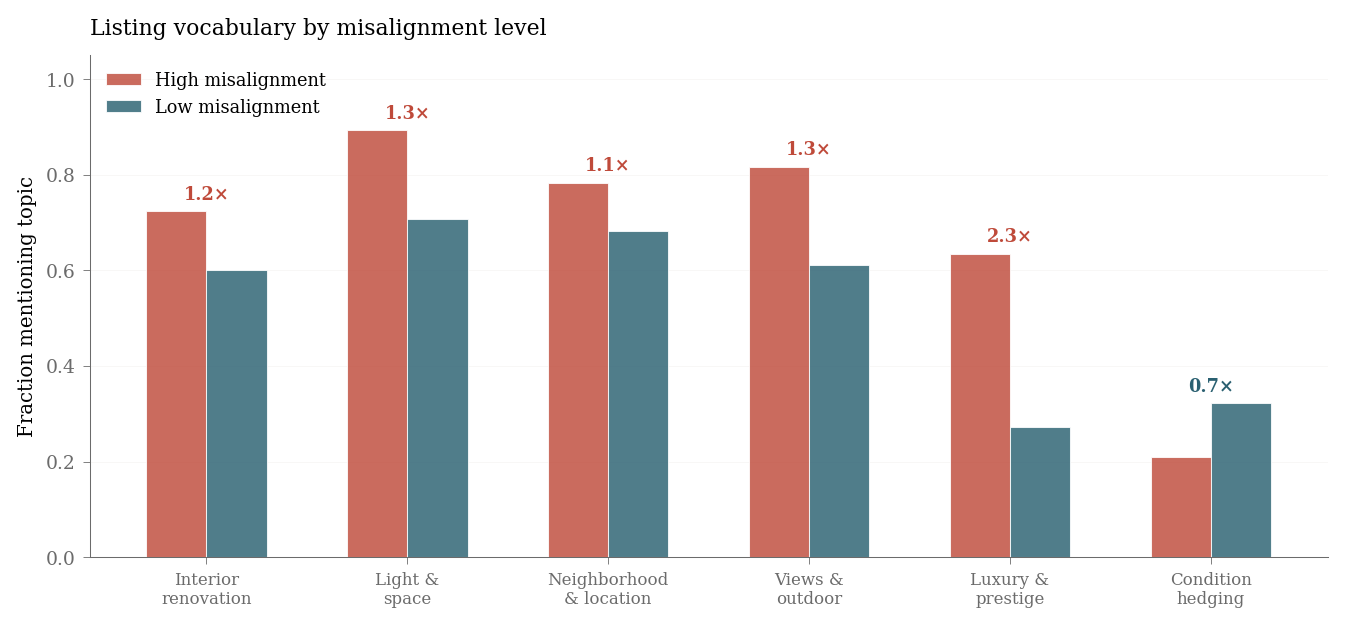

  saved: topic_analysis.png


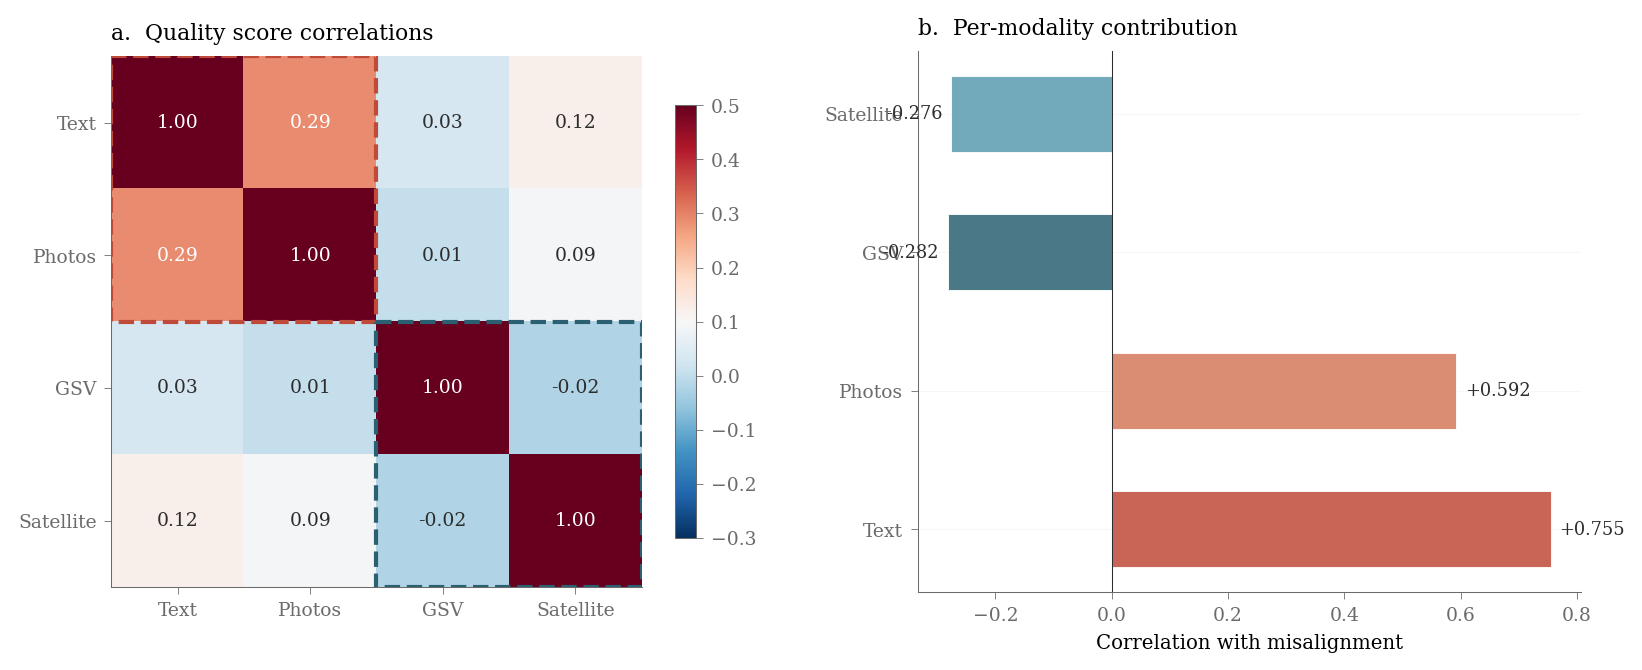

  saved: cross_modal_structure.png


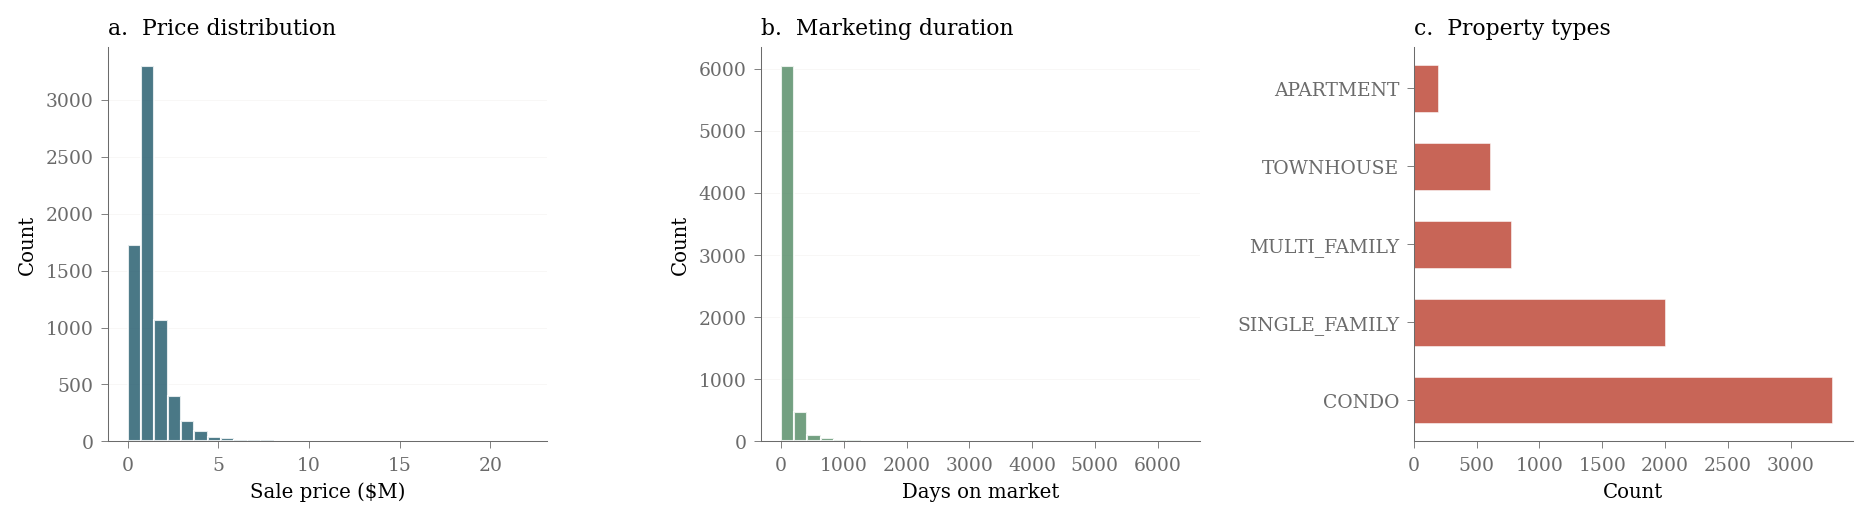

  saved: dataset_overview.png


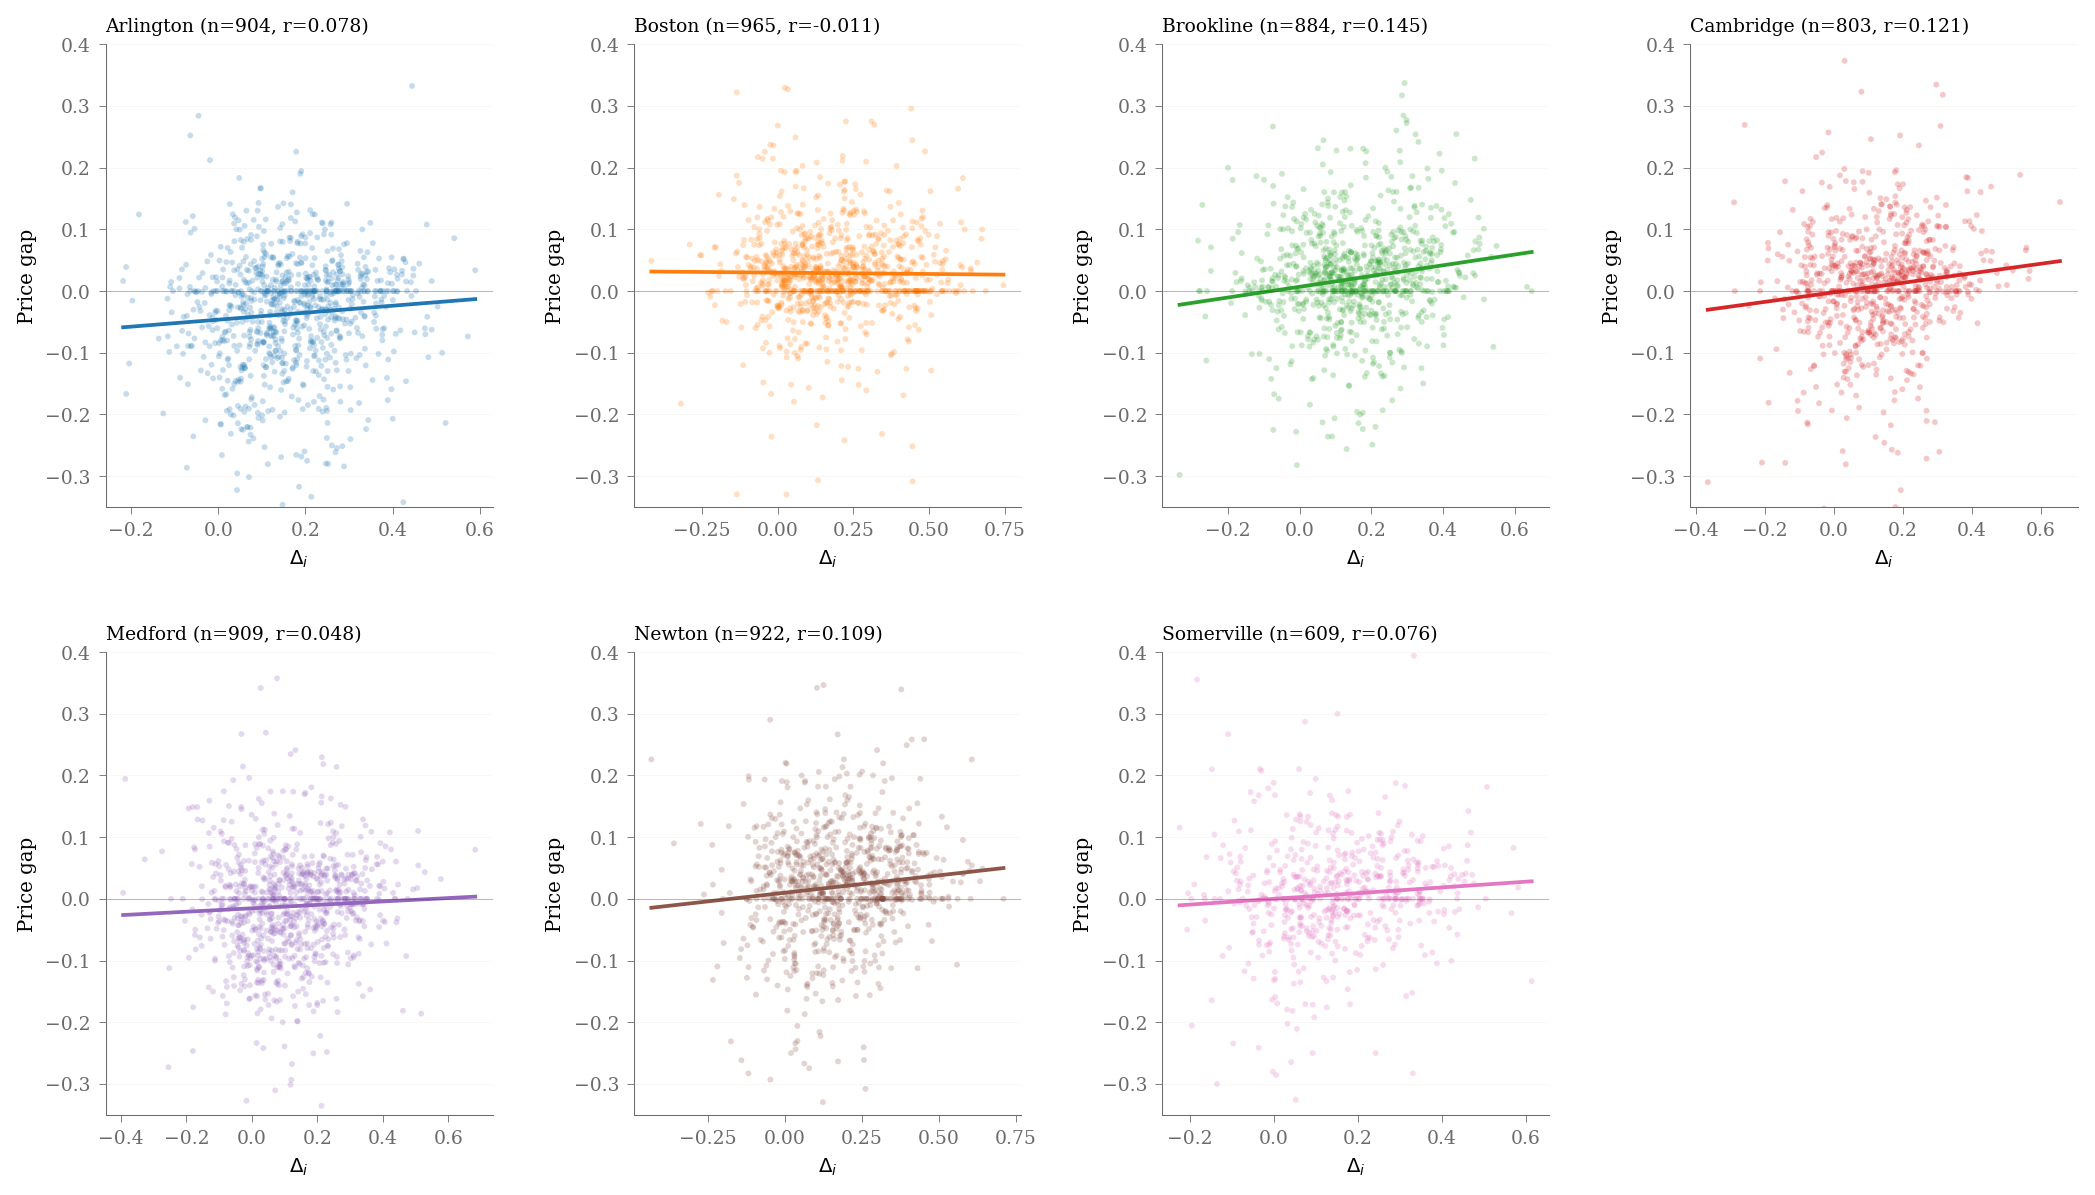

  saved: city_comparison.png


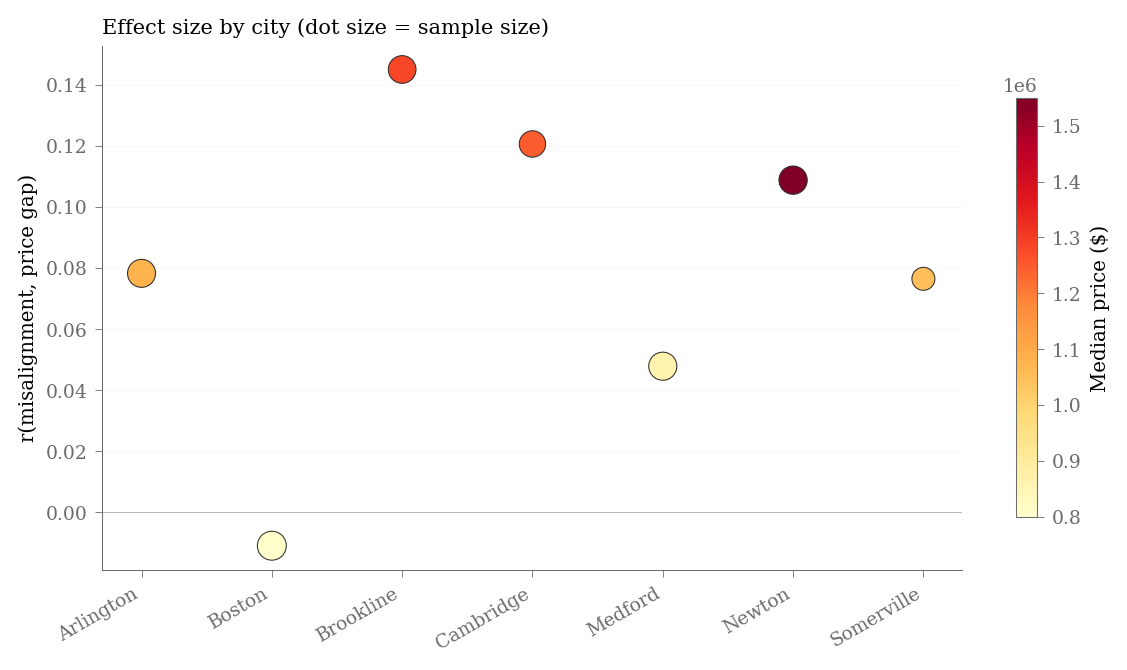

  saved: city_effect_sizes.png

12 figures saved to /content/figures

generating PID figure...


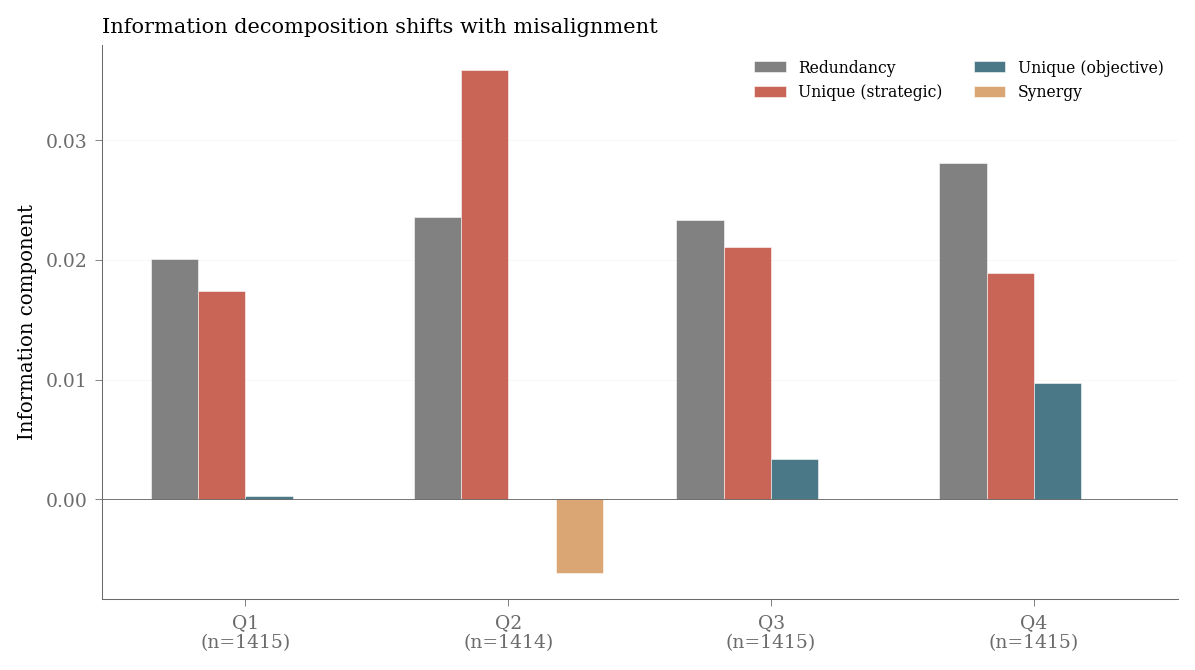

  saved: pid_by_quartile.png
generating CCA figure...


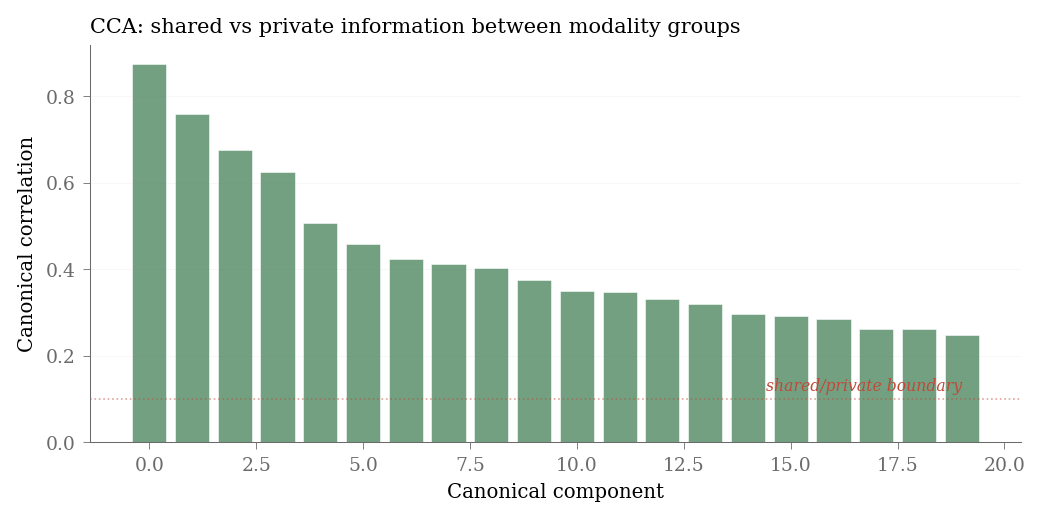

  saved: cca_spectrum.png
generating no-photo comparison figure...


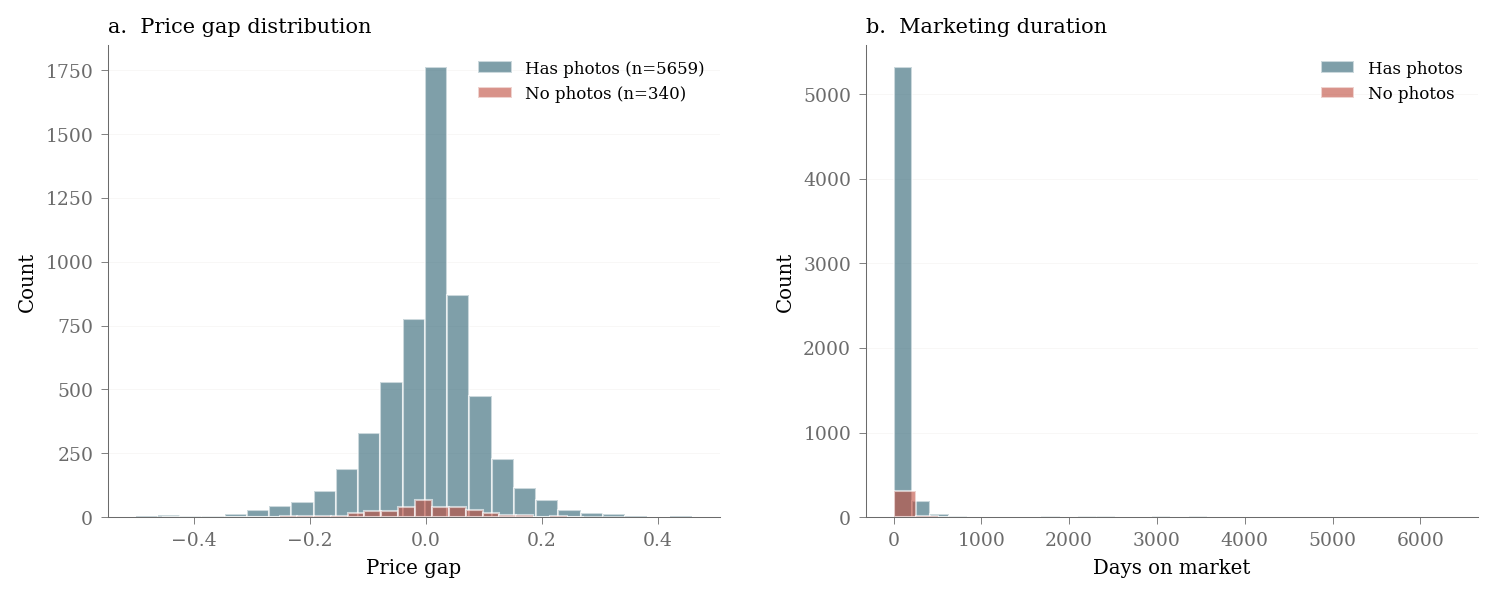

  saved: no_photo_comparison.png
generating subgroup heatmap...


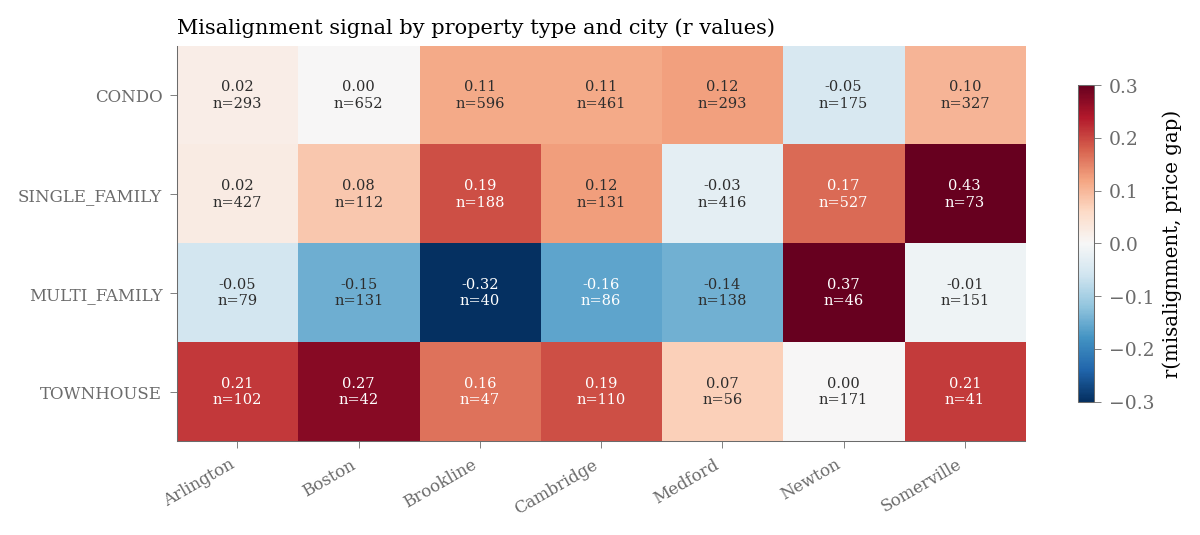

  saved: subgroup_heatmap.png
generating drift figure...


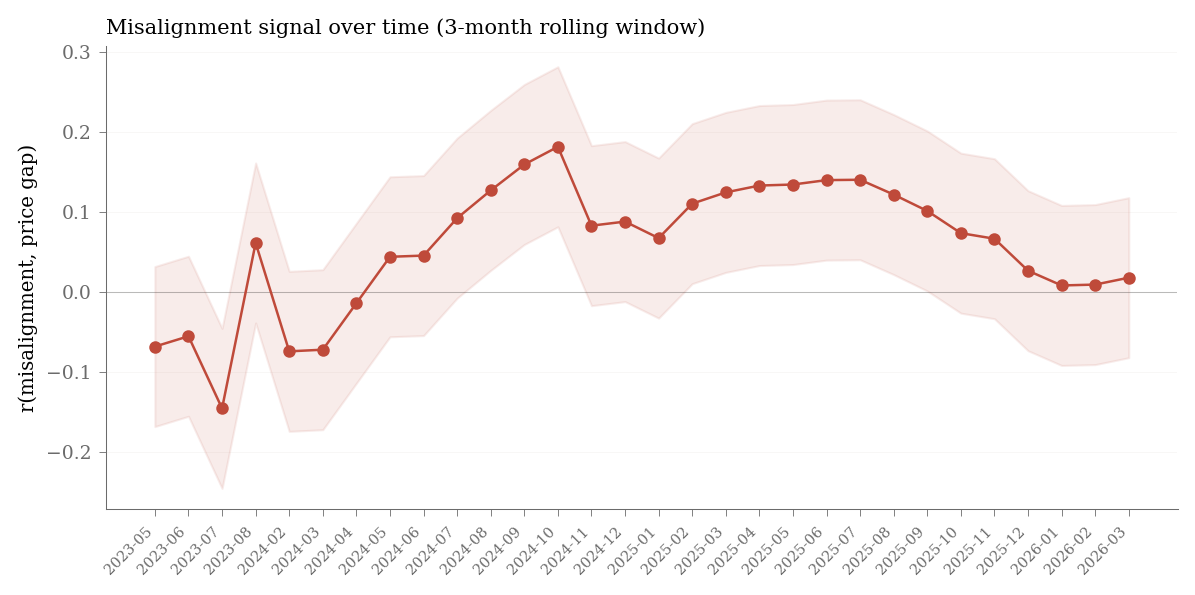

  saved: temporal_drift.png

total figures: 17
generating alignment distributions figure...


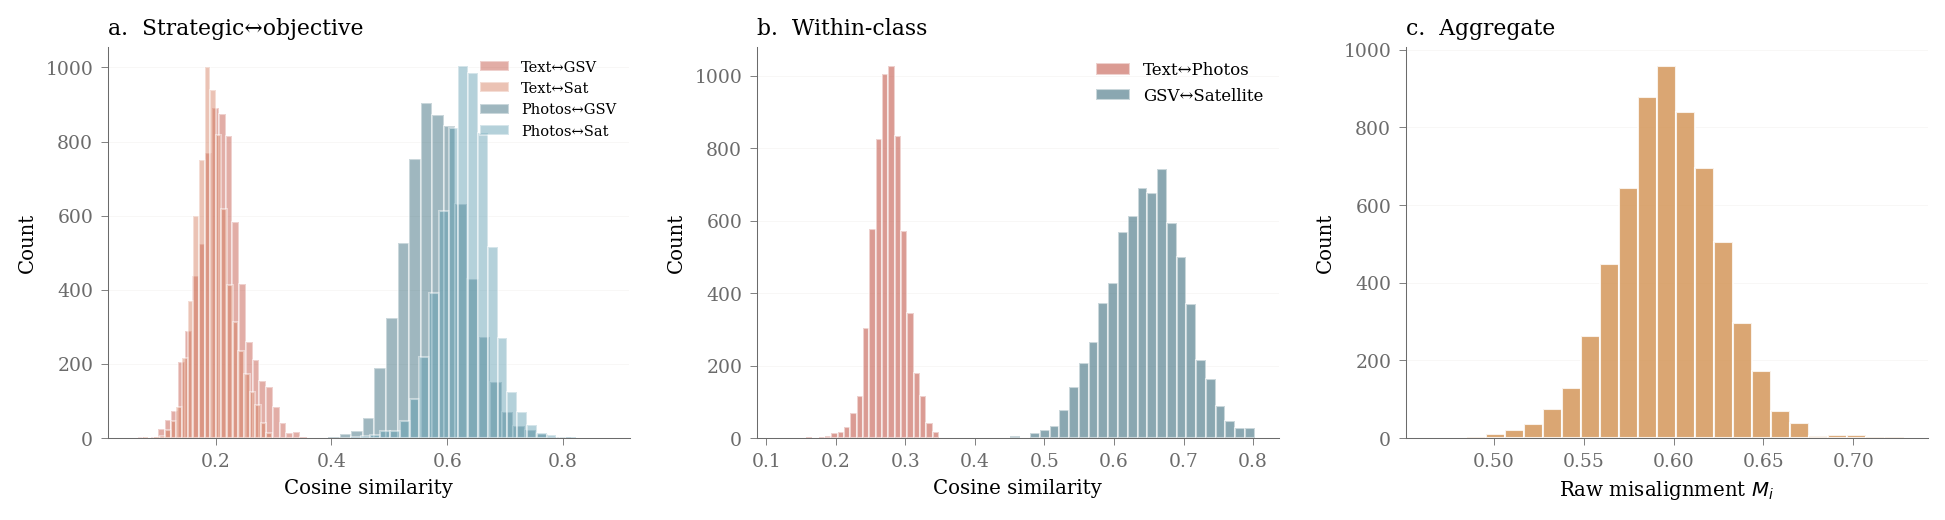

  saved: alignment_distributions.png
generating modality value by context figure...


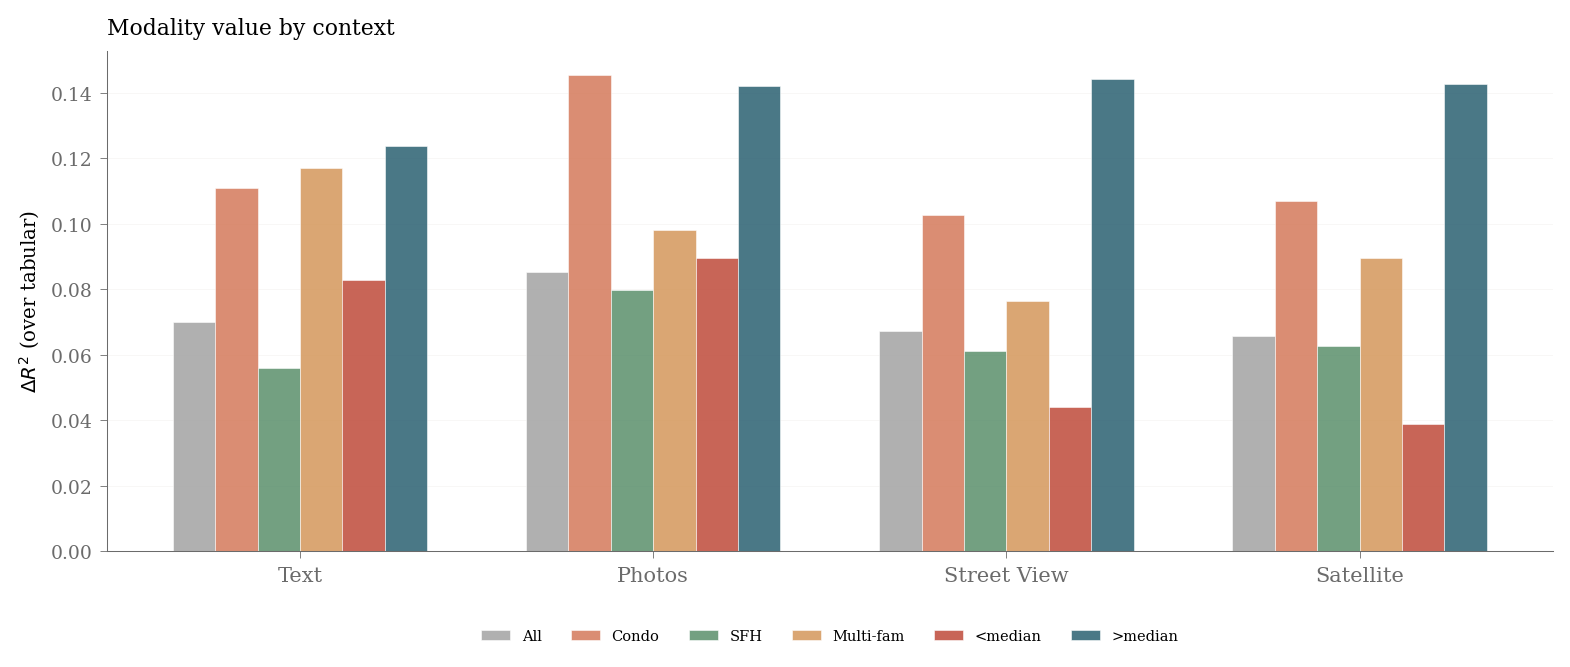

  saved: modality_value_by_context.png
generating interaction types figure...


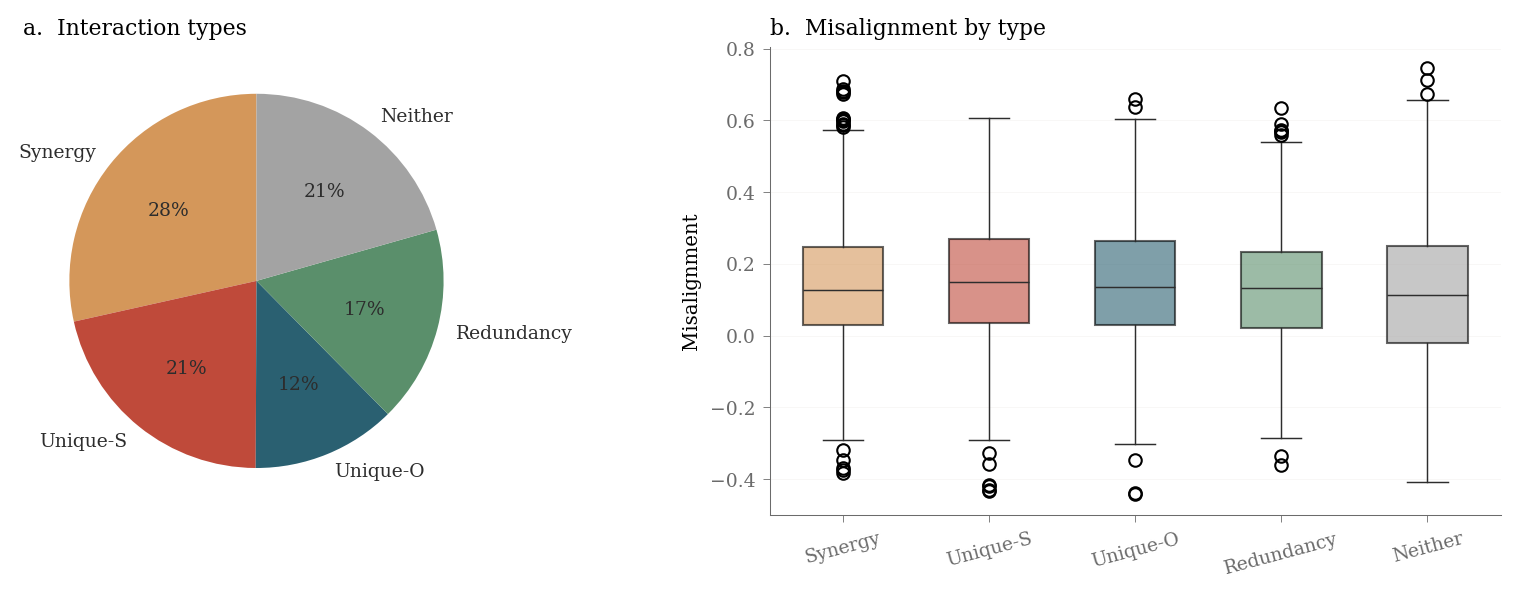

  saved: interaction_types.png


In [7]:
print("=" * 60)
print("GENERATING FIGURES")
print("=" * 60)

# quality distributions
fig = plt.figure(figsize=(13.5, 4.2))
gs = GridSpec(1, 3, width_ratios=[1, 0.85, 1], wspace=0.30)

ax = fig.add_subplot(gs[0])
for vals, label, color, ls in [
    (q_text[has_text],     'Listing text',    PAL['strat'],   '-'),
    (q_photos[has_photos], 'Interior photos', PAL['strat_l'], '--'),
    (q_gsv[has_gsv],       'Street View',     PAL['obj'],     '-'),
    (q_sat[has_sat],       'Satellite',       PAL['obj_l'],   '--')]:
    xs = np.linspace(0, 1, 200)
    kde = gaussian_kde(vals, bw_method=0.06)
    ax.plot(xs, kde(xs), color=color, lw=1.6, ls=ls, label=label)
    ax.fill_between(xs, kde(xs), alpha=0.08, color=color)
    m = vals.mean()
    ax.plot(m, kde(m), 'o', color=color, ms=4, zorder=5)
ax.set_xlabel('Quality score (CLIP zero-shot)')
ax.set_ylabel('Density')
ax.set_title('a.  Quality distributions by modality', loc='left', pad=8, fontsize=10, fontweight='medium')
ax.legend(fontsize=7.5, loc='upper right')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(bottom=0)
hgrid(ax)

ax = fig.add_subplot(gs[1])
bins = np.linspace(-0.5, 0.8, 28)
ax.hist(qm[valid_qm], bins=bins, color=PAL['accent'], edgecolor='white', lw=0.3, alpha=0.85, zorder=3)
ax.axvline(0, color=PAL['dark'], lw=0.6, ls=':', alpha=0.35)
mu = qm[valid_qm].mean()
ym = ax.get_ylim()[1]
ax.annotate(f'mean = {mu:.2f}', xy=(mu, 0), xytext=(mu+0.15, ym*0.82),
    fontsize=8, color=PAL['dark'], arrowprops=dict(arrowstyle='->', color=PAL['mid'], lw=0.7))
ax.set_xlabel('$\\Delta_i$ (strategic $-$ objective)')
ax.set_ylabel('Count')
ax.set_title('b.  Misalignment distribution', loc='left', pad=8, fontsize=10, fontweight='medium')
hgrid(ax)

ax = fig.add_subplot(gs[2])
ax.scatter(obj_q[valid_qm], strat_q[valid_qm], s=6, alpha=0.18,
    color=PAL['obj'], edgecolors='none', zorder=3, rasterized=True)
ax.plot([0,1], [0,1], color=PAL['strat'], lw=0.9, ls='--', alpha=0.45)
ax.set_xlabel('Objective quality'); ax.set_ylabel('Strategic quality')
ax.set_title('c.  Strategic vs. objective', loc='left', pad=8, fontsize=10, fontweight='medium')
pct = 100 * (strat_q[valid_qm] > obj_q[valid_qm]).mean()
ax.text(0.05, 0.93, f'{pct:.0f}% above diagonal', transform=ax.transAxes, fontsize=8,
    color=PAL['strat'], style='italic')
ax.set_xlim(-0.02, 0.72); ax.set_ylim(-0.02, 1.02)
savefig('quality_misalignment.png')

# per-attribute
fig, ax = plt.subplots(figsize=(8.5, 4.2))
a_names = list(attr_scores.keys())
s_vals = [attr_scores[a]['S'][np.isfinite(attr_scores[a]['gap'])].mean() for a in a_names]
o_vals = [attr_scores[a]['O'][np.isfinite(attr_scores[a]['gap'])].mean() for a in a_names]
x = np.arange(len(a_names)); w = 0.28
ax.bar(x-w/2, s_vals, w, color=PAL['strat'], alpha=0.85, edgecolor='white', lw=0.5,
    label='Strategic', zorder=3)
ax.bar(x+w/2, o_vals, w, color=PAL['obj'], alpha=0.85, edgecolor='white', lw=0.5,
    label='Objective', zorder=3)
for i in range(len(a_names)):
    gap = s_vals[i] - o_vals[i]
    ytop = max(s_vals[i], o_vals[i])
    v = np.isfinite(attr_scores[a_names[i]]['gap']) & valid_pg
    rv, pv = stats.pearsonr(attr_scores[a_names[i]]['gap'][v],
        df.loc[v, 'price_gap'].values) if v.sum() > 30 else (0, 1)
    star = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else ''
    clr = PAL['strat'] if gap > 0 else PAL['obj']
    ax.annotate(f'{gap:+.2f}{star}', xy=(x[i], ytop+0.03), ha='center', fontsize=9,
        color=clr, weight='bold')
ax.set_xticks(x); ax.set_xticklabels(a_names, fontsize=9.5)
ax.set_ylabel('Mean quality score')
ax.set_title('Agents overstate interior and condition, buyers correct for neighborhood',
    loc='left', pad=8, fontsize=10, fontweight='medium')
ax.legend(loc='upper left', fontsize=8.5); ax.set_ylim(0, 1.08)
hgrid(ax); plt.tight_layout()
savefig('per_attribute.png')

# bidding wars
reg_v = valid_pg & valid_qm
reg_i = np.where(reg_v)[0]
qm_r = qm[reg_i]
above_list = (df.iloc[reg_i]['price_gap'].values < 0).astype(int)
qe = np.percentile(qm_r, [25, 50, 75])
qb = np.digitize(qm_r, qe)
q_labs = ['Q1\n(aligned)', 'Q2', 'Q3', 'Q4\n(misaligned)']
q_rates = [above_list[qb==q].mean() for q in range(4)]
q_ns = [int((qb==q).sum()) for q in range(4)]
ratio14 = q_rates[0] / max(q_rates[3], 0.001)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
bcols = [PAL['obj'], PAL['obj_l'], PAL['strat_l'], PAL['strat']]
bars = ax.bar(q_labs, q_rates, color=bcols, edgecolor='white', lw=0.5, width=0.58, zorder=3, alpha=0.88)
for bar, rate, n in zip(bars, q_rates, q_ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
        f'{100*rate:.0f}%', ha='center', va='bottom', fontsize=14, weight='bold', color=PAL['dark'])
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
        f'n={n}', ha='center', va='center', fontsize=8, color='white', alpha=0.85)
ax.set_ylabel('P(selling above list)')
ax.set_title(f'Aligned properties are {ratio14:.1f}x more likely to trigger bidding wars',
    loc='left', pad=10, fontsize=11, fontweight='medium')
ax.set_ylim(0, max(q_rates)+0.12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
hgrid(ax)
ax.text(0.97, 0.93, f'Logistic OR = {np.exp(logit.params["qm"]):.3f}\np = {logit.pvalues["qm"]:.4f}',
    transform=ax.transAxes, fontsize=8, color=PAL['mid'], ha='right', va='top', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=PAL['grid'], alpha=0.8))
plt.tight_layout()
savefig('bidding_wars.png')

# conditional modality value dumbbell
mod_cmv = ['Text', 'Photos', 'GSV', 'Sat']
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ypos = np.arange(len(mod_cmv))[::-1]
for j, mn in enumerate(mod_cmv):
    lo, hi = cmv_results['low'][mn], cmv_results['high'][mn]
    yp = ypos[j]
    ax.plot([lo, hi], [yp, yp], color=PAL['mid'], lw=1.2, zorder=2)
    ax.scatter(lo, yp, s=70, color=PAL['obj'], zorder=4, edgecolors='white', lw=0.5)
    ax.scatter(hi, yp, s=70, color=PAL['strat'], zorder=4, edgecolors='white', lw=0.5)
    ax.text(lo-0.008, yp+0.22, f'{lo:+.3f}', ha='center', fontsize=7.5, color=PAL['obj'])
    ax.text(hi+0.008, yp+0.22, f'{hi:+.3f}', ha='center', fontsize=7.5, color=PAL['strat'])
ax.axvline(0, color=PAL['dark'], lw=0.5, alpha=0.3, zorder=1)
ax.set_yticks(ypos); ax.set_yticklabels(mod_cmv, fontsize=10)
ax.set_xlabel('$\\Delta R^2$ over tabular baseline')
ax.set_title('Visual modalities add value only when listings are misaligned',
    loc='left', pad=10, fontsize=10.5, fontweight='medium')
leg = [Line2D([0],[0], marker='o', color='w', mfc=PAL['obj'], ms=8, label='Low misalignment'),
       Line2D([0],[0], marker='o', color='w', mfc=PAL['strat'], ms=8, label='High misalignment')]
ax.legend(handles=leg, loc='lower right', fontsize=8.5)
ax.set_xlim(-0.06, max(max(cmv_results['high'].values()), 0.2) + 0.03)
hgrid(ax); plt.tight_layout()
savefig('conditional_modality_value.png')

# scatter: misalignment vs price gap + DOM
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for ax, yv, yl in [(axes[0], y_gap, 'Price gap'), (axes[1], y_dom, 'Log(DOM)')]:
    ax.scatter(qm_r, yv, s=7, alpha=0.18, color=PAL['obj'], edgecolors='none', rasterized=True)
    z = np.polyfit(qm_r, yv, 1)
    xl = np.linspace(qm_r.min(), qm_r.max(), 50)
    ax.plot(xl, np.polyval(z, xl), color=PAL['strat'], lw=1.8)
    r, p = stats.pearsonr(qm_r, yv)
    ax.set_xlabel('Misalignment $\\Delta_i$'); ax.set_ylabel(yl)
    ax.set_title(f'r = {r:.3f}, p = {p:.3f}', loc='left', pad=6, fontsize=9.5)
    hgrid(ax)
plt.tight_layout(w_pad=3)
savefig('scatter_misalignment.png')

# fusion comparison
fig, ax = plt.subplots(figsize=(7, 4.2))
fl = ['Tabular\nonly', 'Late\nfusion', 'Early\nfusion', 'Early\n(no text)', 'MLP\n(64)', 'Early\n+delta']
fv = [tab_r2, np.mean(late_sc), np.mean(early_sc), np.mean(early_nt_sc),
      np.mean(mlp_sc), r2_aug]
fe = [tab_std, np.std(late_sc), np.std(early_sc), np.std(early_nt_sc),
      np.std(mlp_sc), 0]
fc = [PAL['light'], PAL['obj_l'], PAL['strat'], PAL['green'], PAL['accent'], PAL['gold']]
bars = ax.bar(fl, fv, yerr=fe, color=fc, edgecolor='white', lw=0.5, capsize=3, alpha=0.85, width=0.55)
for bar, v in zip(bars, fv):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.025,
            f'{v:.3f}', ha='center', fontsize=8, color=PAL['dark'])
ax.set_ylabel('5-fold CV $R^2$')
ax.set_title('Fusion strategy comparison', loc='left', pad=8)
ax.set_ylim(0, 1.0); hgrid(ax); plt.tight_layout()
savefig('fusion_comparison.png')

# spatial maps
sp = valid_qm & df['lat'].notna().values & df['lon'].notna().values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc1 = axes[0].scatter(df.loc[sp, 'lon'], df.loc[sp, 'lat'], c=qm[sp],
    cmap='RdYlBu_r', s=10, alpha=0.5, edgecolors=PAL['dark'], lw=0.08)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].set_title('a.  Misalignment', loc='left', pad=6)
plt.colorbar(sc1, ax=axes[0], shrink=0.78, label='$\\Delta_i$')
sp2 = sp & valid_pg
sc2 = axes[1].scatter(df.loc[sp2, 'lon'], df.loc[sp2, 'lat'],
    c=df.loc[sp2, 'price_gap'], cmap='RdYlBu_r', s=10, alpha=0.5, edgecolors=PAL['dark'], lw=0.08)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_title('b.  Price gap', loc='left', pad=6)
plt.colorbar(sc2, ax=axes[1], shrink=0.78, label='Price gap')
plt.tight_layout(w_pad=2)
savefig('spatial_maps.png')

# topic analysis
kw_groups = {
    'Interior\nrenovation': ['renovated', 'updated', 'remodeled', 'granite', 'stainless', 'hardwood',
        'quartz', 'marble', 'chef'],
    'Light &\nspace': ['sun', 'bright', 'light', 'spacious', 'open', 'airy', 'soaring', 'vaulted'],
    'Neighborhood\n& location': ['neighborhood', 'walkable', 'transit', 'downtown',
        'restaurant', 'shop', 'vibrant', 'convenient', 'location'],
    'Views &\noutdoor': ['view', 'views', 'deck', 'patio', 'balcony', 'yard', 'garden', 'outdoor', 'skyline'],
    'Luxury &\nprestige': ['luxury', 'elegant', 'stunning', 'exquisite', 'premium',
        'exceptional', 'designer', 'custom', 'prestigious'],
    'Condition\nhedging': ['potential', 'opportunity', 'investor', 'as-is', 'cosmetic', 'tlc', 'handyman', 'fixer'],
}
def kw_frac(descs, kws):
    n, hit = 0, 0
    for d in descs:
        if not isinstance(d, str): continue
        n += 1
        if any(k in d.lower() for k in kws): hit += 1
    return hit / max(n, 1)
cats = list(kw_groups.keys())
hv = [kw_frac(df.loc[high_mis, 'listing_description'], kw_groups[c]) for c in cats]
lv = [kw_frac(df.loc[low_mis, 'listing_description'], kw_groups[c]) for c in cats]
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(cats)); w = 0.30
ax.bar(x-w/2, hv, w, color=PAL['strat'], alpha=0.82, edgecolor='white', lw=0.5,
    label='High misalignment', zorder=3)
ax.bar(x+w/2, lv, w, color=PAL['obj'], alpha=0.82, edgecolor='white', lw=0.5,
    label='Low misalignment', zorder=3)
for i in range(len(cats)):
    ratio = hv[i] / max(lv[i], 0.001)
    if abs(ratio - 1) > 0.1:
        clr = PAL['strat'] if ratio > 1 else PAL['obj']
        ax.text(x[i], max(hv[i], lv[i])+0.025, f'{ratio:.1f}\u00d7', ha='center',
            fontsize=8.5, color=clr, weight='bold')
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=8, linespacing=1.1)
ax.set_ylabel('Fraction mentioning topic')
ax.set_title('Listing vocabulary by misalignment level', loc='left', pad=10)
ax.legend(loc='upper left', fontsize=8.5); ax.set_ylim(0, 1.05)
hgrid(ax); plt.tight_layout()
savefig('topic_analysis.png')

# correlation heatmap
hm = has_text & has_photos & has_gsv & has_sat
qmat = np.column_stack([q_text[hm], q_photos[hm], q_gsv[hm], q_sat[hm]])
corr = np.corrcoef(qmat.T)
hlabels = ['Text', 'Photos', 'GSV', 'Satellite']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-0.3, vmax=0.5, aspect='equal')
for i in range(4):
    for j in range(4):
        tc = 'white' if abs(corr[i,j]) > 0.2 else PAL['dark']
        axes[0].text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=9, color=tc)
axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
axes[0].set_xticklabels(hlabels, fontsize=9); axes[0].set_yticklabels(hlabels, fontsize=9)
axes[0].set_title('a.  Quality score correlations', loc='left', pad=8)
plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].add_patch(Rectangle((-0.5,-0.5), 2, 2, fill=False, ec=PAL['strat'], lw=2, ls='--'))
axes[0].add_patch(Rectangle((1.5,1.5), 2, 2, fill=False, ec=PAL['obj'], lw=2, ls='--'))

contribs = {nm: stats.pearsonr(sc[valid_qm], qm[valid_qm])[0]
    for nm, sc in [('Text', q_text), ('Photos', q_photos), ('GSV', q_gsv), ('Satellite', q_sat)]}
cn, cv = list(contribs.keys()), [contribs[n] for n in contribs]
cc = [PAL['strat'], PAL['strat_l'], PAL['obj'], PAL['obj_l']]
axes[1].barh(cn, cv, color=cc, edgecolor='white', lw=0.5, height=0.55, alpha=0.85)
axes[1].set_xlabel('Correlation with misalignment')
axes[1].set_title('b.  Per-modality contribution', loc='left', pad=8)
axes[1].axvline(0, color=PAL['dark'], lw=0.5)
for bar, v in zip(axes[1].patches, cv):
    ha = 'left' if v > 0 else 'right'
    axes[1].text(v + (0.015 if v > 0 else -0.015), bar.get_y()+bar.get_height()/2,
        f'{v:+.3f}', va='center', ha=ha, fontsize=8.5, color=PAL['dark'])
hgrid(axes[1]); plt.tight_layout(w_pad=3)
savefig('cross_modal_structure.png')

# dataset overview
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5))
axes[0].hist(df['price']/1e6, bins=30, color=PAL['obj'], edgecolor='white', lw=0.3, alpha=0.85)
axes[0].set_xlabel('Sale price ($M)'); axes[0].set_ylabel('Count')
axes[0].set_title('a.  Price distribution', loc='left', pad=6); hgrid(axes[0])
axes[1].hist(df['days_on_market'].dropna(), bins=30, color=PAL['green'], edgecolor='white', lw=0.3, alpha=0.85)
axes[1].set_xlabel('Days on market'); axes[1].set_ylabel('Count')
axes[1].set_title('b.  Marketing duration', loc='left', pad=6); hgrid(axes[1])
tc = df['home_type'].value_counts()
axes[2].barh(tc.index, tc.values, color=PAL['strat'], edgecolor='white', lw=0.3, alpha=0.85, height=0.6)
axes[2].set_xlabel('Count')
axes[2].set_title('c.  Property types', loc='left', pad=6)
plt.tight_layout(w_pad=2)
savefig('dataset_overview.png')

# city comparison
cities_with_data = []
for cg in sorted(df['city_group'].unique()):
    if cg == 'Other': continue
    cm = (df['city_group'] == cg).values & valid_pg & valid_qm
    if cm.sum() >= 20:
        cities_with_data.append(cg)

n_cities = len(cities_with_data)
if n_cities > 0:
    ncols = min(n_cities, 4)
    nrows = (n_cities + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 4*nrows), squeeze=False)
    city_colors = {c: plt.cm.tab10(i) for i, c in enumerate(cities_with_data)}

    for idx_c, cg in enumerate(cities_with_data):
        row, col = idx_c // ncols, idx_c % ncols
        ax = axes[row][col]
        cm = (df['city_group'] == cg).values & valid_pg & valid_qm
        ci = np.where(cm)[0]
        r, p = stats.pearsonr(qm[ci], df.iloc[ci]['price_gap'].values)
        ax.scatter(qm[ci], df.iloc[ci]['price_gap'].values, s=8, alpha=0.25,
            color=city_colors[cg], edgecolors='none', rasterized=True)
        z = np.polyfit(qm[ci], df.iloc[ci]['price_gap'].values, 1)
        xl = np.linspace(qm[ci].min(), qm[ci].max(), 100)
        ax.plot(xl, np.polyval(z, xl), color=city_colors[cg], lw=1.8)
        ax.axhline(0, color=PAL['dark'], lw=0.5, alpha=0.3)
        ax.set_xlabel('$\\Delta_i$'); ax.set_ylabel('Price gap')
        ax.set_title(f'{cg} (n={len(ci)}, r={r:.3f})', loc='left', fontsize=9, fontweight='medium')
        ax.set_ylim(-0.35, 0.4); hgrid(ax)

    # blank out unused panels
    for idx_c in range(n_cities, nrows * ncols):
        row, col = idx_c // ncols, idx_c % ncols
        axes[row][col].set_visible(False)
    plt.tight_layout(w_pad=2, h_pad=3)
    savefig('city_comparison.png')

# city effect sizes
if n_cities >= 3:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    city_rs, city_ns, city_medp = [], [], []
    for cg in cities_with_data:
        cm = (df['city_group'] == cg).values & valid_pg & valid_qm
        ci = np.where(cm)[0]
        r, _ = stats.pearsonr(qm[ci], df.iloc[ci]['price_gap'].values)
        city_rs.append(r)
        city_ns.append(len(ci))
        city_medp.append(df.iloc[ci]['price'].median())
    # color by median price
    sc = ax.scatter(range(len(cities_with_data)), city_rs,
        s=[n/5 for n in city_ns], c=city_medp, cmap='YlOrRd', edgecolors=PAL['dark'],
        lw=0.5, zorder=3)
    ax.set_xticks(range(len(cities_with_data)))
    ax.set_xticklabels(cities_with_data, rotation=30, ha='right')
    ax.set_ylabel('r(misalignment, price gap)')
    ax.axhline(0, color=PAL['dark'], lw=0.5, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Median price ($)', shrink=0.8)
    ax.set_title('Effect size by city (dot size = sample size)', loc='left', fontsize=10, fontweight='medium')
    hgrid(ax); plt.tight_layout()
    savefig('city_effect_sizes.png')

print(f"\n{len(list(FIGS.glob('*.png')))} figures saved to {FIGS}")

# PID by misalignment quartile
print("\ngenerating PID figure...")
try:
    pid_mask_f = complete & valid_pg
    pid_idx_f = np.where(pid_mask_f)[0]
    qm_pid_f = qm[pid_idx_f]
    qe_pid = np.percentile(qm_pid_f[np.isfinite(qm_pid_f)], [25, 50, 75])
    qb_pid = np.digitize(qm_pid_f, qe_pid)
    pid_vals = {'R': [], 'Us': [], 'Uo': [], 'S': []}
    pid_ns = []
    for qi in range(4):
        sub = pid_idx_f[qb_pid == qi]
        if len(sub) < 30:
            for k in pid_vals: pid_vals[k].append(0)
            pid_ns.append(0)
            continue
        Xt = TAB_s[sub]
        Xs_p = np.column_stack([pca_text[sub], pca_photos[sub]])
        Xo_p = np.column_stack([pca_gsv[sub], pca_sat[sub]])
        tgt = df.iloc[sub]['price_gap'].values
        r2_t, _ = cv_r2(Xt, tgt)
        r2_ts, _ = cv_r2(np.column_stack([Xt, Xs_p]), tgt)
        r2_to, _ = cv_r2(np.column_stack([Xt, Xo_p]), tgt)
        r2_tso, _ = cv_r2(np.column_stack([Xt, Xs_p, Xo_p]), tgt)
        i_s = r2_ts - r2_t; i_o = r2_to - r2_t; i_so = r2_tso - r2_t
        pid_vals['R'].append(max(0, i_s + i_o - i_so))
        pid_vals['Us'].append(max(0, i_so - i_o))
        pid_vals['Uo'].append(max(0, i_so - i_s))
        pid_vals['S'].append(i_so - max(0, i_so - i_o) - max(0, i_so - i_s) - max(0, i_s + i_o - i_so))
        pid_ns.append(len(sub))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(4)
    w = 0.18
    pid_colors = {'R': PAL['mid'], 'Us': PAL['strat'], 'Uo': PAL['obj'], 'S': PAL['accent']}
    pid_labels = {'R': 'Redundancy', 'Us': 'Unique (strategic)', 'Uo': 'Unique (objective)', 'S': 'Synergy'}
    for mi, (comp, vals) in enumerate(pid_vals.items()):
        ax.bar(x + mi*w, vals, w, label=pid_labels[comp], color=pid_colors[comp],
            edgecolor='white', lw=0.3, alpha=0.85)
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels([f'Q{q+1}\n(n={pid_ns[q]})' for q in range(4)])
    ax.set_ylabel('Information component')
    ax.set_title('Information decomposition shifts with misalignment', loc='left', fontsize=10, fontweight='medium')
    ax.legend(fontsize=7.5, ncol=2); ax.axhline(0, color=PAL['dark'], lw=0.3)
    hgrid(ax); plt.tight_layout()
    savefig('pid_by_quartile.png')
except Exception as e:
    print(f"  PID figure failed: {e}")

# CCA canonical correlation spectrum
print("generating CCA figure...")
try:
    if 'can_corrs' in dir() and can_corrs:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        n_cc = len(can_corrs)
        colors_cc = [PAL['green'] if c > 0.1 else PAL['light'] for c in can_corrs]
        ax.bar(range(n_cc), can_corrs, color=colors_cc, edgecolor='white', lw=0.3, alpha=0.85)
        ax.axhline(0.1, color=PAL['strat'], lw=0.8, ls=':', alpha=0.5)
        ax.text(n_cc-1, 0.12, 'shared/private boundary', ha='right', fontsize=7.5,
            color=PAL['strat'], style='italic')
        ax.set_xlabel('Canonical component')
        ax.set_ylabel('Canonical correlation')
        ax.set_title('CCA: shared vs private information between modality groups',
            loc='left', fontsize=10, fontweight='medium')
        hgrid(ax); plt.tight_layout()
        savefig('cca_spectrum.png')
except Exception as e:
    print(f"  CCA figure failed: {e}")

# no-photo vs with-photo comparison
print("generating no-photo comparison figure...")
try:
    np_mask = ~has_photos & has_text & has_gsv & valid_pg
    wp_mask = has_photos & has_text & has_gsv & valid_pg
    if np_mask.sum() > 10 and wp_mask.sum() > 10:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].hist(df.loc[wp_mask, 'price_gap'].dropna(), bins=25, alpha=0.6,
            color=PAL['obj'], label=f'Has photos (n={wp_mask.sum()})', edgecolor='white', lw=0.2)
        axes[0].hist(df.loc[np_mask, 'price_gap'].dropna(), bins=25, alpha=0.6,
            color=PAL['strat'], label=f'No photos (n={np_mask.sum()})', edgecolor='white', lw=0.2)
        axes[0].set_xlabel('Price gap'); axes[0].set_ylabel('Count')
        axes[0].set_title('a.  Price gap distribution', loc='left', fontsize=10, fontweight='medium')
        axes[0].legend(fontsize=8); hgrid(axes[0])

        axes[1].hist(df.loc[wp_mask, 'days_on_market'].dropna(), bins=25, alpha=0.6,
            color=PAL['obj'], label='Has photos', edgecolor='white', lw=0.2)
        axes[1].hist(df.loc[np_mask, 'days_on_market'].dropna(), bins=25, alpha=0.6,
            color=PAL['strat'], label='No photos', edgecolor='white', lw=0.2)
        axes[1].set_xlabel('Days on market'); axes[1].set_ylabel('Count')
        axes[1].set_title('b.  Marketing duration', loc='left', fontsize=10, fontweight='medium')
        axes[1].legend(fontsize=8); hgrid(axes[1])
        plt.tight_layout(w_pad=3)
        savefig('no_photo_comparison.png')
except Exception as e:
    print(f"  no-photo figure failed: {e}")

# three-way subgroup heatmap
print("generating subgroup heatmap...")
try:
    types_for_hm = ['CONDO', 'SINGLE_FAMILY', 'MULTI_FAMILY', 'TOWNHOUSE']
    cities_for_hm = [c for c in sorted(df['city_group'].unique()) if c != 'Other']
    hm_data = np.full((len(types_for_hm), len(cities_for_hm)), np.nan)
    hm_ns = np.zeros((len(types_for_hm), len(cities_for_hm)), dtype=int)
    for ti, pt in enumerate(types_for_hm):
        for ci, cg in enumerate(cities_for_hm):
            mask = ((df['home_type'] == pt).values & (df['city_group'] == cg).values
                    & valid_pg & valid_qm)
            idx = np.where(mask)[0]
            hm_ns[ti, ci] = len(idx)
            if len(idx) >= 15:
                r, _ = stats.pearsonr(qm[idx], df.iloc[idx]['price_gap'].values)
                hm_data[ti, ci] = r

    fig, ax = plt.subplots(figsize=(max(6, len(cities_for_hm)*1.2), max(3, len(types_for_hm)*0.9)))
    im = ax.imshow(hm_data, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
    for ti in range(len(types_for_hm)):
        for ci in range(len(cities_for_hm)):
            n = hm_ns[ti, ci]
            v = hm_data[ti, ci]
            if np.isfinite(v):
                ax.text(ci, ti, f'{v:.2f}\nn={n}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 0.15 else PAL['dark'])
            else:
                ax.text(ci, ti, f'n={n}', ha='center', va='center', fontsize=7, color=PAL['light'])
    ax.set_xticks(range(len(cities_for_hm)))
    ax.set_xticklabels(cities_for_hm, fontsize=8, rotation=30, ha='right')
    ax.set_yticks(range(len(types_for_hm)))
    ax.set_yticklabels(types_for_hm, fontsize=8)
    ax.set_title('Misalignment signal by property type and city (r values)',
        loc='left', fontsize=10, fontweight='medium')
    plt.colorbar(im, ax=ax, shrink=0.8, label='r(misalignment, price gap)')
    plt.tight_layout()
    savefig('subgroup_heatmap.png')
except Exception as e:
    print(f"  subgroup heatmap failed: {e}")

# temporal drift figure
print("generating drift figure...")
try:
    if 'drift_df' in dir() and len(drift_df) > 3:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(range(len(drift_df)), drift_df['r'].values, 'o-', color=PAL['strat'],
            ms=5, lw=1.2, zorder=3)
        ax.fill_between(range(len(drift_df)),
            drift_df['r'].values - 0.1, drift_df['r'].values + 0.1,
            color=PAL['strat'], alpha=0.1)
        ax.axhline(0, color=PAL['dark'], lw=0.5, alpha=0.3)
        ax.set_xticks(range(len(drift_df)))
        ax.set_xticklabels(drift_df['month'].values, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('r(misalignment, price gap)')
        ax.set_title('Misalignment signal over time (3-month rolling window)',
            loc='left', fontsize=10, fontweight='medium')
        hgrid(ax); plt.tight_layout()
        savefig('temporal_drift.png')
except Exception as e:
    print(f"  drift figure failed: {e}")

print(f"\ntotal figures: {len(list(FIGS.glob('*.png')))}")

# alignment distributions (cosine similarities)
print("generating alignment distributions figure...")
try:
    sim_tg = cosine_sim(emb_text, emb_gsv)
    sim_ts = cosine_sim(emb_text, emb_sat)
    sim_pg = cosine_sim(emb_photos, emb_gsv)
    sim_ps = cosine_sim(emb_photos, emb_sat)
    sim_tp = cosine_sim(emb_text, emb_photos)
    sim_gs = cosine_sim(emb_gsv, emb_sat)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for arr, msk, lbl, col in [
        (sim_tg, has_text & has_gsv, 'Text\u2194GSV', PAL['strat']),
        (sim_ts, has_text & has_sat, 'Text\u2194Sat', PAL['strat_l']),
        (sim_pg, has_photos & has_gsv, 'Photos\u2194GSV', PAL['obj']),
        (sim_ps, has_photos & has_sat, 'Photos\u2194Sat', PAL['obj_l'])]:
        axes[0].hist(arr[msk], bins=25, alpha=0.45, label=lbl, color=col,
            edgecolor='white', lw=0.2)
    axes[0].set_xlabel('Cosine similarity'); axes[0].set_ylabel('Count')
    axes[0].set_title('a.  Strategic\u2194objective', loc='left', pad=6)
    axes[0].legend(fontsize=7); hgrid(axes[0])

    axes[1].hist(sim_tp[has_text & has_photos], bins=25, alpha=0.55,
        label='Text\u2194Photos', color=PAL['strat'], edgecolor='white', lw=0.2)
    axes[1].hist(sim_gs[has_gsv & has_sat], bins=25, alpha=0.55,
        label='GSV\u2194Satellite', color=PAL['obj'], edgecolor='white', lw=0.2)
    axes[1].set_xlabel('Cosine similarity'); axes[1].set_ylabel('Count')
    axes[1].set_title('b.  Within-class', loc='left', pad=6)
    axes[1].legend(fontsize=8); hgrid(axes[1])

    raw_mis_fig = np.full(N, np.nan)
    raw_mis_fig[complete] = 1 - 0.25 * (sim_tg[complete] + sim_ts[complete] +
        sim_pg[complete] + sim_ps[complete])
    axes[2].hist(raw_mis_fig[~np.isnan(raw_mis_fig)], bins=25, color=PAL['accent'],
        edgecolor='white', lw=0.3, alpha=0.85)
    axes[2].set_xlabel('Raw misalignment $M_i$'); axes[2].set_ylabel('Count')
    axes[2].set_title('c.  Aggregate', loc='left', pad=6); hgrid(axes[2])
    plt.tight_layout(w_pad=2)
    savefig('alignment_distributions.png')
except Exception as e:
    print(f"  alignment figure failed: {e}")

# modality value by context (subgroups x modalities)
print("generating modality value by context figure...")
try:
    mod_pca = {'Text': pca_text, 'Photos': pca_photos, 'Street View': pca_gsv, 'Satellite': pca_sat}
    subgrps = {}
    subgrps['All'] = np.ones(N, dtype=bool) & complete
    subgrps['Condo'] = (df['home_type'] == 'CONDO').values & complete
    subgrps['SFH'] = (df['home_type'] == 'SINGLE_FAMILY').values & complete
    subgrps['Multi-fam'] = (df['home_type'] == 'MULTI_FAMILY').values & complete
    subgrps['<median'] = (df['price'] <= mp).values & complete
    subgrps['>median'] = (df['price'] > mp).values & complete

    ctx_cmv = {}
    for gname, gmask in subgrps.items():
        gi = np.where(gmask)[0]
        if len(gi) < 30: continue
        yg = log_price[gi]
        br, _ = cv_r2(TAB_s[gi], yg)
        row = {}
        for mn, mf in mod_pca.items():
            cr, _ = cv_r2(np.column_stack([TAB_s[gi], mf[gi]]), yg)
            row[mn] = cr - br
        ctx_cmv[gname] = row

    fig, ax = plt.subplots(figsize=(10.5, 4.5))
    groups = list(ctx_cmv.keys())
    mods = list(mod_pca.keys())
    x = np.arange(len(mods))
    w = 0.12
    gcols = [PAL['light'], PAL['strat_l'], PAL['green'], PAL['accent'], PAL['strat'], PAL['obj']]
    for j, g in enumerate(groups):
        vals = [ctx_cmv[g].get(m, 0) for m in mods]
        ax.bar(x + j*w, vals, w, label=g, color=gcols[j % len(gcols)],
            alpha=0.85, edgecolor='white', lw=0.3)
    ax.set_xticks(x + w*(len(groups)-1)/2)
    ax.set_xticklabels(mods, fontsize=10)
    ax.set_ylabel('$\\Delta R^2$ (over tabular)')
    ax.set_title('Modality value by context', loc='left', pad=8)
    ax.legend(fontsize=7, ncol=len(groups), loc='upper center', bbox_to_anchor=(0.5, -0.13))
    ax.axhline(0, color=PAL['dark'], lw=0.3); hgrid(ax)
    plt.tight_layout()
    savefig('modality_value_by_context.png')
except Exception as e:
    print(f"  modality value figure failed: {e}")

# interaction types pie + boxplot
print("generating interaction types figure...")
try:
    pie_colors = {'Synergy': PAL['accent'], 'Unique-S': PAL['strat'], 'Unique-O': PAL['obj'],
        'Redundancy': PAL['green'], 'Neither': PAL['light']}
    type_order = ['Synergy', 'Unique-S', 'Unique-O', 'Redundancy', 'Neither']
    type_counts = pd.Series(itype).value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    pie_data = [(t, type_counts.get(t, 0), pie_colors[t]) for t in type_order if type_counts.get(t, 0) > 0]
    axes[0].pie([d[1] for d in pie_data], labels=[d[0] for d in pie_data],
        colors=[d[2] for d in pie_data], autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 9, 'color': PAL['dark']})
    axes[0].set_title('a.  Interaction types', loc='left', pad=6)

    box_data, box_labels, box_colors = [], [], []
    for t in type_order:
        m = (itype == t) & valid_qm
        if m.sum() > 5:
            box_data.append(qm[m])
            box_labels.append(t)
            box_colors.append(pie_colors[t])
    bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.55)
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    for el in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[el], color=PAL['dark'], lw=0.7)
    axes[1].set_ylabel('Misalignment')
    axes[1].set_title('b.  Misalignment by type', loc='left', pad=6)
    axes[1].tick_params(axis='x', rotation=15); hgrid(axes[1])
    plt.tight_layout(w_pad=2)
    savefig('interaction_types.png')
except Exception as e:
    print(f"  interaction types figure failed: {e}")


## Key numbers for the paper

In [8]:
print("=" * 60)
print("KEY NUMBERS FOR THE PAPER")
print("=" * 60)

controlled = ols_fit(y_gap, np.column_stack([TAB_s[idx_r], tf_s[idx_r],
    qm_fill[idx_r].reshape(-1,1)]), tab_names + tf_names + ['qm'])

print(f"\ncore signal:")
print(f"  bivariate: r={r_gap:.4f} p={p_gap:.4f}")
print(f"  controlled: p={controlled.pvalues['qm']:.4f}")
print(f"  logistic OR={np.exp(logit.params['qm']):.4f} p={logit.pvalues['qm']:.4f}")
print(f"  bootstrap CI=[{np.percentile(boot_coefs,2.5):.4f}, {np.percentile(boot_coefs,97.5):.4f}] "
      f"{100*(boot_coefs>0).mean():.1f}% positive")
print(f"  permutation: p={exceed/cfg.n_perm:.4f}")
print(f"  DOM survives: p={dom_fit.pvalues['qm']:.4f}")
print(f"  within-broker: p={broker_fit.pvalues['qm']:.4f}")
if 'zipcode' in df.columns:
    print(f"  zipcode FE: p={zfe_fit.pvalues.get('qm', 1):.4f}")
print(f"  bidding war ratio Q1/Q4: {ratio14:.1f}x")

print(f"\nfusion:")
print(f"  tabular: {tab_r2:.4f}")
print(f"  late: {np.mean(late_sc):.4f}")
print(f"  early: {np.mean(early_sc):.4f}")
print(f"  early (no text): {np.mean(early_nt_sc):.4f}")
print(f"  MLP(64): {np.mean(mlp_sc):.4f}")
print(f"  early+delta: {r2_aug:.4f} (+{r2_aug-r2_base:.4f})")
print(f"  train/test: tab={r2_tab_tt:.4f} early={r2_ef_tt:.4f}")

print(f"\nShapley:")
for i, nm in enumerate(mod_nm):
    print(f"  {nm}: {shapley_vals[i]:.4f}")

sfh_v = (df['home_type'] == 'SINGLE_FAMILY') & valid_pg & valid_qm
sfh_i = np.where(sfh_v)[0]
if len(sfh_i) > 15:
    r_sfh, p_sfh = stats.pearsonr(qm[sfh_i], df.iloc[sfh_i]['price_gap'].values)
    print(f"\nSFH: r={r_sfh:.4f} p={p_sfh:.4f}")

strat_val = np.isfinite(strat_q) & df['log_ppsf'].notna().values & ~is_unsold.values
if strat_val.sum() > 30:
    r_clip, _ = stats.pearsonr(strat_q[strat_val], df.loc[strat_val, 'log_ppsf'].values)
    print(f"CLIP strategic vs price/sqft: r={r_clip:.4f}")

print(f"\nsample sizes: N={N}, complete={complete.sum()}, valid_pg={valid_pg.sum()}")
print(f"cities: {df['city_group'].value_counts().to_dict()}")

print(f"\nall figures:")
for f in sorted(FIGS.glob('*.png')):
    print(f"  {f.name}")


KEY NUMBERS FOR THE PAPER

core signal:
  bivariate: r=0.0888 p=0.0000
  controlled: p=0.0916
  logistic OR=0.4952 p=0.0003
  bootstrap CI=[-0.0034, 0.0319] 93.8% positive
  permutation: p=0.0902
  DOM survives: p=0.0051
  within-broker: p=0.0632
  zipcode FE: p=0.3070
  bidding war ratio Q1/Q4: 1.6x

fusion:
  tabular: 0.6241
  late: 0.5033
  early: 0.7516
  early (no text): 0.7429
  MLP(64): 0.7696
  early+delta: 0.7515 (+-0.0001)
  train/test: tab=0.5649 early=0.6947

Shapley:
  Text: 0.0301
  Photos: 0.0442
  GSV: 0.0262
  Satellite: 0.0269

SFH: r=0.1312 p=0.0000
CLIP strategic vs price/sqft: r=0.2300

sample sizes: N=6893, complete=6109, valid_pg=6006
cities: {'Boston': 1300, 'Newton': 1005, 'Arlington': 981, 'Medford': 979, 'Cambridge': 977, 'Brookline': 965, 'Somerville': 680, 'Other': 6}

all figures:
  alignment_distributions.png
  bidding_wars.png
  cca_spectrum.png
  city_comparison.png
  city_effect_sizes.png
  conditional_modality_value.png
  cross_modal_structure.png
  d

## PyTorch fusion architectures
Gated fusion (vector gates), cross-modal attention, bilinear, augmented tensor (Zadeh et al 2017), MulT (Tsai et al 2019), MMoE, DeepSets. With and without modality masking.

PYTORCH FUSION ARCHITECTURES

  Ridge baseline                130p  R2=0.7516 +/- 0.0364
  sklearn MLP(64)              8385p  R2=0.7696 +/- 0.0332

PyTorch architectures (default hyperparameters):
  Gated fusion               46,017p  R2=0.7675 +/- 0.0404  [0.692 0.799 0.785 0.801 0.760]
  Cross-modal attn           36,481p  R2=nan +/- 0.0000  [nan nan nan nan nan]
  Bilinear fusion            23,809p  R2=0.7695 +/- 0.0492  [0.700 0.810 0.772 0.834 0.732]
  Augmented tensor           25,313p  R2=0.7936 +/- 0.0468  [0.731 0.838 0.833 0.824 0.742]
  MulT cross-modal           96,129p  R2=0.8135 +/- 0.0443  [0.750 0.836 0.864 0.846 0.773]
  MMoE (6 experts)           45,426p  R2=0.8151 +/- 0.0393  [0.751 0.844 0.837 0.855 0.788]
  DeepSets fusion            21,185p  R2=0.7182 +/- 0.0387  [0.655 0.722 0.731 0.774 0.709]

with modality masking (p=0.15):
  Gated fusion +mask         46,017p  R2=0.7677 +/- 0.0403  [0.695 0.810 0.785 0.792 0.756]
  Cross-modal attn +mask     36,481p  R2=nan +

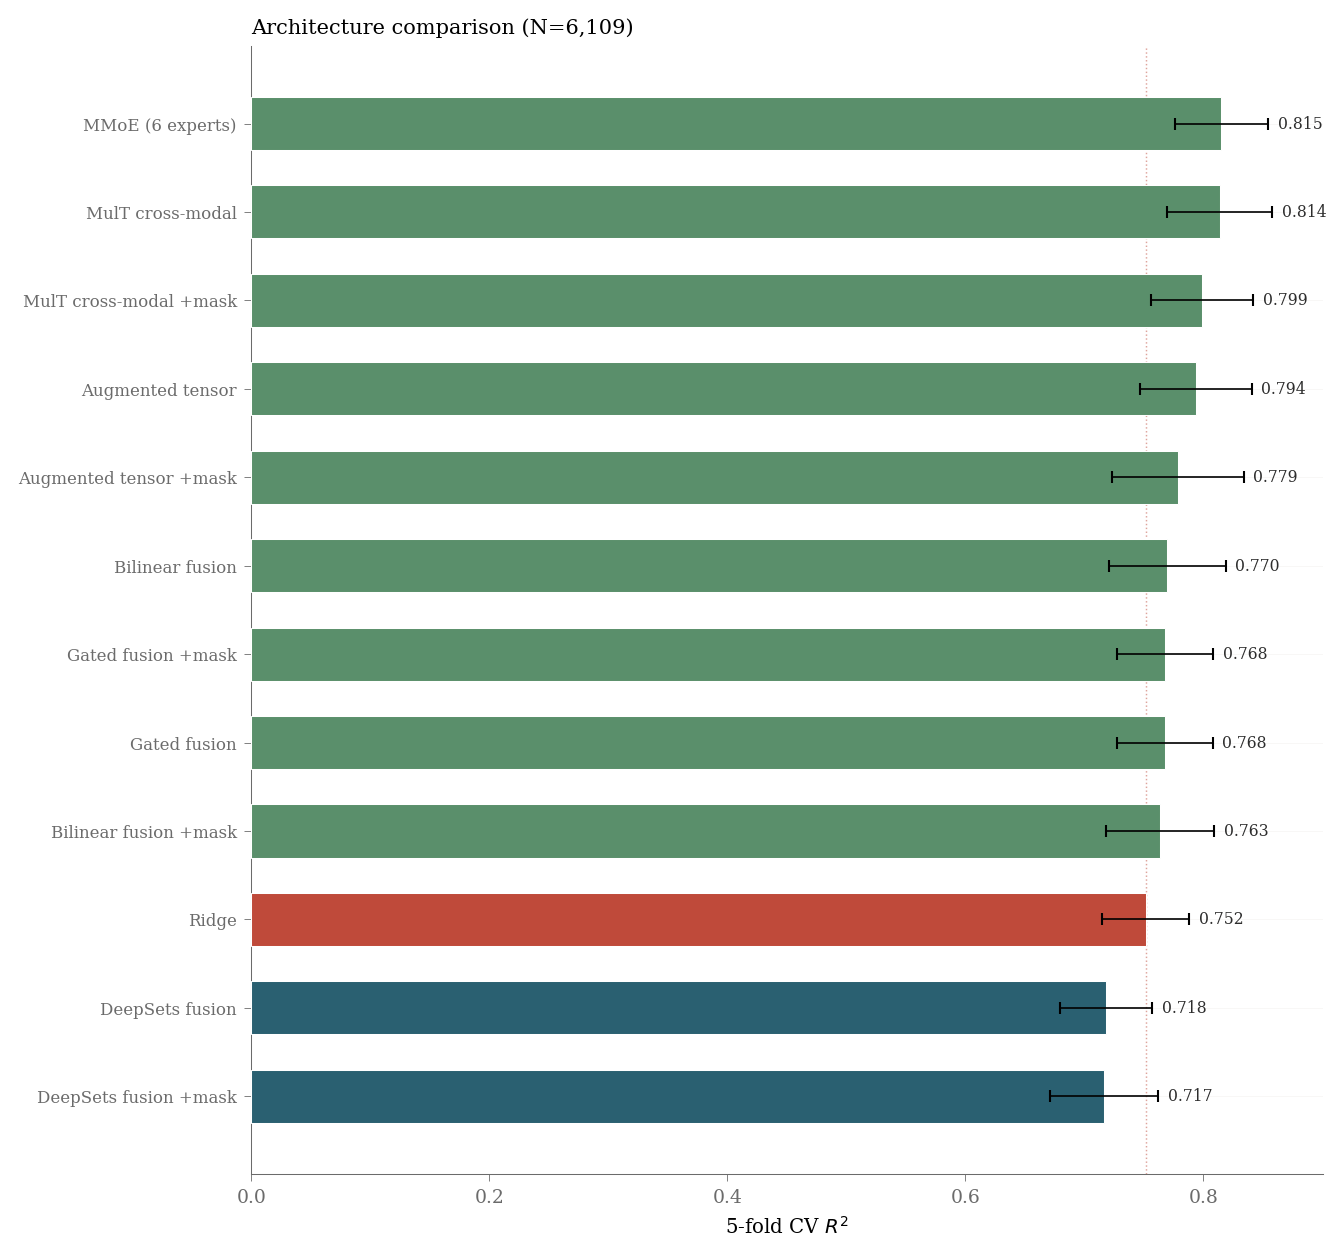

  saved: architecture_comparison.png


In [9]:
print("=" * 60)
print("PYTORCH FUSION ARCHITECTURES")
print("=" * 60)

def safe_heads(hidden, n_heads):
    while hidden % n_heads != 0 and n_heads > 1:
        n_heads //= 2
    return max(n_heads, 1)

class GatedFusion(nn.Module):
    def __init__(self, d_tab, d_mod, n_mods=4, hidden=64, dropout=0.2):
        super().__init__()
        self.mod_enc = nn.ModuleList([
            nn.Sequential(nn.Linear(d_mod, hidden), nn.GELU(), nn.Dropout(dropout))
            for _ in range(n_mods)])
        self.tab_enc = nn.Sequential(nn.Linear(d_tab, hidden), nn.GELU(), nn.Dropout(dropout))
        # vector gate: per-dimension weighting, not just scalar per modality
        self.gate = nn.Sequential(
            nn.Linear(d_tab + n_mods * d_mod, n_mods * hidden), nn.Sigmoid())
        self.n_mods = n_mods
        self.hidden = hidden
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, 1))

    def forward(self, x_tab, x_mods):
        tab_h = self.tab_enc(x_tab)
        mod_h = torch.stack([enc(x) for enc, x in zip(self.mod_enc, x_mods)], dim=1)
        gate_input = torch.cat([x_tab] + x_mods, dim=1)
        gates = self.gate(gate_input).view(-1, self.n_mods, self.hidden)
        fused = (mod_h * gates).mean(dim=1)
        return self.head(torch.cat([tab_h, fused], dim=1)).squeeze(-1)

class CrossModalAttention(nn.Module):
    def __init__(self, d_tab, d_mod, n_heads=4, hidden=64, dropout=0.2):
        super().__init__()
        n_heads = safe_heads(hidden, n_heads)
        self.n_heads, self.d_k = n_heads, hidden // n_heads
        self.proj = nn.ModuleDict({k: nn.Linear(d_mod * 2, hidden)
            for k in ['q_s', 'k_o', 'v_o', 'q_o', 'k_s', 'v_s']})
        self.tab_enc = nn.Sequential(nn.Linear(d_tab, hidden), nn.GELU(), nn.Dropout(dropout))
        self.head = nn.Sequential(nn.Linear(hidden*3, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1))

    def attend(self, Q, K, V):
        b = Q.size(0)
        Q = Q.view(b, self.n_heads, self.d_k)
        K = K.view(b, self.n_heads, self.d_k)
        V = V.view(b, self.n_heads, self.d_k)
        scores = torch.einsum('bnd,bnd->bn', Q, K) / (self.d_k ** 0.5)
        attn = torch.softmax(scores, dim=-1)
        return torch.einsum('bn,bnd->bd', attn, V).reshape(b, -1)

    def forward(self, x_tab, x_strat, x_obj):
        tab_h = self.tab_enc(x_tab)
        s2o = self.attend(self.proj['q_s'](x_strat), self.proj['k_o'](x_obj), self.proj['v_o'](x_obj))
        o2s = self.attend(self.proj['q_o'](x_obj), self.proj['k_s'](x_strat), self.proj['v_s'](x_strat))
        return self.head(torch.cat([tab_h, s2o, o2s], dim=1)).squeeze(-1)

class BilinearFusion(nn.Module):
    def __init__(self, d_tab, d_strat, d_obj, rank=16, hidden=64, dropout=0.2):
        super().__init__()
        self.U = nn.Linear(d_strat, rank, bias=False)
        self.V = nn.Linear(d_obj, rank, bias=False)
        self.tab_enc = nn.Sequential(nn.Linear(d_tab, hidden), nn.GELU(), nn.Dropout(dropout))
        self.strat_enc = nn.Sequential(nn.Linear(d_strat, hidden), nn.GELU(), nn.Dropout(dropout))
        self.obj_enc = nn.Sequential(nn.Linear(d_obj, hidden), nn.GELU(), nn.Dropout(dropout))
        self.head = nn.Sequential(nn.Linear(hidden*3+rank, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x_tab, x_strat, x_obj):
        bilinear = self.U(x_strat) * self.V(x_obj)
        return self.head(torch.cat([
            self.tab_enc(x_tab), self.strat_enc(x_strat),
            self.obj_enc(x_obj), bilinear], dim=1)).squeeze(-1)

class AugmentedTensorFusion(nn.Module):
    """Zadeh et al 2017: append 1 before outer product to capture main + interaction effects."""
    def __init__(self, d_tab, d_strat, d_obj, proj_dim=16, hidden=64, dropout=0.2):
        super().__init__()
        self.proj_s = nn.Linear(d_strat, proj_dim)
        self.proj_o = nn.Linear(d_obj, proj_dim)
        self.tab_enc = nn.Sequential(nn.Linear(d_tab, hidden), nn.GELU(), nn.Dropout(dropout))
        # augmented: (proj_dim+1)^2 from outer product of [proj; 1] vectors
        aug_dim = (proj_dim + 1) ** 2
        self.head = nn.Sequential(nn.Linear(hidden + aug_dim, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.proj_dim = proj_dim

    def forward(self, x_tab, x_strat, x_obj):
        s = torch.relu(self.proj_s(x_strat))
        o = torch.relu(self.proj_o(x_obj))
        # append 1 for augmented outer product (captures unimodal + bimodal + bias)
        ones = torch.ones(s.size(0), 1, device=s.device)
        s_aug = torch.cat([s, ones], dim=1)
        o_aug = torch.cat([o, ones], dim=1)
        outer = torch.einsum('bi,bj->bij', s_aug, o_aug).reshape(s.size(0), -1)
        tab_h = self.tab_enc(x_tab)
        return self.head(torch.cat([tab_h, outer], dim=1)).squeeze(-1)

class MulTInspired(nn.Module):
    """Transformer over modality tokens (tab + 4 CLIP modalities).
    Uses self-attention so every modality can attend to every other.
    Inspired by Tsai et al 2019 but simplified: they use pairwise
    directional streams, we use shared self-attention with residuals.
    Stores attention weights when extract_attn=True."""
    def __init__(self, d_tab, d_mod, n_mods=4, hidden=64, n_layers=2, dropout=0.2, n_heads=4):
        super().__init__()
        n_heads = safe_heads(hidden, n_heads)
        self.projections = nn.ModuleList([nn.Linear(d_mod, hidden) for _ in range(n_mods)])
        self.tab_proj = nn.Linear(d_tab, hidden)
        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(hidden, num_heads=n_heads,
                    dropout=dropout, batch_first=True),
                'norm1': nn.LayerNorm(hidden),
                'ff': nn.Sequential(nn.Linear(hidden, hidden*2), nn.GELU(),
                    nn.Dropout(dropout), nn.Linear(hidden*2, hidden)),
                'norm2': nn.LayerNorm(hidden),
            }))
        self.head = nn.Sequential(nn.Linear(hidden*(n_mods+1), hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.extract_attn = False
        self.last_attn_weights = None

    def forward(self, x_tab, x_mods):
        tokens = [self.tab_proj(x_tab)]
        for proj, x in zip(self.projections, x_mods):
            tokens.append(proj(x))
        seq = torch.stack(tokens, dim=1)
        for layer in self.layers:
            if self.extract_attn:
                attended, attn_w = layer['attn'](seq, seq, seq, need_weights=True)
                self.last_attn_weights = attn_w.detach()
            else:
                attended, _ = layer['attn'](seq, seq, seq)
            seq = layer['norm1'](seq + attended)
            seq = layer['norm2'](seq + layer['ff'](seq))
        return self.head(seq.reshape(seq.size(0), -1)).squeeze(-1)

class MMoE(nn.Module):
    """Mixture of experts with per-sample gating. Stores gate weights for analysis."""
    def __init__(self, d_in, n_experts=4, hidden=32, dropout=0.2):
        super().__init__()
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(d_in, hidden), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(hidden, hidden//2), nn.GELU(), nn.Linear(hidden//2, 1))
            for _ in range(n_experts)])
        self.gate = nn.Sequential(nn.Linear(d_in, n_experts), nn.Softmax(dim=-1))
        self.last_gate_weights = None

    def forward(self, x):
        outs = torch.stack([e(x).squeeze(-1) for e in self.experts], dim=1)
        gw = self.gate(x)
        self.last_gate_weights = gw.detach()
        return (outs * gw).sum(dim=1)

class DeepSetsFusion(nn.Module):
    """Shared encoder across modalities, mean pool within groups, then cross-group interaction."""
    def __init__(self, d_tab, d_mod, hidden=64, dropout=0.2):
        super().__init__()
        self.shared_enc = nn.Sequential(nn.Linear(d_mod, hidden), nn.GELU(), nn.Dropout(dropout))
        self.tab_enc = nn.Sequential(nn.Linear(d_tab, hidden), nn.GELU(), nn.Dropout(dropout))
        # bilinear cross-group interaction
        self.U = nn.Linear(hidden, hidden // 2, bias=False)
        self.V = nn.Linear(hidden, hidden // 2, bias=False)
        self.head = nn.Sequential(nn.Linear(hidden + hidden*2 + hidden//2, hidden),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x_tab, x_mods):
        # encode all 4 modalities with shared weights
        encoded = [self.shared_enc(x) for x in x_mods]
        # mean pool within strategic (text, photos) and objective (gsv, sat) groups
        strat_pool = (encoded[0] + encoded[1]) / 2
        obj_pool = (encoded[2] + encoded[3]) / 2
        cross = self.U(strat_pool) * self.V(obj_pool)
        tab_h = self.tab_enc(x_tab)
        return self.head(torch.cat([tab_h, strat_pool, obj_pool, cross], dim=1)).squeeze(-1)

# training
def train_eval(model, X_tr, y_tr, X_te, y_te, input_type,
               lr=1e-3, wd=1e-4, mask_prob=0.0):
    """Train and evaluate one fold. Returns R2 or nan on failure."""
    try:
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
        loss_fn = nn.MSELoss()
        n_tr = len(X_tr[0]) if isinstance(X_tr, list) else len(X_tr)
        best_loss, best_state, wait = float('inf'), None, 0

        for epoch in range(cfg.epochs):
            model.train()
            perm = np.random.permutation(n_tr)
            for start in range(0, n_tr, cfg.batch):
                idx = perm[start:start+cfg.batch]
                if input_type == '4mod':
                    inputs = [torch.tensor(X_tr[k][idx], dtype=torch.float32).to(device) for k in range(5)]
                    # modality masking: zero out each modality independently
                    if mask_prob > 0:
                        for k in range(1, 5):  # skip tabular
                            mask = (torch.rand(len(idx), 1, device=device) > mask_prob).float()
                            inputs[k] = inputs[k] * mask
                    pred = model(inputs[0], inputs[1:])
                elif input_type == '2grp':
                    t = torch.tensor(X_tr[0][idx], dtype=torch.float32).to(device)
                    s = torch.tensor(X_tr[1][idx], dtype=torch.float32).to(device)
                    o = torch.tensor(X_tr[2][idx], dtype=torch.float32).to(device)
                    if mask_prob > 0:
                        s = s * (torch.rand(len(idx), 1, device=device) > mask_prob).float()
                        o = o * (torch.rand(len(idx), 1, device=device) > mask_prob).float()
                    pred = model(t, s, o)
                else:
                    x = torch.tensor(X_tr[idx], dtype=torch.float32).to(device)
                    pred = model(x)

                y_b = torch.tensor(y_tr[idx], dtype=torch.float32).to(device)
                loss = loss_fn(pred, y_b)
                if torch.isnan(loss): return float('nan')
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sched.step()

            # val
            model.eval()
            with torch.no_grad():
                if input_type == '4mod':
                    inputs = [torch.tensor(X_te[k], dtype=torch.float32).to(device) for k in range(5)]
                    vp = model(inputs[0], inputs[1:])
                elif input_type == '2grp':
                    vp = model(torch.tensor(X_te[0], dtype=torch.float32).to(device),
                               torch.tensor(X_te[1], dtype=torch.float32).to(device),
                               torch.tensor(X_te[2], dtype=torch.float32).to(device))
                else:
                    vp = model(torch.tensor(X_te, dtype=torch.float32).to(device))
                if torch.isnan(vp).any(): return float('nan')
                vl = loss_fn(vp, torch.tensor(y_te, dtype=torch.float32).to(device)).item()
            if np.isnan(vl): return float('nan')
            if vl < best_loss:
                best_loss = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= cfg.patience: break

        if best_state is None: return float('nan')
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            if input_type == '4mod':
                inputs = [torch.tensor(X_te[k], dtype=torch.float32).to(device) for k in range(5)]
                p = model(inputs[0], inputs[1:])
            elif input_type == '2grp':
                p = model(torch.tensor(X_te[0], dtype=torch.float32).to(device),
                           torch.tensor(X_te[1], dtype=torch.float32).to(device),
                           torch.tensor(X_te[2], dtype=torch.float32).to(device))
            else:
                p = model(torch.tensor(X_te, dtype=torch.float32).to(device))
            return r2_score(y_te, p.cpu().numpy())
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return float('nan')
    except Exception:
        return float('nan')

def run_cv(name, make_fn, data, input_type, mask_prob=0.0):
    """5-fold CV for a PyTorch model."""
    kf = KFold(cfg.folds, shuffle=True, random_state=cfg.seed)
    scores = []
    for fold, (tr, te) in enumerate(kf.split(ylp)):
        model = make_fn().to(device)
        if input_type in ('4mod', '2grp'):
            X_tr = [d[tr] for d in data]
            X_te = [d[te] for d in data]
        else:
            X_tr, X_te = data[tr], data[te]
        s = train_eval(model, X_tr, ylp[tr], X_te, ylp[te], input_type, mask_prob=mask_prob)
        scores.append(s)
    valid = [s for s in scores if not np.isnan(s)]
    r2 = np.mean(valid) if valid else float('nan')
    std = np.std(valid) if valid else 0
    fold_str = ' '.join(f'{s:.3f}' if not np.isnan(s) else 'nan' for s in scores)
    n_params = sum(p.numel() for p in make_fn().parameters())
    print(f"  {name:<24s} {n_params:>8,d}p  R2={r2:.4f} +/- {std:.4f}  [{fold_str}]")
    return {'name': name, 'r2': r2, 'std': std, 'scores': scores, 'params': n_params}

data_4mod = [X_tab, X_text, X_photo, X_gsv, X_sat]
data_2grp = [X_tab, X_strat, X_obj]

# Ridge + MLP baselines
ridge_r2, ridge_std = cv_r2(X_all, ylp)
print(f"\n  {'Ridge baseline':<24s} {d_all+1:>8d}p  R2={ridge_r2:.4f} +/- {ridge_std:.4f}")

mlp_r2_scores = []
for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(X_all):
    ml = MLPRegressor(hidden_layer_sizes=(64,), alpha=0.1, max_iter=2000,
        early_stopping=True, validation_fraction=0.15, random_state=cfg.seed, learning_rate='adaptive')
    ml.fit(X_all[tr], ylp[tr])
    mlp_r2_scores.append(r2_score(ylp[te], ml.predict(X_all[te])))
print(f"  {'sklearn MLP(64)':<24s} {8385:>8d}p  R2={np.mean(mlp_r2_scores):.4f} +/- {np.std(mlp_r2_scores):.4f}")

print(f"\nPyTorch architectures (default hyperparameters):")
arch_results = []

archs = [
    ('Gated fusion', lambda: GatedFusion(d_tab, d_mod, 4, 64, 0.2), data_4mod, '4mod'),
    ('Cross-modal attn', lambda: CrossModalAttention(d_tab, d_mod, 4, 64, 0.2), data_2grp, '2grp'),
    ('Bilinear fusion', lambda: BilinearFusion(d_tab, d_strat, d_obj, 16, 64, 0.2), data_2grp, '2grp'),
    ('Augmented tensor', lambda: AugmentedTensorFusion(d_tab, d_strat, d_obj, 16, 64, 0.2), data_2grp, '2grp'),
    ('MulT cross-modal', lambda: MulTInspired(d_tab, d_mod, 4, 64, 2, 0.2, 4), data_4mod, '4mod'),
    ('MMoE (6 experts)', lambda: MMoE(d_all, 6, 48, 0.2), X_all, 'flat'),
    ('DeepSets fusion', lambda: DeepSetsFusion(d_tab, d_mod, 64, 0.2), data_4mod, '4mod'),
]

for name, make_fn, data, itype in archs:
    res = run_cv(name, make_fn, data, itype)
    arch_results.append(res)

# with modality masking
print(f"\nwith modality masking (p={cfg.mask_prob}):")
arch_results_masked = []
for name, make_fn, data, itype in archs:
    if itype == 'flat': continue  # masking doesn't apply to flat input
    res = run_cv(f"{name} +mask", make_fn, data, itype, mask_prob=cfg.mask_prob)
    arch_results_masked.append(res)

# summary
all_arch = [{'name': 'Ridge', 'r2': ridge_r2, 'std': ridge_std, 'params': d_all+1}]
all_arch += arch_results
all_arch += arch_results_masked
all_arch.sort(key=lambda x: x['r2'] if not np.isnan(x['r2']) else -999, reverse=True)

print(f"\nranking:")
for i, a in enumerate(all_arch):
    beats = " << BEATS RIDGE" if (not np.isnan(a['r2']) and a['r2'] > ridge_r2 and a['name'] != 'Ridge') else ""
    print(f"  {i+1}. {a['name']:<28s} R2={a['r2']:.4f}{beats}")

best_neural = max((a for a in all_arch if a['name'] != 'Ridge' and not np.isnan(a['r2'])),
    key=lambda x: x['r2'], default=None)
if best_neural:
    print(f"\nbest neural: {best_neural['name']} (R2={best_neural['r2']:.4f}, "
          f"vs Ridge {best_neural['r2']-ridge_r2:+.4f})")

# figure
valid_arch = [a for a in all_arch if not np.isnan(a['r2'])]
fig, ax = plt.subplots(figsize=(9, max(3, len(valid_arch)*0.7)))
names_plot = [a['name'] for a in valid_arch]
r2s = [a['r2'] for a in valid_arch]
stds = [a['std'] for a in valid_arch]
colors = []
for a in valid_arch:
    if a['name'] == 'Ridge': colors.append(PAL['strat'])
    elif a['r2'] > ridge_r2: colors.append(PAL['green'])
    else: colors.append(PAL['obj'])
ax.barh(range(len(names_plot)), r2s, xerr=stds, color=colors, edgecolor='white',
    lw=0.5, height=0.6, capsize=3, error_kw={'lw': 0.8}, zorder=3)
ax.set_yticks(range(len(names_plot)))
ax.set_yticklabels(names_plot, fontsize=8)
ax.set_xlabel('5-fold CV $R^2$')
ax.set_title(f'Architecture comparison (N={n_obs:,d})', loc='left', fontsize=10, fontweight='medium')
ax.axvline(ridge_r2, color=PAL['strat'], lw=0.7, ls=':', alpha=0.5)
for i, v in enumerate(r2s):
    ax.text(max(v+stds[i]+0.008, 0.02), i, f'{v:.3f}', va='center', fontsize=7.5, color=PAL['dark'])
hgrid(ax); ax.invert_yaxis()
ax.set_xlim(left=min(0, min(r2s)-0.05))
plt.tight_layout()
savefig('architecture_comparison.png')


## Interpretability
MulT attention weights (aligned vs misaligned), gradient modality importance by quartile, counterfactual ablation, MMoE expert specialization, gated fusion weight analysis.

INTERPRETABILITY

MulT attention weights:
  aligned (n=611):
    Tab -> [0.077  0.298  0.410  0.099  0.115]
    Text -> [0.146  0.279  0.089  0.312  0.173]
    Photos -> [0.204  0.289  0.067  0.127  0.312]
    GSV -> [0.118  0.273  0.357  0.128  0.124]
    Sat -> [0.080  0.318  0.435  0.105  0.062]
  misaligned (n=610):
    Tab -> [0.086  0.263  0.435  0.092  0.124]
    Text -> [0.163  0.284  0.095  0.298  0.161]
    Photos -> [0.192  0.287  0.067  0.135  0.319]
    GSV -> [0.135  0.278  0.337  0.128  0.122]
    Sat -> [0.091  0.286  0.454  0.109  0.060]


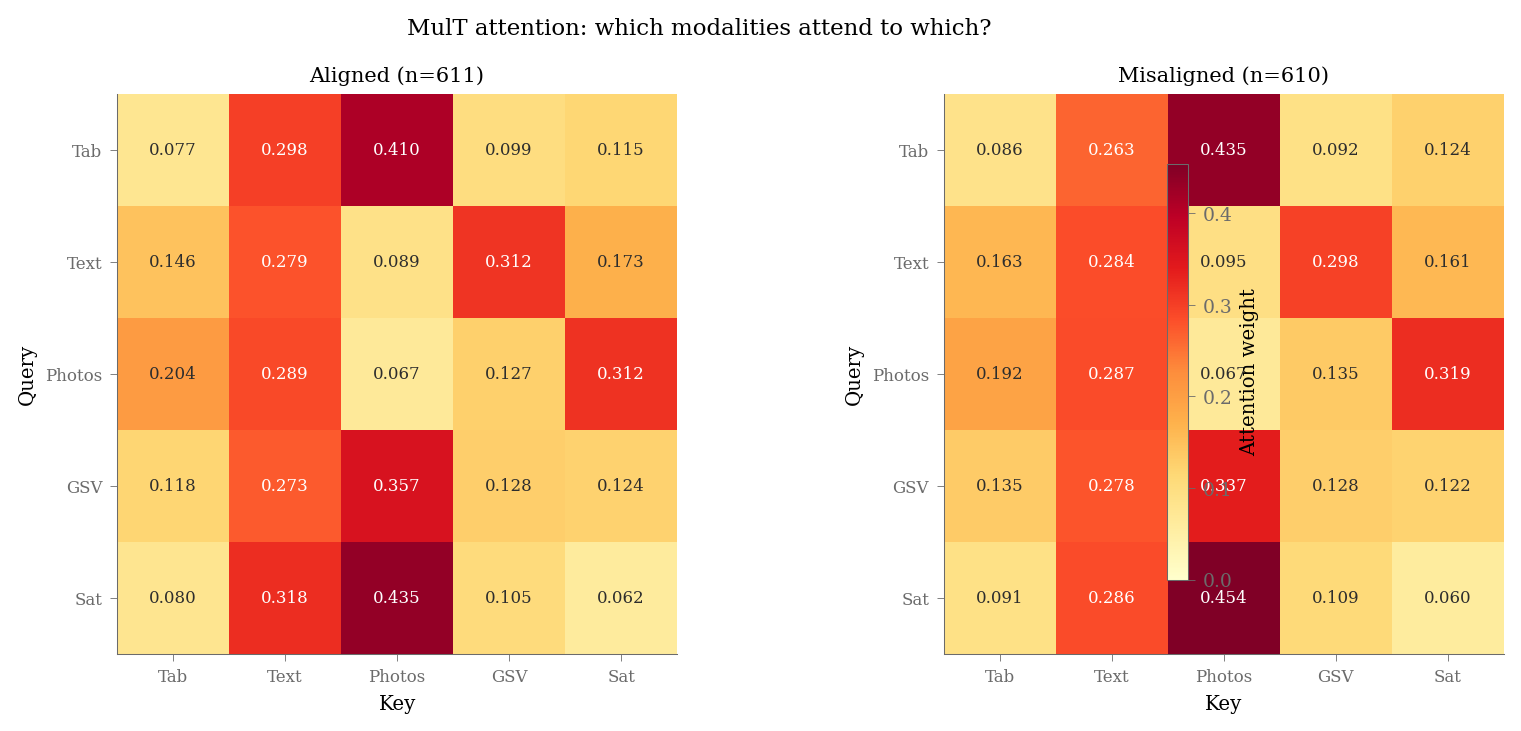

  saved: attention_heatmaps.png

gradient modality importance:
  quartile         Tab      Text    Photos       GSV       Sat
  Q1            0.3344    1.2989    2.0477    0.9238    1.2618
  Q2            0.3367    0.9667    2.0172    0.8708    1.1474
  Q3            0.3466    0.9982    2.2424    0.9262    1.2104
  Q4            0.3848    1.1326    2.4061    1.0179    1.3179


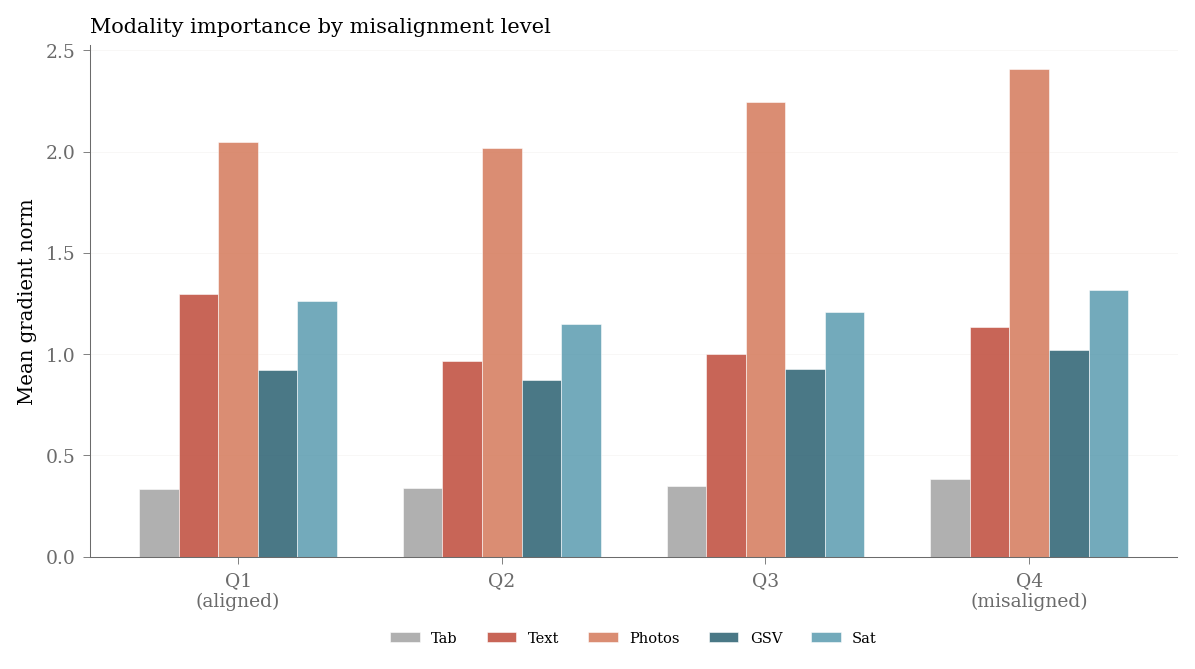

  saved: gradient_importance.png

counterfactual modality ablation:
  strategic removal shift: aligned=-0.0727  misaligned=0.0932
  (if model trusts strategic less for misaligned, the misaligned shift should be smaller)
  t-test p=0.0000

MMoE expert specialization:
  expert characterization:
    expert 0: n=579, primary type=SINGLE_FAMILY, mean delta=0.135, mean price=$1,648,722
    expert 1: n=79, primary type=CONDO, mean delta=0.218, mean price=$1,368,034
    expert 2: n=561, primary type=CONDO, mean delta=0.178, mean price=$954,925

gated fusion gate weights:
  Text gate weight vs misalignment: r=0.1069 p=0.0002
  Photos gate weight vs misalignment: r=0.2308 p=0.0000
  GSV gate weight vs misalignment: r=0.0698 p=0.0147
  Sat gate weight vs misalignment: r=0.0992 p=0.0005


In [10]:
print("=" * 60)
print("INTERPRETABILITY")
print("=" * 60)

# retrain MulT on one fold with attention extraction
print("\nMulT attention weights:")
try:
    kf = KFold(cfg.folds, shuffle=True, random_state=cfg.seed)
    tr_idx, te_idx = list(kf.split(ylp))[-1]  # use last fold
    mult_model = MulTInspired(d_tab, d_mod, 4, 64, 2, 0.2, 4).to(device)
    X_tr_4 = [d[tr_idx] for d in data_4mod]
    X_te_4 = [d[te_idx] for d in data_4mod]
    train_eval(mult_model, X_tr_4, ylp[tr_idx], X_te_4, ylp[te_idx], '4mod')

    mult_model.eval()
    mult_model.extract_attn = True
    with torch.no_grad():
        inputs = [torch.tensor(X_te_4[k], dtype=torch.float32).to(device) for k in range(5)]
        _ = mult_model(inputs[0], inputs[1:])
        attn_w = mult_model.last_attn_weights.cpu().numpy()  # (n_test, n_heads, 5, 5)

    # average across heads
    if attn_w.ndim == 4:
        attn_avg = attn_w.mean(axis=1)  # (n_test, 5, 5)
    else:
        attn_avg = attn_w  # (n_test, 5, 5)

    # split by misalignment level
    qm_test = qm[cidx[te_idx]]
    qm_valid_test = np.isfinite(qm_test)
    if qm_valid_test.sum() > 20:
        med_test = np.nanmedian(qm_test)
        lo_mask = qm_valid_test & (qm_test <= med_test)
        hi_mask = qm_valid_test & (qm_test > med_test)

        attn_lo = attn_avg[lo_mask].mean(axis=0) if lo_mask.sum() > 5 else np.zeros((5,5))
        attn_hi = attn_avg[hi_mask].mean(axis=0) if hi_mask.sum() > 5 else np.zeros((5,5))

        mod_labels = ['Tab', 'Text', 'Photos', 'GSV', 'Sat']
        print(f"  aligned (n={lo_mask.sum()}):")
        for i, qi in enumerate(mod_labels):
            vals = '  '.join(f'{attn_lo[i,j]:.3f}' for j in range(5))
            print(f"    {qi} -> [{vals}]")
        print(f"  misaligned (n={hi_mask.sum()}):")
        for i, qi in enumerate(mod_labels):
            vals = '  '.join(f'{attn_hi[i,j]:.3f}' for j in range(5))
            print(f"    {qi} -> [{vals}]")

        # figure: side by side heatmaps
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        for ax, mat, title in [(axes[0], attn_lo, f'Aligned (n={lo_mask.sum()})'),
                                (axes[1], attn_hi, f'Misaligned (n={hi_mask.sum()})')]:
            im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=max(attn_lo.max(), attn_hi.max()),
                aspect='equal')
            for i in range(5):
                for j in range(5):
                    ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=8,
                        color='white' if mat[i,j] > 0.25 else PAL['dark'])
            ax.set_xticks(range(5)); ax.set_yticks(range(5))
            ax.set_xticklabels(mod_labels, fontsize=8); ax.set_yticklabels(mod_labels, fontsize=8)
            ax.set_xlabel('Key'); ax.set_ylabel('Query')
            ax.set_title(title, fontsize=10, fontweight='medium')
        plt.colorbar(im, ax=axes, shrink=0.8, label='Attention weight')
        plt.suptitle('MulT attention: which modalities attend to which?', fontsize=11, fontweight='medium', y=1.02)
        plt.tight_layout()
        savefig('attention_heatmaps.png')
except Exception as e:
    print(f"  MulT attention failed: {e}")

# gradient-based modality importance
print("\ngradient modality importance:")
try:
    mult_model.extract_attn = False
    mult_model.eval()
    qm_test = qm[cidx[te_idx]]
    qe_test = np.nanpercentile(qm_test[np.isfinite(qm_test)], [25, 50, 75])
    qbins_test = np.digitize(qm_test, qe_test)

    grad_norms = {q: {m: [] for m in ['Tab', 'Text', 'Photos', 'GSV', 'Sat']}
                  for q in range(4)}

    for i in range(len(te_idx)):
        if not np.isfinite(qm_test[i]): continue
        qi = qbins_test[i]
        inputs = [torch.tensor(X_te_4[k][i:i+1], dtype=torch.float32).to(device).requires_grad_(True)
                  for k in range(5)]
        pred = mult_model(inputs[0], inputs[1:])
        pred.backward()
        for mi, mname in enumerate(['Tab', 'Text', 'Photos', 'GSV', 'Sat']):
            gn = inputs[mi].grad.norm().item()
            grad_norms[qi][mname].append(gn)

    print(f"  {'quartile':<10s}", end='')
    for m in ['Tab', 'Text', 'Photos', 'GSV', 'Sat']:
        print(f"  {m:>8s}", end='')
    print()
    for qi in range(4):
        print(f"  Q{qi+1:<9d}", end='')
        for m in ['Tab', 'Text', 'Photos', 'GSV', 'Sat']:
            v = np.mean(grad_norms[qi][m]) if grad_norms[qi][m] else 0
            print(f"  {v:>8.4f}", end='')
        print()

    # gradient importance figure
    fig, ax = plt.subplots(figsize=(8, 4.5))
    mods_g = ['Tab', 'Text', 'Photos', 'GSV', 'Sat']
    x = np.arange(4)
    w = 0.15
    colors_g = [PAL['light'], PAL['strat'], PAL['strat_l'], PAL['obj'], PAL['obj_l']]
    for mi, (mname, col) in enumerate(zip(mods_g, colors_g)):
        vals = [np.mean(grad_norms[q][mname]) if grad_norms[q][mname] else 0 for q in range(4)]
        ax.bar(x + mi*w, vals, w, label=mname, color=col, edgecolor='white', lw=0.3, alpha=0.85)
    ax.set_xticks(x + w*2)
    ax.set_xticklabels(['Q1\n(aligned)', 'Q2', 'Q3', 'Q4\n(misaligned)'])
    ax.set_ylabel('Mean gradient norm')
    ax.set_title('Modality importance by misalignment level', loc='left', fontsize=10, fontweight='medium')
    ax.legend(fontsize=7, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.12))
    hgrid(ax); plt.tight_layout()
    savefig('gradient_importance.png')
except Exception as e:
    print(f"  gradient analysis failed: {e}")

# counterfactual ablation
print("\ncounterfactual modality ablation:")
try:
    mult_model.eval()
    shifts_strat, shifts_obj = [], []
    qm_test_vals = qm[cidx[te_idx]]
    for i in range(len(te_idx)):
        if not np.isfinite(qm_test_vals[i]): continue
        with torch.no_grad():
            inputs_full = [torch.tensor(X_te_4[k][i:i+1], dtype=torch.float32).to(device) for k in range(5)]
            y_full = mult_model(inputs_full[0], inputs_full[1:]).item()

            # zero strategic (text + photos)
            inputs_nos = [x.clone() for x in inputs_full]
            inputs_nos[1] = torch.zeros_like(inputs_nos[1])
            inputs_nos[2] = torch.zeros_like(inputs_nos[2])
            y_nos = mult_model(inputs_nos[0], inputs_nos[1:]).item()

            # zero objective (gsv + sat)
            inputs_noo = [x.clone() for x in inputs_full]
            inputs_noo[3] = torch.zeros_like(inputs_noo[3])
            inputs_noo[4] = torch.zeros_like(inputs_noo[4])
            y_noo = mult_model(inputs_noo[0], inputs_noo[1:]).item()

        shifts_strat.append((y_full - y_nos, qm_test_vals[i]))
        shifts_obj.append((y_full - y_noo, qm_test_vals[i]))

    shifts_strat = np.array(shifts_strat)
    shifts_obj = np.array(shifts_obj)
    med_abl = np.nanmedian(shifts_strat[:, 1])

    lo_shift = shifts_strat[shifts_strat[:, 1] <= med_abl, 0]
    hi_shift = shifts_strat[shifts_strat[:, 1] > med_abl, 0]
    print(f"  strategic removal shift: aligned={lo_shift.mean():.4f}  misaligned={hi_shift.mean():.4f}")
    print(f"  (if model trusts strategic less for misaligned, the misaligned shift should be smaller)")
    _, abl_p = stats.ttest_ind(lo_shift, hi_shift)
    print(f"  t-test p={abl_p:.4f}")
except Exception as e:
    print(f"  ablation failed: {e}")

# MMoE expert specialization
print("\nMMoE expert specialization:")
try:
    kf = KFold(cfg.folds, shuffle=True, random_state=cfg.seed)
    tr_idx_m, te_idx_m = list(kf.split(ylp))[-1]
    mmoe_model = MMoE(d_all, 6, 48, 0.2).to(device)
    train_eval(mmoe_model, X_all[tr_idx_m], ylp[tr_idx_m], X_all[te_idx_m], ylp[te_idx_m], 'flat')

    mmoe_model.eval()
    with torch.no_grad():
        _ = mmoe_model(torch.tensor(X_all[te_idx_m], dtype=torch.float32).to(device))
        gate_w = mmoe_model.last_gate_weights.cpu().numpy()

    # dominant expert per property
    dominant = gate_w.argmax(axis=1)
    test_df = df.iloc[cidx[te_idx_m]].copy()
    test_df['expert'] = dominant
    test_df['delta'] = qm[cidx[te_idx_m]]

    print(f"  expert characterization:")
    for exp in range(gate_w.shape[1]):
        mask_e = dominant == exp
        if mask_e.sum() < 5: continue
        sub = test_df[mask_e]
        top_type = sub['home_type'].mode().iloc[0] if len(sub) > 0 else 'n/a'
        mean_d = sub['delta'].mean() if sub['delta'].notna().any() else 0
        mean_p = sub['price'].mean()
        print(f"    expert {exp}: n={mask_e.sum()}, primary type={top_type}, "
              f"mean delta={mean_d:.3f}, mean price=${mean_p:,.0f}")
except Exception as e:
    print(f"  MMoE analysis failed: {e}")

# gated fusion weights
print("\ngated fusion gate weights:")
try:
    kf = KFold(cfg.folds, shuffle=True, random_state=cfg.seed)
    tr_idx_g, te_idx_g = list(kf.split(ylp))[-1]
    gated_model = GatedFusion(d_tab, d_mod, 4, 64, 0.2).to(device)
    X_tr_g = [d[tr_idx_g] for d in data_4mod]
    X_te_g = [d[te_idx_g] for d in data_4mod]
    train_eval(gated_model, X_tr_g, ylp[tr_idx_g], X_te_g, ylp[te_idx_g], '4mod')

    gated_model.eval()
    with torch.no_grad():
        inputs_g = [torch.tensor(X_te_g[k], dtype=torch.float32).to(device) for k in range(5)]
        _ = gated_model(inputs_g[0], inputs_g[1:])
        # gate output is (batch, n_mods * hidden), reshape and average across hidden
        gate_raw = gated_model.gate(torch.cat([inputs_g[0]] + inputs_g[1:], dim=1))
        gate_per_mod = gate_raw.view(-1, 4, 64).mean(dim=2).cpu().numpy()

    qm_gate_test = qm[cidx[te_idx_g]]
    valid_gt = np.isfinite(qm_gate_test)
    if valid_gt.sum() > 20:
        for mi, mname in enumerate(['Text', 'Photos', 'GSV', 'Sat']):
            r_g, p_g = stats.pearsonr(gate_per_mod[valid_gt, mi], qm_gate_test[valid_gt])
            print(f"  {mname} gate weight vs misalignment: r={r_g:.4f} p={p_g:.4f}")
except Exception as e:
    print(f"  gated analysis failed: {e}")


## Contrastive misalignment and learned calibration
InfoNCE contrastive score (128d embedding space), MLP calibrated quality scores per modality. Four-way comparison: hand-crafted vs learned Ridge vs calibrated MLP vs contrastive.

CONTRASTIVE MISALIGNMENT + LEARNED CALIBRATION

contrastive misalignment:
  contrastive vs price gap: r=0.0031 p=0.9164
  hand-crafted vs price gap: r=0.0933
  contrastive vs hand-crafted: r=-0.1798

learned MLP calibration:
  text: calibration R2=0.2723
  photos: calibration R2=0.2725
  gsv: calibration R2=0.2254
  sat: calibration R2=0.2488

  calibrated delta vs price gap: r=-0.0419 p=0.0012
  hand-crafted delta vs price gap: r=0.0888


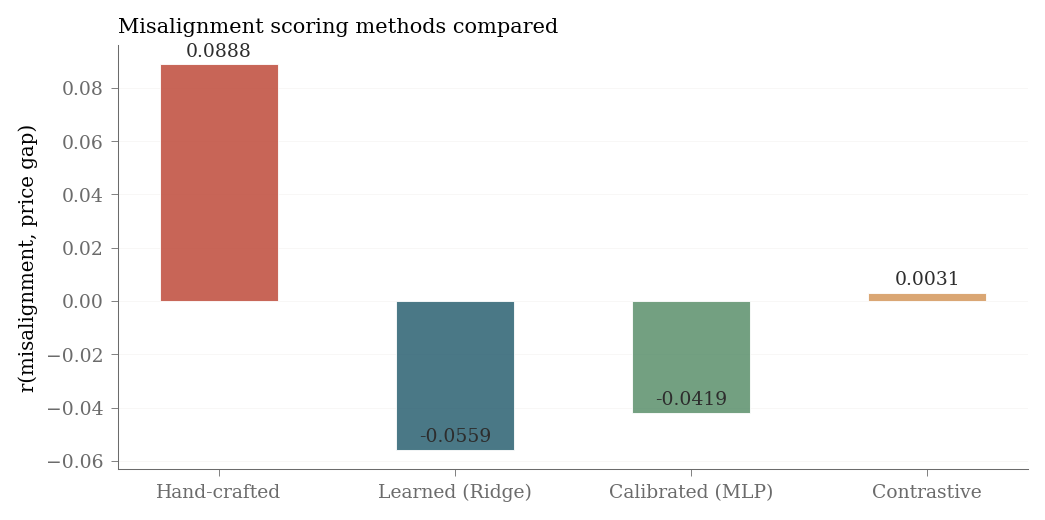

  saved: misalignment_methods.png


In [13]:
print("=" * 60)
print("CONTRASTIVE MISALIGNMENT + LEARNED CALIBRATION")
print("=" * 60)

# contrastive: learn whether strategic/objective pairing is "surprising"
print("\ncontrastive misalignment:")
try:
    class ContrastiveModel(nn.Module):
        def __init__(self, d_in, d_proj=128):
            super().__init__()
            self.proj_s = nn.Sequential(nn.Linear(d_in, 256), nn.GELU(), nn.Linear(256, d_proj))
            self.proj_o = nn.Sequential(nn.Linear(d_in, 256), nn.GELU(), nn.Linear(256, d_proj))
            self.tau = nn.Parameter(torch.tensor(0.07))

        def forward(self, x_s, x_o):
            z_s = self.proj_s(x_s)
            z_o = self.proj_o(x_o)
            z_s = z_s / z_s.norm(dim=-1, keepdim=True)
            z_o = z_o / z_o.norm(dim=-1, keepdim=True)
            return z_s, z_o

    cont_mask = complete & ~is_unsold.values
    cont_idx = np.where(cont_mask)[0]
    X_s_cont = np.hstack([pca_text[cont_idx], pca_photos[cont_idx]]).astype(np.float32)
    X_o_cont = np.hstack([pca_gsv[cont_idx], pca_sat[cont_idx]]).astype(np.float32)

    n_cont = len(cont_idx)
    tr_c = np.random.choice(n_cont, int(0.8 * n_cont), replace=False)
    te_c = np.array([i for i in range(n_cont) if i not in set(tr_c)])

    cm = ContrastiveModel(d_strat, 128).to(device)
    opt_c = optim.AdamW(cm.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(50):
        cm.train()
        perm = np.random.permutation(len(tr_c))
        for start in range(0, len(perm), 256):
            idx = perm[start:start+256]
            xs = torch.tensor(X_s_cont[tr_c[idx]], dtype=torch.float32).to(device)
            xo = torch.tensor(X_o_cont[tr_c[idx]], dtype=torch.float32).to(device)
            zs, zo = cm(xs, xo)
            logits = (zs @ zo.T) / cm.tau.abs()
            labels = torch.arange(len(idx), device=device)
            loss = nn.CrossEntropyLoss()(logits, labels)
            opt_c.zero_grad(); loss.backward(); opt_c.step()

    cm.eval()
    with torch.no_grad():
        xs_te = torch.tensor(X_s_cont[te_c], dtype=torch.float32).to(device)
        xo_te = torch.tensor(X_o_cont[te_c], dtype=torch.float32).to(device)
        zs_te, zo_te = cm(xs_te, xo_te)
        sims = (zs_te * zo_te).sum(dim=-1) / cm.tau.abs()
        all_sims = (zs_te @ zo_te.T) / cm.tau.abs()
        log_probs = sims - torch.logsumexp(all_sims, dim=1)
        contrastive_mis = -log_probs.cpu().numpy()

    test_global_idx = cont_idx[te_c]
    v_ct = np.isfinite(qm[test_global_idx]) & valid_pg[test_global_idx]
    if v_ct.sum() > 30:
        r_cont, p_cont = stats.pearsonr(
            contrastive_mis[v_ct[:len(contrastive_mis)]],
            df.iloc[test_global_idx[v_ct]]['price_gap'].values[:v_ct.sum()])
        r_hc_ct, _ = stats.pearsonr(
            qm[test_global_idx[v_ct]], df.iloc[test_global_idx[v_ct]]['price_gap'].values)
        r_between, _ = stats.pearsonr(
            contrastive_mis[np.isfinite(qm[test_global_idx])[:len(contrastive_mis)]],
            qm[test_global_idx][np.isfinite(qm[test_global_idx])][:len(contrastive_mis)])
        print(f"  contrastive vs price gap: r={r_cont:.4f} p={p_cont:.4f}")
        print(f"  hand-crafted vs price gap: r={r_hc_ct:.4f}")
        print(f"  contrastive vs hand-crafted: r={r_between:.4f}")
except Exception as e:
    print(f"  contrastive failed: {e}")
    traceback.print_exc()

# learned MLP calibration
print("\nlearned MLP calibration:")
try:
    class CalibMLP(nn.Module):
        def __init__(self, d_in):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(d_in, 256), nn.GELU(),
                nn.Dropout(0.2), nn.Linear(256, 1))
        def forward(self, x):
            return self.net(x).squeeze(-1)

    calib_scores = {}
    valid_cal = df['area_sqft'].notna().values & (df['area_sqft'] > 100).values & ~is_unsold.values
    y_ppsf = np.log(df['price'] / df['area_sqft'].clip(lower=100)).values.astype(np.float32)
    loc_valid = valid_cal & np.isfinite(y_ppsf)
    loc_idx = np.where(loc_valid)[0]
    y_resid_all = y_ppsf.copy()
    if len(loc_idx) > 50:
        y_resid_all[loc_idx] = y_ppsf[loc_idx] - Ridge(alpha=1).fit(
            TAB_s[loc_idx][:, [2,3]], y_ppsf[loc_idx]).predict(TAB_s[loc_idx][:, [2,3]])

    for mname, emb_m, has_m in [('text', emb_text, has_text), ('photos', emb_photos, has_photos),
                                  ('gsv', emb_gsv, has_gsv), ('sat', emb_sat, has_sat)]:
        vm = has_m & loc_valid
        idx_m = np.where(vm)[0]
        if len(idx_m) < 100: continue

        cal_pred = np.zeros(len(idx_m))
        for tr, te in KFold(cfg.folds, shuffle=True, random_state=cfg.seed).split(idx_m):
            net = CalibMLP(512).to(device)
            opt_n = optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-3)
            X_tr_n = torch.tensor(emb_m[idx_m[tr]], dtype=torch.float32).to(device)
            y_tr_n = torch.tensor(y_resid_all[idx_m[tr]], dtype=torch.float32).to(device)

            for epoch in range(100):
                net.train()
                perm = np.random.permutation(len(tr))
                for s in range(0, len(perm), 128):
                    bi = perm[s:s+128]
                    pred = net(X_tr_n[bi])
                    loss = nn.MSELoss()(pred, y_tr_n[bi])
                    opt_n.zero_grad(); loss.backward(); opt_n.step()

            net.eval()
            with torch.no_grad():
                X_te_n = torch.tensor(emb_m[idx_m[te]], dtype=torch.float32).to(device)
                cal_pred[te] = net(X_te_n).cpu().numpy()

        calib_scores[mname] = np.zeros(N)
        calib_scores[mname][idx_m] = cal_pred
        r2_cal = r2_score(y_resid_all[idx_m], cal_pred)
        print(f"  {mname}: calibration R2={r2_cal:.4f}")

    # compute calibrated misalignment
    if 'text' in calib_scores and 'gsv' in calib_scores:
        if 'photos' in calib_scores:
            cal_strat = np.where(has_text & has_photos,
                0.5 * (calib_scores['text'] + calib_scores['photos']),
                np.where(has_text, calib_scores['text'], np.nan))
        else:
            cal_strat = np.where(has_text, calib_scores['text'], np.nan)

        if 'sat' in calib_scores:
            cal_obj = np.where(has_gsv & has_sat,
                0.5 * (calib_scores['gsv'] + calib_scores['sat']),
                np.where(has_gsv, calib_scores['gsv'], np.nan))
        else:
            cal_obj = np.where(has_gsv, calib_scores['gsv'], np.nan)

        cal_mis = np.where(np.isfinite(cal_strat) & np.isfinite(cal_obj),
            cal_strat - cal_obj, np.nan)
        v_cal = np.isfinite(cal_mis) & valid_pg
        if v_cal.sum() > 30:
            r_cal, p_cal = stats.pearsonr(cal_mis[v_cal], df.loc[v_cal, 'price_gap'].values)
            v_hc = valid_qm & valid_pg
            r_hc2, _ = stats.pearsonr(qm[v_hc], df.loc[v_hc, 'price_gap'].values)
            print(f"\n  calibrated delta vs price gap: r={r_cal:.4f} p={p_cal:.4f}")
            print(f"  hand-crafted delta vs price gap: r={r_hc2:.4f}")

    # comparison figure
    methods = ['Hand-crafted']
    try:
        rs = [r_hc2]
    except NameError:
        v_hc_fb = valid_qm & valid_pg
        rs = [stats.pearsonr(qm[v_hc_fb], df.loc[v_hc_fb, 'price_gap'].values)[0] if v_hc_fb.sum() > 30 else 0]
    try:
        if not np.isnan(r_l):
            methods.append('Learned (Ridge)')
            rs.append(r_l)
    except NameError:
        pass
    try:
        methods.append('Calibrated (MLP)')
        rs.append(r_cal)
    except NameError:
        pass
    try:
        methods.append('Contrastive')
        rs.append(r_cont)
    except NameError:
        pass

    if len(methods) > 1:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        colors_m = [PAL['strat'], PAL['obj'], PAL['green'], PAL['accent']][:len(methods)]
        ax.bar(methods, rs, color=colors_m, edgecolor='white', lw=0.5, width=0.5, alpha=0.85)
        for i, v in enumerate(rs):
            ax.text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9, color=PAL['dark'])
        ax.set_ylabel('r(misalignment, price gap)')
        ax.set_title('Misalignment scoring methods compared', loc='left', fontsize=10, fontweight='medium')
        hgrid(ax); plt.tight_layout()
        savefig('misalignment_methods.png')

except Exception as e:
    print(f"  calibration failed: {e}")
    traceback.print_exc()

## Final summary

In [14]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\ndataset: N={N}, complete={complete.sum()}, valid_pg={valid_pg.sum()}")
print(f"cities: {df['city_group'].value_counts().to_dict()}")
print(f"types: {df['home_type'].value_counts().to_dict()}")

print(f"\ncore finding:")
print(f"  misalignment vs price gap: r={r_gap:.4f} p={p_gap:.4f}")
print(f"  logistic OR: {np.exp(logit.params['qm']):.4f}")
print(f"  bidding war ratio Q1/Q4: {ratio14:.1f}x")

print(f"\nfusion R2:")
print(f"  tabular={tab_r2:.4f}  late={np.mean(late_sc):.4f}  early={np.mean(early_sc):.4f}")
print(f"  early+delta={r2_aug:.4f}  (improvement={r2_aug-r2_base:+.4f})")

try:
    print(f"\nbest neural: {best_neural['name']} R2={best_neural['r2']:.4f} "
          f"(vs Ridge {best_neural['r2']-ridge_r2:+.4f})")
except NameError:
    print(f"\n(neural architectures not yet run)")

print(f"\nfigures generated:")
for f in sorted(FIGS.glob('*.png')):
    print(f"  {f.name}")
print(f"\ntotal: {len(list(FIGS.glob('*.png')))} figures")


FINAL SUMMARY

dataset: N=6893, complete=6109, valid_pg=6006
cities: {'Boston': 1300, 'Newton': 1005, 'Arlington': 981, 'Medford': 979, 'Cambridge': 977, 'Brookline': 965, 'Somerville': 680, 'Other': 6}
types: {'CONDO': 3324, 'SINGLE_FAMILY': 1999, 'MULTI_FAMILY': 771, 'TOWNHOUSE': 606, 'APARTMENT': 193}

core finding:
  misalignment vs price gap: r=0.0888 p=0.0000
  logistic OR: 0.4952
  bidding war ratio Q1/Q4: 1.6x

fusion R2:
  tabular=0.6241  late=0.5033  early=0.7516
  early+delta=0.7515  (improvement=-0.0001)

best neural: MMoE (6 experts) R2=0.8151 (vs Ridge +0.0635)

figures generated:
  alignment_distributions.png
  architecture_comparison.png
  attention_heatmaps.png
  bidding_wars.png
  cca_spectrum.png
  city_comparison.png
  city_effect_sizes.png
  conditional_modality_value.png
  cross_modal_structure.png
  dataset_overview.png
  fusion_comparison.png
  gradient_importance.png
  interaction_types.png
  misalignment_methods.png
  modality_value_by_context.png
  no_photo_c

## Quick hyperparameter sweep
5 random configs on 3 architectures.

In [ ]:
print("=" * 60)
print("QUICK HYPERPARAMETER SWEEP")
print("=" * 60)

import itertools

# only sweep the 3 architectures that showed most promise in cell 9
# 5 random configs each, should take ~5 min total
sweep_archs = {
    'MulT': {
        'input_type': '4mod', 'data': data_4mod,
        'grid': {'hidden': [32, 64, 128], 'n_layers': [1, 2, 3],
                 'dropout': [0.1, 0.2, 0.3], 'n_heads': [2, 4],
                 'lr': [5e-4, 1e-3], 'wd': [1e-4, 1e-3]},
        'make': lambda hidden, n_layers, dropout, n_heads, lr, wd:
            (MulTInspired(d_tab, d_mod, 4, hidden, n_layers, dropout, n_heads), lr, wd),
    },
    'Augmented tensor': {
        'input_type': '2grp', 'data': data_2grp,
        'grid': {'proj_dim': [8, 16, 24], 'hidden': [32, 64, 128],
                 'dropout': [0.1, 0.2, 0.3],
                 'lr': [5e-4, 1e-3], 'wd': [1e-4, 1e-3]},
        'make': lambda proj_dim, hidden, dropout, lr, wd:
            (AugmentedTensorFusion(d_tab, d_strat, d_obj, proj_dim, hidden, dropout), lr, wd),
    },
    'Gated fusion': {
        'input_type': '4mod', 'data': data_4mod,
        'grid': {'hidden': [32, 64, 128], 'dropout': [0.1, 0.2, 0.3],
                 'lr': [5e-4, 1e-3], 'wd': [1e-4, 1e-3]},
        'make': lambda hidden, dropout, lr, wd:
            (GatedFusion(d_tab, d_mod, 4, hidden, dropout), lr, wd),
    },
}

N_SWEEP = cfg.sweep_n
kf_sweep = KFold(cfg.folds, shuffle=True, random_state=cfg.seed)
folds_sweep = list(kf_sweep.split(ylp))
sweep_results = {}

for arch_name, acfg in sweep_archs.items():
    print(f"\n  {arch_name}:")
    t0 = time.time()
    keys = list(acfg['grid'].keys())
    all_combos = list(itertools.product(*[acfg['grid'][k] for k in keys]))
    np.random.seed(cfg.seed)
    if len(all_combos) > N_SWEEP:
        chosen = np.random.choice(len(all_combos), N_SWEEP, replace=False)
        trials = [all_combos[i] for i in chosen]
    else:
        trials = all_combos[:N_SWEEP]

    best_r2, best_cfg, best_scores = -999, None, None
    ok, fail = 0, 0

    for ti, combo in enumerate(trials):
        params = dict(zip(keys, combo))
        model_obj, lr, wd = acfg['make'](**params)

        fold_scores = []
        failed = False
        for tr, te in folds_sweep:
            try:
                model_obj_fold = acfg['make'](**params)[0].to(device)
                if acfg['input_type'] in ('4mod', '2grp'):
                    Xtr = [d[tr] for d in acfg['data']]
                    Xte = [d[te] for d in acfg['data']]
                else:
                    Xtr, Xte = acfg['data'][tr], acfg['data'][te]
                s = train_eval(model_obj_fold, Xtr, ylp[tr], Xte, ylp[te],
                               acfg['input_type'], lr=lr, wd=wd)
                if np.isnan(s): failed = True; break
                fold_scores.append(s)
            except Exception:
                failed = True; break

        if failed or len(fold_scores) != cfg.folds:
            fail += 1; continue
        ok += 1
        mean = np.mean(fold_scores)
        if mean > best_r2:
            best_r2 = mean
            best_cfg = params
            best_scores = fold_scores[:]

    elapsed = time.time() - t0
    if best_scores:
        sweep_results[arch_name] = {'r2': best_r2, 'std': np.std(best_scores),
                                     'config': best_cfg, 'scores': best_scores}
        fold_str = ' '.join(f'{s:.3f}' for s in best_scores)
        print(f"    best R2={best_r2:.4f} +/- {np.std(best_scores):.4f}  [{fold_str}]")
        print(f"    config: {best_cfg}")
    else:
        print(f"    all {fail} trials failed")
    print(f"    ok={ok}, fail={fail}, time={elapsed:.0f}s")

print(f"\nsweep summary vs Ridge ({ridge_r2:.4f}):")
for name, r in sorted(sweep_results.items(), key=lambda x: x[1]['r2'], reverse=True):
    diff = r['r2'] - ridge_r2
    tag = " << BEATS" if diff > 0 else ""
    print(f"  {name:<24s} R2={r['r2']:.4f} ({diff:+.4f}){tag}")


## Scaling law
Subsampling analysis: effect size stability, statistical power, Ridge R2 vs N.

In [ ]:
print("=" * 60)
print("SCALING LAW (quick version)")
print("=" * 60)

valid_scale = complete & valid_qm & valid_pg
idx_scale = np.where(valid_scale)[0]
full_n = len(idx_scale)
print(f"full valid sample: {full_n}")

sizes = [100, 200, 400, 600, 1000, 1500, 2000, min(3000, full_n)]
sizes = [s for s in sizes if s <= full_n]
n_draws = 20

scale_results = {}
for sz in sizes:
    recs = {'r_gap': [], 'p_gap': [], 'r2_early': []}
    for draw in range(n_draws):
        np.random.seed(draw * 1000 + sz)
        if sz >= full_n:
            idx = idx_scale.copy()
        else:
            idx = np.random.choice(idx_scale, sz, replace=False)

        r, p = stats.pearsonr(qm[idx], df.iloc[idx]['price_gap'].values)
        recs['r_gap'].append(r)
        recs['p_gap'].append(p)

        try:
            X_ef = np.column_stack([TAB_s[idx], pca_text[idx], pca_photos[idx],
                                     pca_gsv[idx], pca_sat[idx]])
            r2e, _ = cv_r2(X_ef, log_price[idx])
            recs['r2_early'].append(r2e)
        except Exception:
            pass

    scale_results[sz] = recs
    r_m = np.mean(recs['r_gap'])
    sig = 100 * np.mean([p < 0.05 for p in recs['p_gap']])
    r2e = np.mean(recs['r2_early']) if recs['r2_early'] else float('nan')
    print(f"  N={sz:>5d}: r={r_m:.4f}  sig={sig:.0f}%  Ridge R2={r2e:.4f}")

# 3-panel scaling figure
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
valid_sizes = [s for s in sizes if s in scale_results]
sz_arr = np.array(valid_sizes)

# (a) statistical power
ax = axes[0]
pow05 = [100 * np.mean([p < 0.05 for p in scale_results[s]['p_gap']]) for s in valid_sizes]
pow01 = [100 * np.mean([p < 0.01 for p in scale_results[s]['p_gap']]) for s in valid_sizes]
ax.plot(sz_arr, pow05, 'o-', color=PAL['strat'], ms=4, lw=1.2, label='p < 0.05', zorder=3)
ax.plot(sz_arr, pow01, 's-', color=PAL['obj'], ms=4, lw=1.2, label='p < 0.01', zorder=3)
ax.axhline(80, color=PAL['mid'], lw=0.7, ls=':', alpha=0.5)
ax.text(sz_arr[0], 83, '80% power', fontsize=7.5, color=PAL['mid'], style='italic')
ax.set_xlabel('Sample size N'); ax.set_ylabel('P(significant) %')
ax.set_title('a.  Statistical power', loc='left', pad=8, fontsize=10, fontweight='medium')
ax.legend(fontsize=8); ax.set_ylim(-5, 105); hgrid(ax)

# (b) Ridge R2 vs N
ax = axes[1]
r2_means = [np.mean(scale_results[s]['r2_early']) if scale_results[s]['r2_early'] else np.nan
            for s in valid_sizes]
ax.plot(sz_arr, r2_means, 'o-', color=PAL['strat'], ms=4, lw=1.2, label='Ridge early fusion', zorder=3)
ax.set_xlabel('Sample size N'); ax.set_ylabel('5-fold CV $R^2$')
ax.set_title('b.  Fusion R2 scaling', loc='left', pad=8, fontsize=10, fontweight='medium')
ax.legend(fontsize=8); hgrid(ax)

# (c) effect size stability
ax = axes[2]
r_means = [np.mean(scale_results[s]['r_gap']) for s in valid_sizes]
r_stds = [np.std(scale_results[s]['r_gap']) for s in valid_sizes]
ax.fill_between(sz_arr, [m-2*s for m,s in zip(r_means, r_stds)],
    [m+2*s for m,s in zip(r_means, r_stds)], color=PAL['strat'], alpha=0.12)
ax.plot(sz_arr, r_means, 'o-', color=PAL['strat'], ms=4, lw=1.2, zorder=3)
ax.axhline(0, color=PAL['dark'], lw=0.5, alpha=0.3)
ax.set_xlabel('Sample size N'); ax.set_ylabel('r(misalignment, price gap)')
ax.set_title('c.  Effect size stability', loc='left', pad=8, fontsize=10, fontweight='medium')
hgrid(ax)

plt.tight_layout(w_pad=2.5)
savefig('scaling_law.png')
